# Etape 0 : Charger des bibliothèques




In [ ]:
# Importation et installation des bibliothèques nécessaires pour le projet scoring

# Bibliothèques pour la manipulation des données et les visualisations
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Outils de modélisation et de sélection des caractéristiques
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.feature_selection import chi2, SelectKBest, SelectFromModel
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression, ElasticNet
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
import xgboost as xgb
from xgboost import XGBClassifier, plot_importance
import lightgbm as lgb
from lightgbm import LGBMClassifier
!pip install catboost
import catboost as cb

# Outils pour la normalisation, l'imputation, et la gestion des valeurs manquantes
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.linear_model import BayesianRidge
from sklearn.compose import ColumnTransformer
import missingno as msno

# Outils pour les métriques et l'évaluation de la performance du modèle
from sklearn.metrics import recall_score, precision_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, auc, accuracy_score, f1_score
from sklearn.metrics import make_scorer, roc_auc_score
from imblearn.over_sampling import SMOTE  # Importation de SMOTE pour le traitement du déséquilibre des classes
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline  # Utilisation de ImbPipeline pour gérer les étapes du pipeline avec SMOTE
from xgboost import plot_importance

# Outils avancés pour le traitement et l'optimisation des modèles
import statsmodels.api as sm
from scipy import stats
from scipy.stats import chi2_contingency, pointbiserialr

# Autres outils supplémentaires
import shap  # Bibliothèque pour l'interprétation des modèles
import time  # Mesure du temps d'exécution des processus
from joblib import Memory  # Utilisé pour la mise en cache
from IPython.display import display  # Pour afficher des résultats dans les notebooks

# Installations nécessaires
!pip install imbalanced-learn
!pip install openpyxl
!pip install optuna

# Outils Google Colab et fichiers
from google.colab import files

# Installation et configuration de LazyPredict pour simplifier les comparaisons de modèles
!pip install git+https://github.com/shankarpandala/lazypredict.git@master
import lazypredict
# Ouvrir le code source de LazyPredict pour corriger le bug mis à jour en sparse_output=False
!sed -i 's/sparse=False/sparse_output=False/g' /usr/local/lib/python3.10/dist-packages/lazypredict/Supervised.py
from lazypredict.Supervised import LazyClassifier

# Report pour le dataset
!pip install ydata_profiling
from ydata_profiling import ProfileReport

# Targetencoding
!pip install category_encoders
import category_encoders as ce


from category_encoders import TargetEncoder

/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


  Cloning https://github.com/shankarpandala/lazypredict.git (to revision master) to /tmp/pip-req-build-gehcb7b4
  Running command git clone --filter=blob:none --quiet https://github.com/shankarpandala/lazypredict.git /tmp/pip-req-build-gehcb7b4
  Running command git checkout -b master --track origin/master
  Switched to a new branch 'master'
  Branch 'master' set up to track remote branch 'master' from 'origin'.
  Resolved https://github.com/shankarpandala/lazypredict.git to commit 81c27db709ec5a339d8e2467dbb8a4a8652d3967
  Preparing metadata (setup.py) ... done


In [ ]:
# !pip uninstall -y numpy scipy scikit-learn xgboost

# !pip install numpy==1.26.4
# !pip install scipy==1.11.2
# !pip install scikit-learn==1.3.0
# !pip install xgboost==2.1.3

# !pip cache purge

# import numpy as np
# import scipy
# import sklearn
# import xgboost

# print("NumPy version:", np.__version__)
# print("SciPy version:", scipy.__version__)
# print("Scikit-learn version:", sklearn.__version__)
# print("XGBoost version:", xgboost.__version__)

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: scipy 1.13.1
Uninstalling scipy-1.13.1:
  Successfully uninstalled scipy-1.13.1
Found existing installation: scikit-learn 1.6.0
Uninstalling scikit-learn-1.6.0:
  Successfully uninstalled scikit-learn-1.6.0
Found existing installation: xgboost 2.1.3
Uninstalling xgboost-2.1.3:
  Successfully uninstalled xgboost-2.1.3
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 91.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
imagehash 4.3.1 requires scipy, which is not installed.
albumentations 1.4.20 requires scipy>=1.10.0, which is not installed.
arviz 0.20.0 requires scipy>=1.9.0, which is not installed.
bigframes 1.29.0 requir

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.9/153.9 MB 9.1 MB/s eta 0:00:00
Files removed: 113
NumPy version: 1.26.4
SciPy version: 1.13.1
Scikit-learn version: 1.6.0
XGBoost version: 2.1.3





# Etape 1 : Télécharger les 2 fichiers train et test

## Fichier train.csv

In [ ]:
uploaded = files.upload()
df = pd.read_csv('train.csv')
print(df.head())

Saving train.csv to train (1).csv
   id  CustomerId    Surname  CreditScore Geography  Gender   Age  Tenure  \
0   0 15713774.00      Hsieh       683.00   Germany    Male 49.00    7.00   
1   1 15682533.00      Hs?eh       608.00    France  Female 30.00   10.00   
2   2 15791550.00       Tsou       539.00    France  Female 32.00    8.00   
3   3 15762762.00  Chiawuotu       530.00     Spain  Female 39.00    8.00   
4   4 15756475.00     Nnamdi       613.00    France  Female 45.00   10.00   

    Balance  NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  Exited  
0 123837.86           2.00       1.00            1.00        138700.75    1.00  
1      0.00           2.00       1.00            1.00        146723.72    0.00  
2      0.00           1.00       1.00            1.00         94873.60    0.00  
3      0.00           2.00       0.00            0.00        177896.93    0.00  
4      0.00           2.00       1.00            1.00        116748.14    0.00  


## Fichier test.csv

In [ ]:
uploaded = files.upload()
test = pd.read_csv('test.csv')
print(test.head())

Saving test.csv to test (1).csv
      id  CustomerId    Surname  CreditScore Geography  Gender   Age  Tenure  \
0  15000 15797736.00  Chikwendu       591.00   Germany  Female 32.00    2.00   
1  15001 15676515.00        Lai       553.00     Spain    Male 37.00    2.00   
2  15002 15701291.00   Folliero       646.00    France  Female 29.00    7.00   
3  15003 15594812.00  Trevisani       603.00   Germany    Male 49.00    8.00   
4  15004 15791321.00     Ch'ien       645.00     Spain  Female 39.00    3.00   

    Balance  NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  
0 106881.50           2.00       1.00            0.00        122810.53  
1      0.00           2.00       1.00            0.00         63736.17  
2      0.00           2.00       1.00            0.00        121866.87  
3 131394.56           1.00       0.00            1.00        147059.28  
4      0.00           2.00       1.00            0.00        129975.94  


# Etape 2 : EDA

## Identifier des colonnes

In [ ]:
# Diviser les caractéristiques et la variable cible sans modifier le dataframe df original
X = df[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography', 'Gender', 'Surname']]
y = df['Exited']

# Séparer les colonnes catégoriques et numériques
numerical_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
categorical_features = ['Geography', 'Gender']
target_encoding_feature = ['Surname']

print(f"X : {X.head()}")
print(f"y : {y.head()}")
print(f"numerical_features : {numerical_features}")
print(f"categorical_features : {categorical_features}")
print(f"target_encoding_feature : {target_encoding_feature}")

X :    CreditScore   Age  Tenure   Balance  NumOfProducts  HasCrCard  \
0       683.00 49.00    7.00 123837.86           2.00       1.00   
1       608.00 30.00   10.00      0.00           2.00       1.00   
2       539.00 32.00    8.00      0.00           1.00       1.00   
3       530.00 39.00    8.00      0.00           2.00       0.00   
4       613.00 45.00   10.00      0.00           2.00       1.00   

   IsActiveMember  EstimatedSalary Geography  Gender    Surname  
0            1.00        138700.75   Germany    Male      Hsieh  
1            1.00        146723.72    France  Female      Hs?eh  
2            1.00         94873.60    France  Female       Tsou  
3            0.00        177896.93     Spain  Female  Chiawuotu  
4            1.00        116748.14    France  Female     Nnamdi  
y : 0   1.00
1   0.00
2   0.00
3   0.00
4   0.00
Name: Exited, dtype: float64
numerical_features : ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 

## Matrice de corrélation

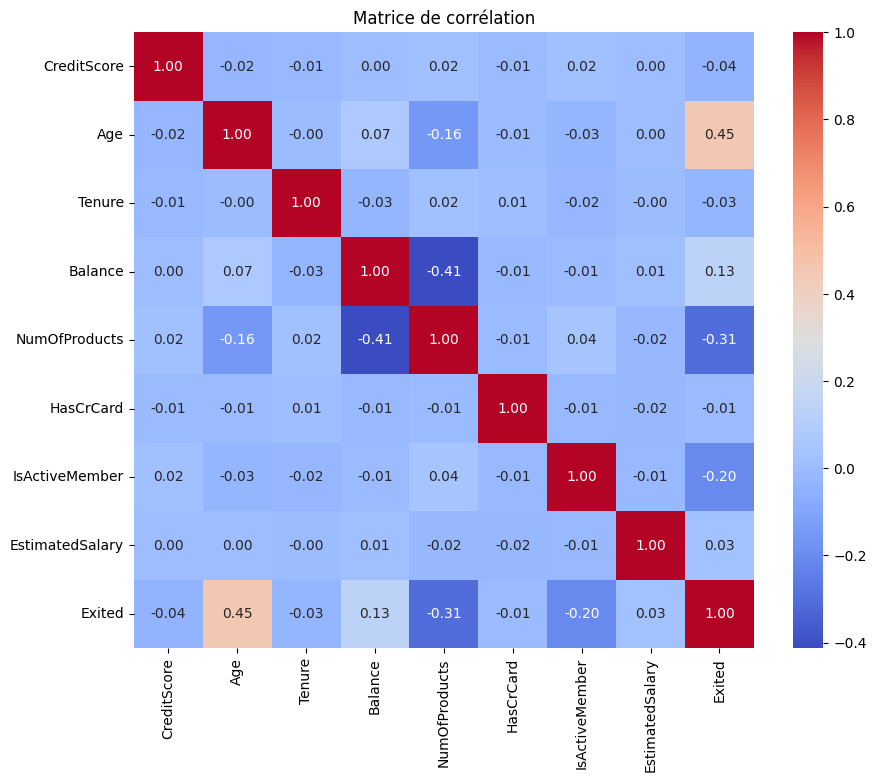

In [ ]:
# Diviser les caractéristiques et la variable cible sans modifier le dataframe df original
X = df[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography', 'Gender', 'Surname']]
y = df['Exited']

# Séparer les colonnes catégoriques et numériques
numerical_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
categorical_features = ['Geography', 'Gender']
target_encoding_feature = ['Surname']

# Utiliser le coefficient de corrélation de Pearson
correlation_matrix = df[numerical_features + ['Exited']].corr()

# Tracer une heatmap pour visualiser la matrice de corrélation
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice de corrélation')
plt.show()

## Comparaison des distributions entre 2 groupes



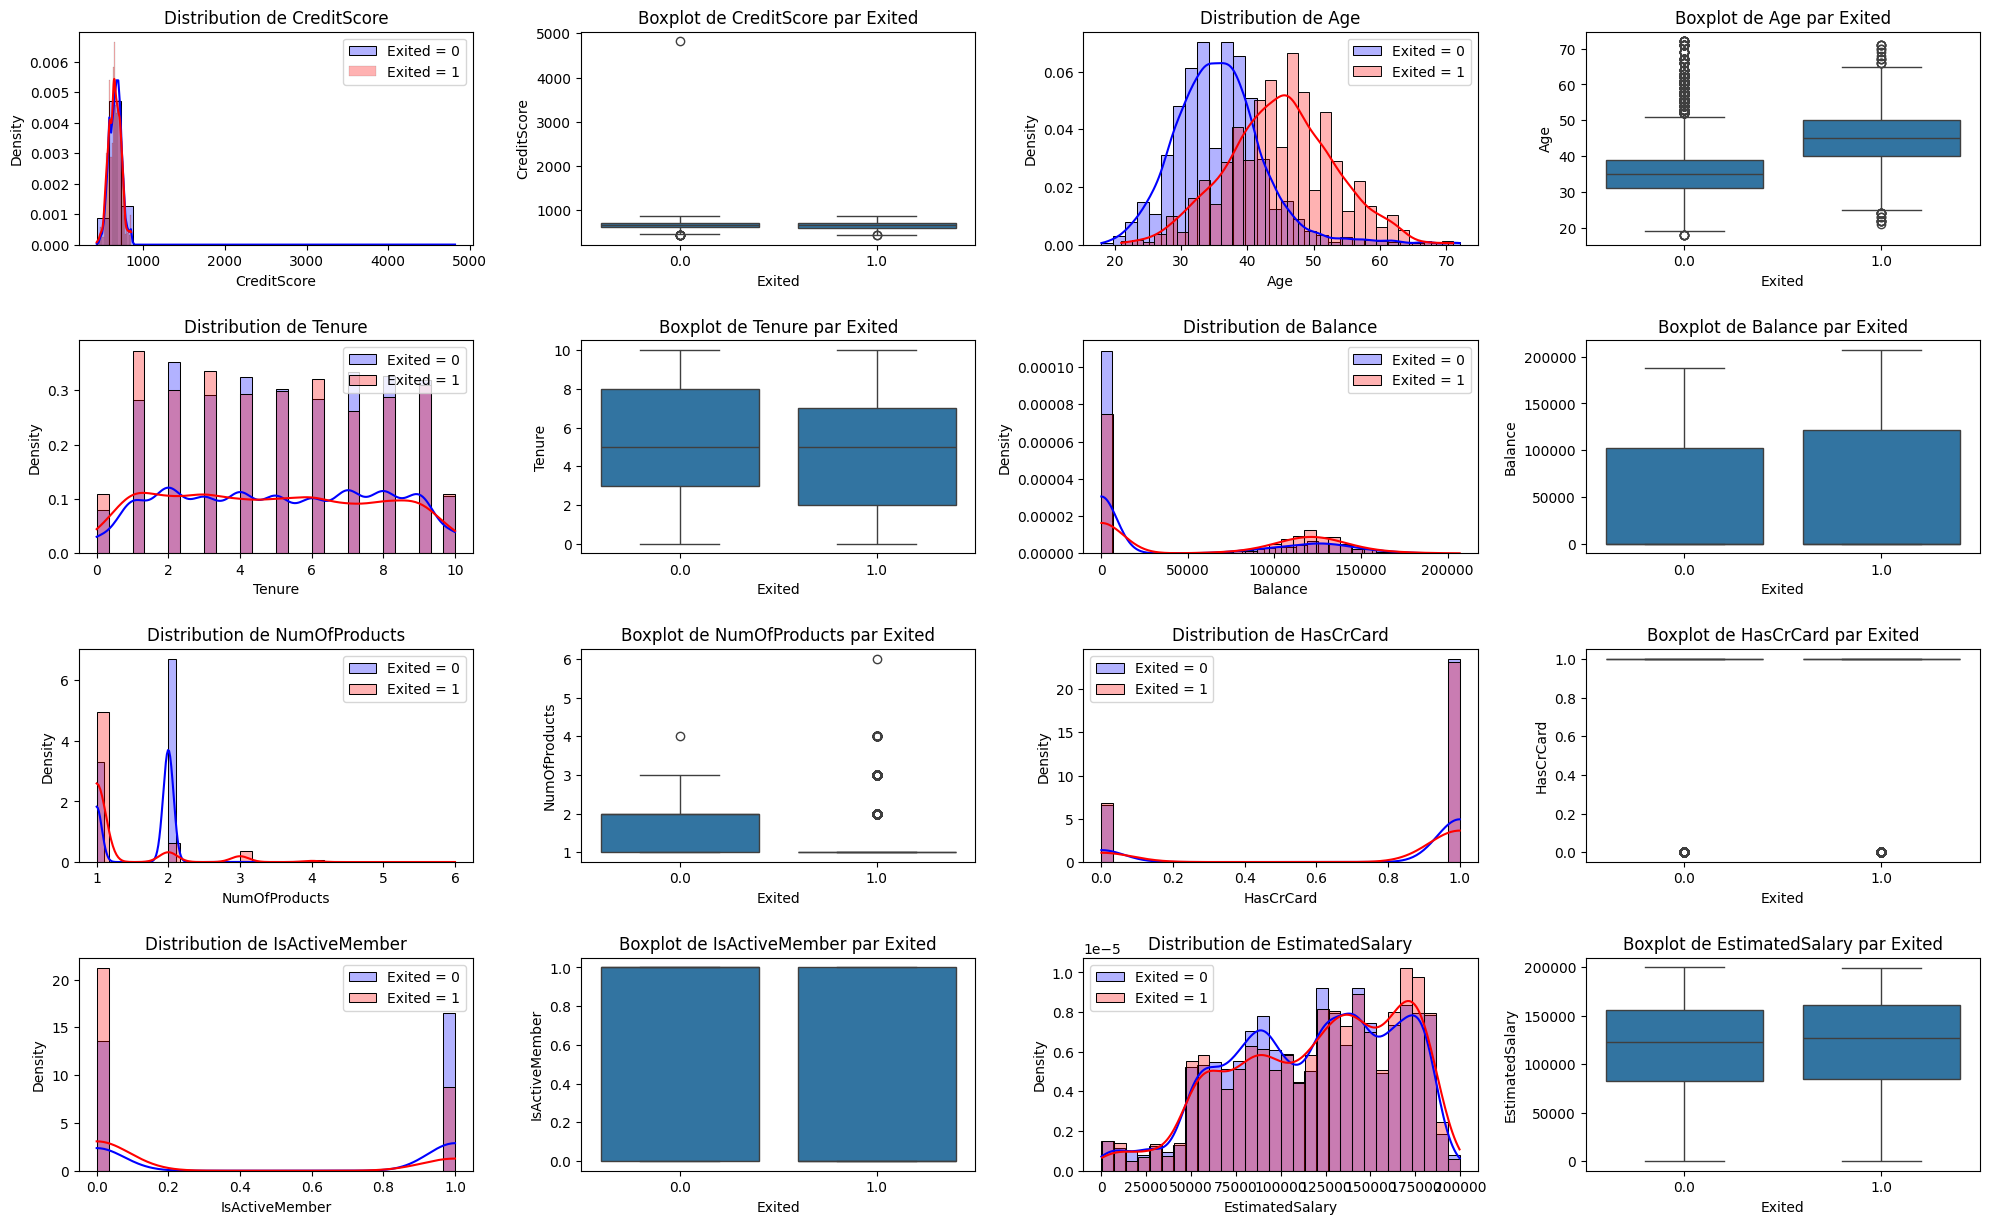

In [ ]:
# Diviser les caractéristiques et la variable cible sans modifier le dataframe df original
X = df[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography', 'Gender', 'Surname']]
y = df['Exited']

# Séparer les colonnes catégoriques et numériques
numerical_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
categorical_features = ['Geography', 'Gender']
target_encoding_feature = ['Surname']

# Diviser le dataframe en df_bad_0 (BAD = 0) et df_bad_1 (BAD = 1)
df_Exited_0 = df[df['Exited'] == 0]
df_Exited_1 = df[df['Exited'] == 1]

# Nombre de lignes et colonnes souhaitées (exemple : 4 lignes, 2 colonnes pour chaque type de graphique)
n_cols = 4
n_rows = len(numerical_features) * 2 // n_cols + 1  # Chaque variable a 2 types de graphiques (histogramme et boxplot)

# Créer une figure avec des axes imbriqués
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 15))  # Ajuster figsize si nécessaire
axes = axes.flatten()  # Transformer les axes en un tableau 1D pour un accès simplifié

# Tracer les graphiques pour chaque variable
for i, var in enumerate(numerical_features):
    # Tracer un histogramme dans la première rangée pour chaque variable
    sns.histplot(df_Exited_0[var], color='blue', label='Exited = 0', kde=True, stat="density", bins=30, alpha=0.3, ax=axes[i*2])
    sns.histplot(df_Exited_1[var], color='red', label='Exited = 1', kde=True, stat="density", bins=30, alpha=0.3, ax=axes[i*2])
    axes[i*2].set_title(f'Distribution de {var}')
    axes[i*2].legend()

    # Tracer un boxplot dans la deuxième rangée pour chaque variable
    sns.boxplot(x='Exited', y=var, data=df, ax=axes[i*2+1])
    axes[i*2+1].set_title(f'Boxplot de {var} par Exited')

# Supprimer les axes vides s'il y en a
for i in range(len(numerical_features)*2, len(axes)):
    fig.delaxes(axes[i])

# Ajuster automatiquement l'espacement entre les graphiques
plt.tight_layout()
plt.show()

## Pairplot

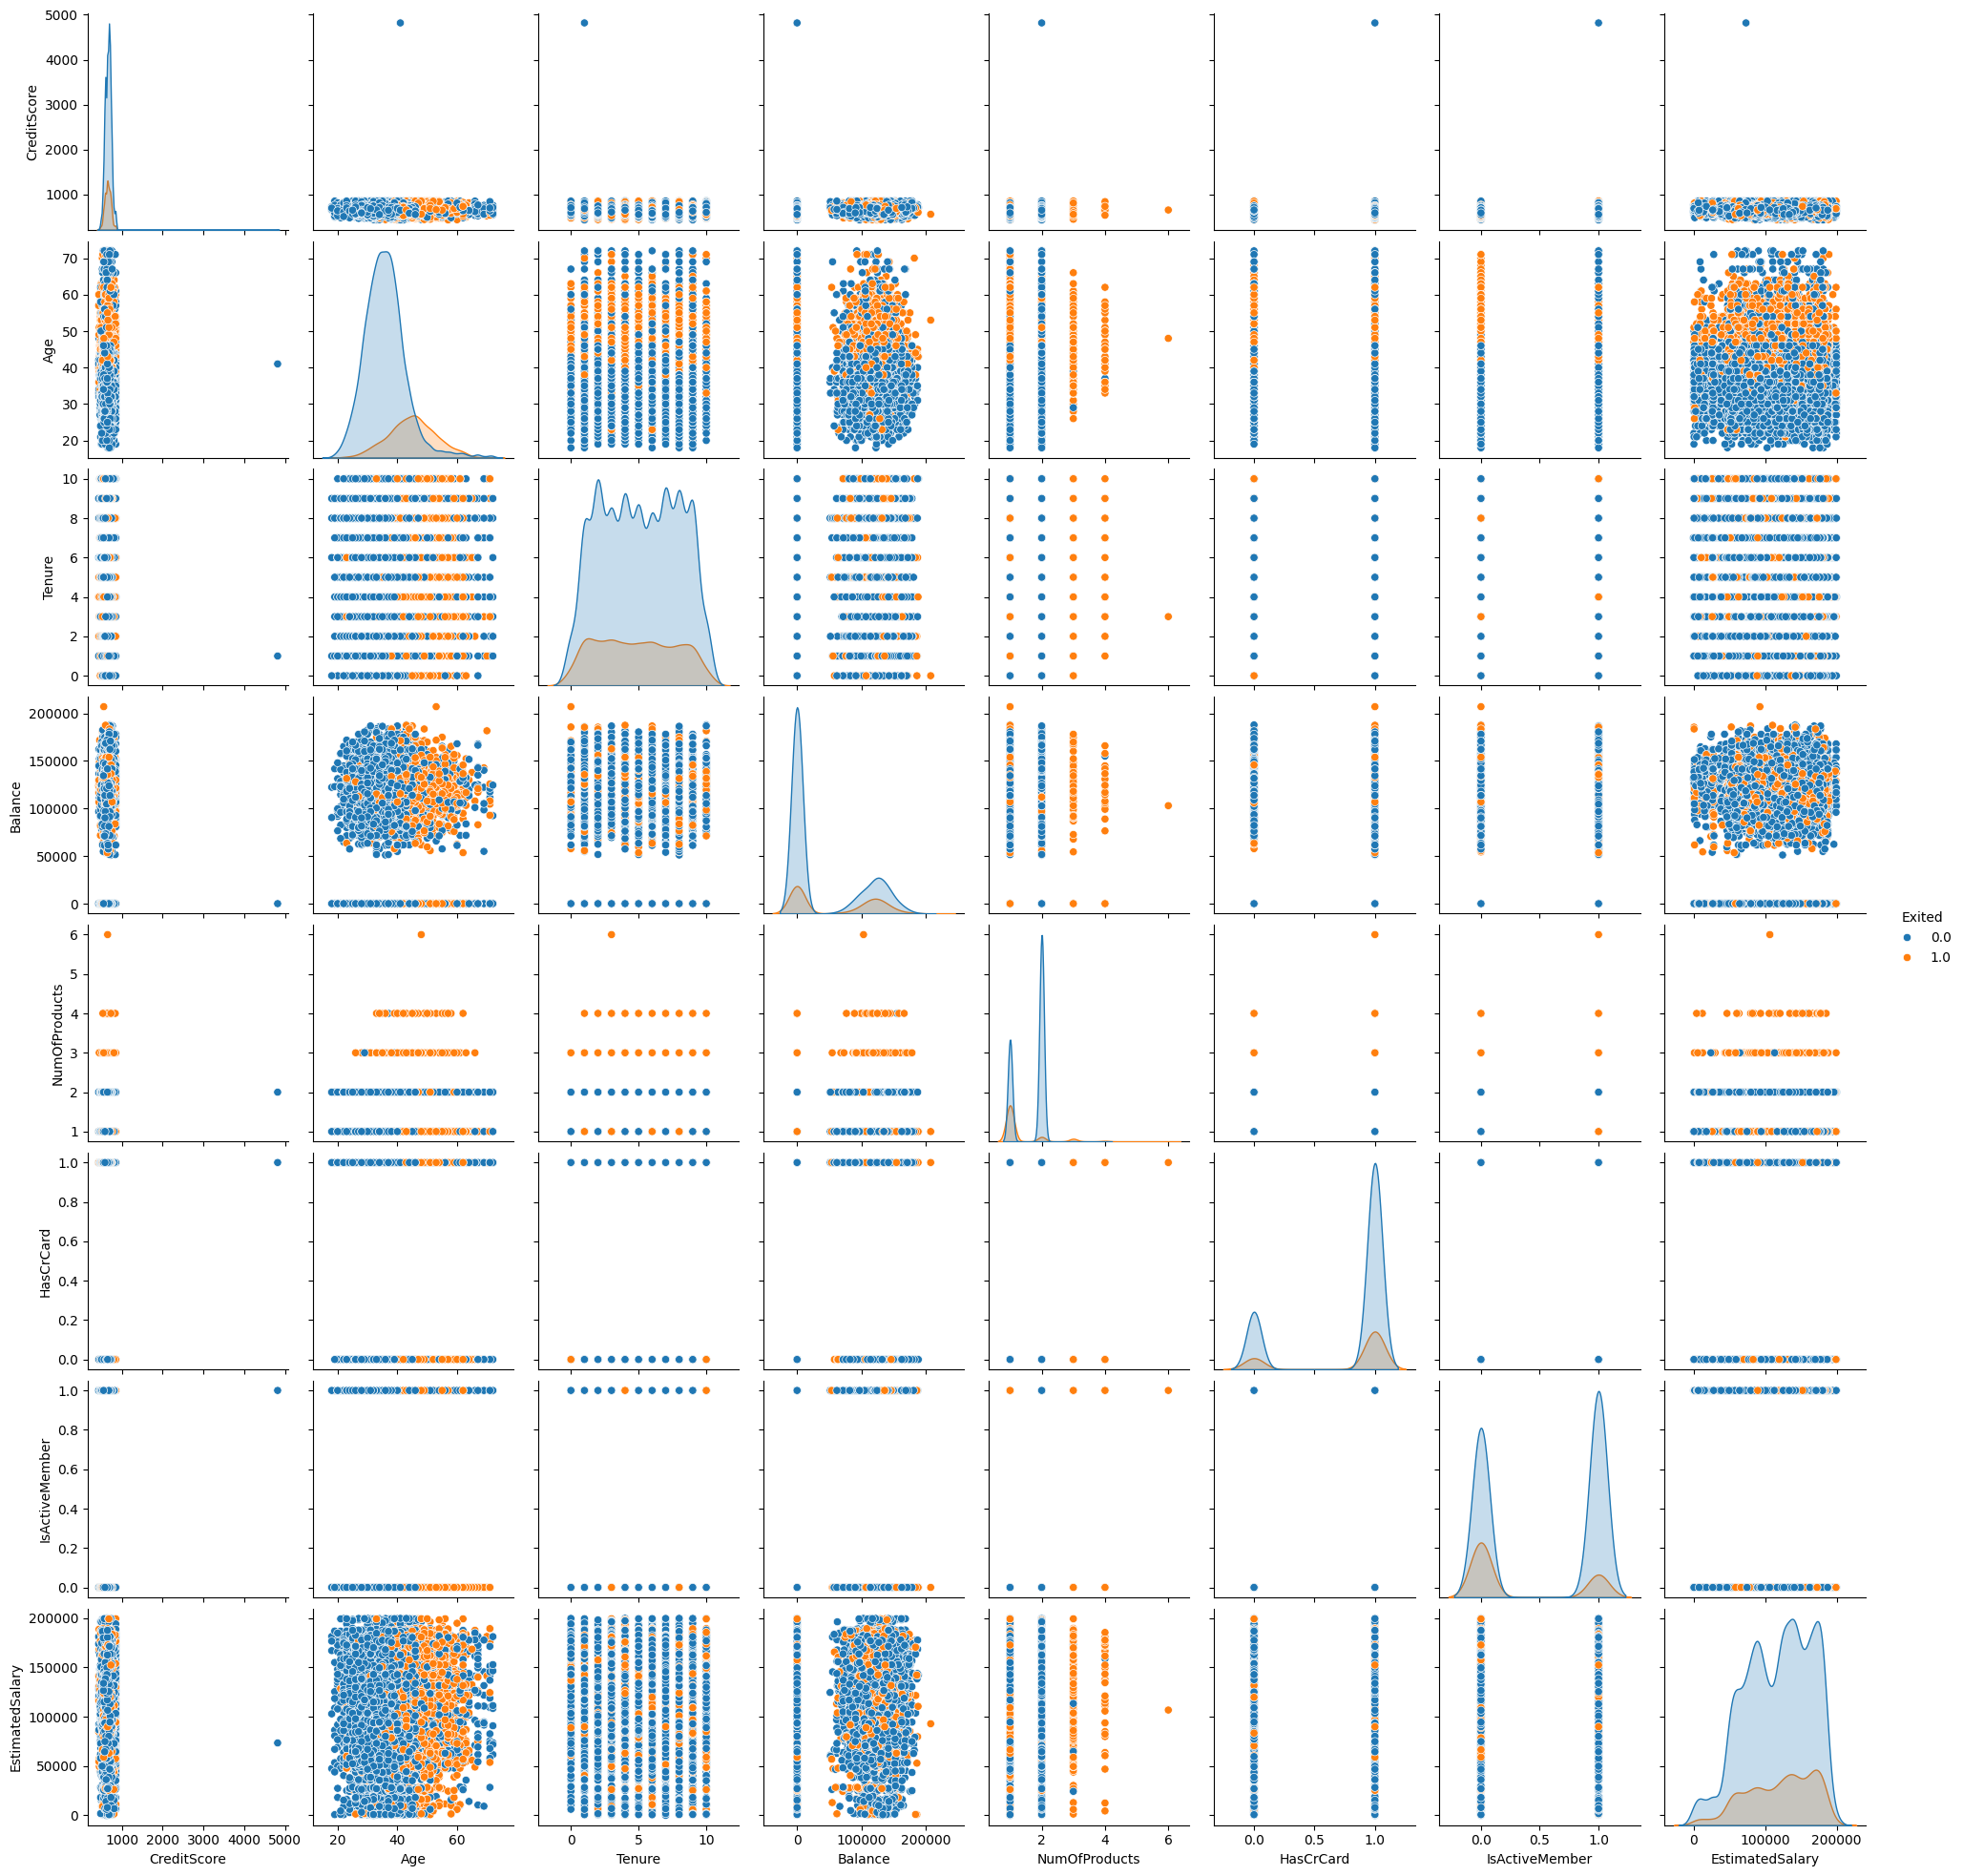

In [ ]:
# Diviser les caractéristiques et la variable cible sans modifier le dataframe df original
X = df[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography', 'Gender', 'Surname']]
y = df['Exited']

# Séparer les colonnes catégoriques et numériques
numerical_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
categorical_features = ['Geography', 'Gender']
target_encoding_feature = ['Surname']

# Traiter les valeurs manquantes en supprimant les lignes contenant des valeurs manquantes (ou vous pouvez choisir une autre méthode)
df_cleaned = df[numerical_features + ['Exited']].dropna()

# Créer un pairplot
sns.pairplot(df_cleaned, hue='Exited', diag_kind='kde')

# Afficher le graphique
plt.show()

# Etape 3 : Quels modèles ?

In [ ]:
# Diviser les caractéristiques et la variable cible sans modifier le dataframe original
X = df[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography', 'Gender', 'Surname']]
y = df['Exited']

# Séparer les colonnes catégoriques et numériques
numerical_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
categorical_features = ['Geography', 'Gender']
target_encoding_feature = ['Surname']

# Initialiser Target Encoder pour la colonne 'Surname'
target_encoder = ce.TargetEncoder(cols=target_encoding_feature)

# Pipeline pour traiter les colonnes catégoriques et numériques, incluant le Target Encoding pour 'Surname'
preprocessor = ColumnTransformer(
    transformers=[
        ('target_enc', target_encoder, target_encoding_feature),  # Appliquer le Target Encoding sur 'Surname'
        ('num', StandardScaler(), numerical_features),  # Traiter les colonnes numériques
        ('cat', OneHotEncoder(drop='first'), categorical_features)  # Traiter les colonnes catégoriques
    ])

# Définir la variable cible et les caractéristiques
y_train = df['Exited']
X_train = df.drop(columns=['Exited', 'id', 'CustomerId'])

# Utiliser une validation croisée k-fold avec LazyClassifier
k = 5  # Nombre de plis pour la validation croisée
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

# Créer une variable pour stocker les scores moyens du ROC AUC pour chaque modèle
models_auc_scores = []

# Boucler à travers chaque pli dans la validation croisée
for train_index, test_index in skf.split(X_train, y_train):
    X_train_fold, X_test_fold = X_train.iloc[train_index], X_train.iloc[test_index]
    y_train_fold, y_test_fold = y_train.iloc[train_index], y_train.iloc[test_index]

    # Prétraiter les colonnes numériques et catégoriques, incluant le Target Encoding pour 'Surname'
    X_train_fold_processed = preprocessor.fit_transform(X_train_fold, y_train_fold)
    X_test_fold_processed = preprocessor.transform(X_test_fold)

    # Initialiser LazyClassifier avec une métrique personnalisée roc_auc_score
    clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=roc_auc_score)
    models_fold, predictions = clf.fit(X_train_fold_processed, X_test_fold_processed, y_train_fold, y_test_fold)

    print(f'models_fold : {models_fold}')

    # Stocker le score ROC AUC pour chaque modèle dans ce pli
    print(f'models_fold["roc_auc_score"] : {models_fold["roc_auc_score"]}')
    models_auc_scores.append(models_fold['roc_auc_score'])

# Calculer le score moyen ROC AUC pour chaque modèle
mean_auc_scores = pd.DataFrame(models_auc_scores).mean()

# Afficher les résultats moyens des modèles avec les scores ROC AUC
print("Average ROC AUC scores across folds:")
print(mean_auc_scores.sort_values(ascending=False))

 97%|█████████▋| 30/31 [00:36<00:00,  1.70it/s]

[LightGBM] [Info] Number of positive: 2392, number of negative: 9608
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001642 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1094
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.199333 -> initscore=-1.390466
[LightGBM] [Info] Start training from score -1.390466


100%|██████████| 31/31 [00:37<00:00,  1.20s/it]


models_fold :                                Accuracy  Balanced Accuracy  ROC AUC  F1 Score  \
Model                                                                           
LGBMClassifier                     0.89               0.81     0.81      0.89   
NearestCentroid                    0.81               0.80     0.80      0.83   
QuadraticDiscriminantAnalysis      0.87               0.80     0.80      0.87   
AdaBoostClassifier                 0.89               0.80     0.80      0.89   
ExtraTreesClassifier               0.89               0.79     0.79      0.89   
SVC                                0.89               0.79     0.79      0.89   
RandomForestClassifier             0.89               0.79     0.79      0.89   
XGBClassifier                      0.88               0.79     0.79      0.88   
DecisionTreeClassifier             0.85               0.77     0.77      0.85   
BaggingClassifier                  0.88               0.77     0.77      0.87   
KNeighborsClas

 97%|█████████▋| 30/31 [00:28<00:00,  1.69it/s]

...

models_fold :                                Accuracy  Balanced Accuracy  ROC AUC  F1 Score  \
Model                                                                           
XGBClassifier                      0.89               0.79     0.79      0.89   
AdaBoostClassifier                 0.89               0.79     0.79      0.88   
LGBMClassifier                     0.89               0.79     0.79      0.88   
QuadraticDiscriminantAnalysis      0.86               0.78     0.78      0.86   
SVC                                0.89               0.78     0.78      0.88   
NearestCentroid                    0.80               0.78     0.78      0.81   
RandomForestClassifier             0.89               0.78     0.78      0.88   
ExtraTreesClassifier               0.88               0.77     0.77      0.88   
BaggingClassifier                  0.88               0.77     0.77      0.87   
KNeighborsClassifier               0.87               0.76     0.76      0.87   
DecisionTreeCl

 97%|█████████▋| 30/31 [00:27<00:00,  1.72it/s]

[LightGBM] [Info] Number of positive: 2392, number of negative: 9608
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001193 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1098
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.199333 -> initscore=-1.390466
[LightGBM] [Info] Start training from score -1.390466


100%|██████████| 31/31 [00:28<00:00,  1.10it/s]

models_fold :                                Accuracy  Balanced Accuracy  ROC AUC  F1 Score  \
Model                                                                           
LGBMClassifier                     0.89               0.82     0.82      0.89   
AdaBoostClassifier                 0.90               0.82     0.82      0.89   
XGBClassifier                      0.89               0.81     0.81      0.89   
RandomForestClassifier             0.89               0.80     0.80      0.89   
QuadraticDiscriminantAnalysis      0.86               0.80     0.80      0.86   
SVC                                0.90               0.80     0.80      0.89   
ExtraTreesClassifier               0.89               0.80     0.80      0.89   
Perceptron                         0.83               0.79     0.79      0.84   
BaggingClassifier                  0.88               0.78     0.78      0.87   
NearestCentroid                    0.79               0.78     0.78      0.81   
LinearDiscrimi

# Etape 4 : Modélisation

## XGB

### XGB - Baseline

In [ ]:
# NE PAS LANCER (>45 mins)
# Fitting 5 folds for each of 108 candidates, totalling 540 fits
# Best Parameters: {'classifier__colsample_bytree': 0.8,
#                   'classifier__learning_rate': 0.05,
#                   'classifier__max_depth': 3,
#                   'classifier__n_estimators': 200,
#                   'classifier__subsample': 1.0}
# Best ROC AUC: 0.937313804828195

# Diviser les caractéristiques et la variable cible
X = df[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
        'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography',
        'Gender']]
y = df['Exited']

# Supposons que l'ensemble de test (test) a les mêmes colonnes que l'ensemble d'entraînement
# X_test = test[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
#                'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography',
#                'Gender']]
# test_ids = test['id']  # Supposons que 'id' est une colonne identifiant dans l'ensemble de test

# Séparer les colonnes catégoriques et numériques
numerical_features = ['CreditScore', 'Age', 'Tenure', 'Balance',
                      'NumOfProducts', 'HasCrCard', 'IsActiveMember',
                      'EstimatedSalary']
categorical_features = ['Geography', 'Gender']

# Pipeline pour traiter les colonnes catégoriques et numériques
preprocessor = ColumnTransformer(
    transformers=[('num', StandardScaler(), numerical_features),
                  ('cat', OneHotEncoder(drop='first'), categorical_features)])

# Initialiser le modèle XGBClassifier
xgb_classifier = xgb.XGBClassifier(scale_pos_weight=1, random_state=42, use_label_encoder=False, eval_metric='auc')

# Créer un pipeline pour traiter les données et entraîner le modèle
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', xgb_classifier)])

# Définir une grille de paramètres pour trouver les paramètres optimaux pour XGBoost
param_grid = {
    'classifier__n_estimators': [100, 150, 200],     # nombre d'arbres
    'classifier__max_depth': [3, 5, 7],              # profondeur des arbres
    'classifier__learning_rate': [0.01, 0.05, 0.1],  # taux d'apprentissage
    'classifier__subsample': [0.8, 1.0],             # taux d'échantillonnage pour chaque arbre
    'classifier__colsample_bytree': [0.8, 1.0],      # taux d'échantillonnage par arbre basé sur les colonnes
}

# Utiliser GridSearchCV pour trouver les meilleurs paramètres
grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)

# Exécuter GridSearchCV pour trouver les meilleurs paramètres
grid_search.fit(X, y)

# Afficher les résultats de GridSearchCV
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best ROC AUC: {grid_search.best_score_}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 200, 'classifier__subsample': 1.0}
Best ROC AUC: 0.937313804828195


In [ ]:
# En utilisant les best params en haut, on crée 2 versions : avec ou sans target_encoding_feature

# Avec target_encoding_feature
# Diviser les caractéristiques et la variable cible sans modifier le dataframe original
X = df[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography', 'Gender', 'Surname']]
y = df['Exited']

# Supposons que l'ensemble de test (test) a les mêmes colonnes que l'ensemble d'entraînement
X_test = test[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography', 'Gender', 'Surname']]
test_ids = test['id']

# Séparer les colonnes catégoriques et numériques
numerical_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
categorical_features = ['Geography', 'Gender']
target_encoding_feature = ['Surname']

# Initialiser Target Encoder pour la colonne 'Surname'
target_encoder = ce.TargetEncoder(cols=target_encoding_feature)

# Pipeline pour traiter les colonnes catégoriques et numériques
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features),  # drop='first' pour éviter la multicolinéarité
        ('target_enc', target_encoder, target_encoding_feature)       # Appliquer le Target Encoding sur 'Surname'
    ])

# Initialiser le modèle XGBClassifier avec les paramètres optimaux sélectionnés
xgb_classifier = xgb.XGBClassifier(
    n_estimators=200,           # Nombre d'arbres = 200
    max_depth=3,                # Profondeur maximale des arbres = 3
    learning_rate=0.05,         # Taux d'apprentissage = 0.05
    subsample=1.0,              # Taux d'échantillonnage pour chaque arbre = 1.0
    colsample_bytree=0.8,       # Taux d'échantillonnage basé sur les colonnes = 0.8
    min_child_weight=1,         # Nombre minimum d'échantillons par feuille = 1
    gamma=0,                    # Valeur gamma = 0 pour ne pas appliquer de condition supplémentaire pour la division des feuilles
    scale_pos_weight=1,         # Équilibrage des classes
    random_state=42,
    use_label_encoder=False,    # Désactiver l'avertissement sur l'encodeur de labels (inutile pour la nouvelle version de XGB)
    eval_metric='auc'           # Métrique utilisée pour l'évaluation
)


# Créer un pipeline pour traiter les données et entraîner le modèle
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', xgb_classifier)])

# Effectuer une validation croisée k-fold avec k=5 et utiliser roc_auc comme mesure
scores = cross_val_score(pipeline, X, y, cv=5, scoring='roc_auc')
print("Scores ROC AUC de la validation croisée pour chaque pli :", scores)
print("Moyenne des scores ROC AUC de la validation croisée :", scores.mean())

# Réentraîner le modèle sur l'ensemble complet des données d'entraînement
pipeline.fit(X, y)

# Prédire les probabilités sur l'ensemble de test
y_test_proba = pipeline.predict_proba(X_test)[:, 1]  # Probabilité pour la classe Exited = 1

# Créer un DataFrame de résultats avec les étiquettes prédites
result_df = pd.DataFrame({
    'id': test_ids,
    'Exited': y_test_proba
})

# Exporter les résultats dans un fichier CSV
result_df.to_csv('test_predictions_xgb_tg_v4.csv', index=False)
print("Les prédictions ont été enregistrées dans 'test_predictions_xgb_tg_v4.csv'.")

# # Télécharger le fichier CSV sur l'ordinateur
# files.download('test_predictions_xgb_tg_v4.csv')

Scores ROC AUC de la validation croisée pour chaque pli : [0.9308582  0.93894163 0.94038517 0.93390889 0.937551  ]
Moyenne des scores ROC AUC de la validation croisée : 0.9363289789166777
Les prédictions ont été enregistrées dans 'test_predictions_xgb_tg_v4.csv'.


In [ ]:
# En utilisant les best params en haut, on crée 2 versions : avec ou sans target_encoding_feature

# Sans target_encoding_feature
# Diviser les caractéristiques et la variable cible sans modifier le dataframe original
X = df[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography', 'Gender']]
y = df['Exited']

# Supposons que l'ensemble de test (test) a les mêmes colonnes que l'ensemble d'entraînement
X_test = test[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography', 'Gender']]
test_ids = test['id']

# Séparer les colonnes catégoriques et numériques
numerical_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
categorical_features = ['Geography', 'Gender']

# Pipeline pour traiter les colonnes catégoriques et numériques
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features),  # drop='first' pour éviter la multicolinéarité
    ])

# Initialiser le modèle XGBClassifier avec les paramètres optimaux sélectionnés
xgb_classifier = xgb.XGBClassifier(
    n_estimators=200,           # Nombre d'arbres = 200
    max_depth=3,                # Profondeur maximale des arbres = 3
    learning_rate=0.05,         # Taux d'apprentissage = 0.05
    subsample=1.0,              # Taux d'échantillonnage pour chaque arbre = 1.0
    colsample_bytree=0.8,       # Taux d'échantillonnage basé sur les colonnes = 0.8
    min_child_weight=1,         # Nombre minimum d'échantillons par feuille = 1
    gamma=0,                    # Valeur gamma = 0 pour ne pas appliquer de condition supplémentaire pour la division des feuilles
    scale_pos_weight=1,         # Équilibrage des classes
    random_state=42,
    use_label_encoder=False,    # Désactiver l'avertissement sur l'encodeur de labels (inutile pour la nouvelle version de XGB)
    eval_metric='auc'           # Métrique utilisée pour l'évaluation
)


# Créer un pipeline pour traiter les données et entraîner le modèle
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', xgb_classifier)])

# Effectuer une validation croisée k-fold avec k=5 et utiliser roc_auc comme mesure
scores = cross_val_score(pipeline, X, y, cv=5, scoring='roc_auc')
print("Scores ROC AUC de la validation croisée pour chaque pli :", scores)
print("Moyenne des scores ROC AUC de la validation croisée :", scores.mean())

# Réentraîner le modèle sur l'ensemble complet des données d'entraînement
pipeline.fit(X, y)

# Prédire les probabilités sur l'ensemble de test
y_test_proba = pipeline.predict_proba(X_test)[:, 1]  # Probabilité pour la classe Exited = 1

# Créer un DataFrame de résultats avec les étiquettes prédites
result_df = pd.DataFrame({
    'id': test_ids,
    'Exited': y_test_proba
})

# Exporter les résultats dans un fichier CSV
result_df.to_csv('test_predictions_xgb_stg_v4.csv', index=False)
print("Les prédictions ont été enregistrées dans 'test_predictions_xgb_stg_v4.csv'.")

# Télécharger le fichier CSV sur l'ordinateur
files.download('test_predictions_xgb_stg_v4.csv')

Scores ROC AUC de la validation croisée pour chaque pli : [0.93202153 0.94179982 0.94195716 0.93462144 0.93573847]
Moyenne des scores ROC AUC de la validation croisée : 0.9372276865154179
Les prédictions ont été enregistrées dans 'test_predictions_xgb_stg_v4.csv'.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### XGB - Feature Engineering

In [ ]:
# ----------------------------------------
# FEATURE ENGINEERING
# ----------------------------------------

# 1. Groupement par âge
# Création de groupes d'âge
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 30, 50, 100], labels=['Young', 'Middle', 'Senior'])

# Création d'une caractéristique non linéaire à partir de l'âge
df['AgeSquared'] = df['Age'] ** 2
df['LogAge'] = np.log(df['Age'] + 1)  # Transformation log (éviter log(0))

# Interaction entre Age et Balance
df['Age_Balance_Interaction'] = df['Age'] * df['Balance']

# ----------------------------------------

# 2. Groupement par Balance (solde du compte)
# Caractéristique binaire : les clients sans solde
df['HasNoBalance'] = (df['Balance'] == 0).astype(int)

# Interaction entre Balance et IsActiveMember
df['Active_Balance_Interaction'] = df['Balance'] * df['IsActiveMember']

# Transformation log pour capturer des relations non linéaires
df['LogBalance'] = np.log(df['Balance'] + 1)

# ----------------------------------------

# 3. Groupement par NumOfProducts (Nombre de produits)
# Création de groupes basés sur le nombre de produits
df['ProductGroup'] = df['NumOfProducts'].apply(lambda x: 'Single' if x == 1 else ('Few' if x == 2 else 'Multiple'))

# Caractéristique binaire : les clients avec un seul produit
df['SingleProduct'] = (df['NumOfProducts'] == 1).astype(int)

# Interaction entre NumOfProducts et Balance
df['Product_Balance_Interaction'] = df['NumOfProducts'] * df['Balance']

# Interaction entre NumOfProducts et IsActiveMember
df['Product_Active_Interaction'] = df['NumOfProducts'] * df['IsActiveMember']

# ----------------------------------------

# 4. Tâches avec IsActiveMember (Statut actif)
# Interaction entre Age et IsActiveMember
df['Age_Active_Interaction'] = df['Age'] * df['IsActiveMember']

# Interaction entre IsActiveMember et NumOfProducts
df['Active_Product_Interaction'] = df['IsActiveMember'] * df['NumOfProducts']

# ----------------------------------------

# 5. Création de caractéristiques combinées
# Indice de force financière
df['FinancialStrength'] = df['Balance'] + df['NumOfProducts'] * 100 + df['CreditScore']

# Groupe à haut risque : âge élevé, inactif et solde élevé
df['HighRiskGroup'] = ((df['Age'] > 40) & (df['IsActiveMember'] == 0) & (df['Balance'] > 50000)).astype(int)

# Interaction entre 'Balance' et 'EstimatedSalary'
df['BalanceToSalaryRatio'] = df['Balance'] / (df['EstimatedSalary'] + 1e-5)

# Interaction entre 'Tenure' et 'NumOfProducts'
df['AverageTenurePerProduct'] = df['Tenure'] / (df['NumOfProducts'] + 1e-5)

# ----------------------------------------
# Classification des colonnes en catégoriques et numériques
# ----------------------------------------

# Liste des nouvelles colonnes numériques et catégoriques
new_numerical_features = [
    'AgeSquared', 'LogAge', 'Age_Balance_Interaction', 'LogBalance',
    'Active_Balance_Interaction', 'Product_Balance_Interaction',
    'Product_Active_Interaction', 'Age_Active_Interaction', 'FinancialStrength', 'HighRiskGroup',
    'BalanceToSalaryRatio', 'AverageTenurePerProduct'
]

new_categorical_features = [
    'AgeGroup', 'ProductGroup'
]

# Colonnes catégoriques et numériques après ajout des nouvelles colonnes
print("numerical_features :", numerical_features)
print("categorical_features :", categorical_features)
print("target_encoding_feature :", target_encoding_feature)
print("new_numerical_features :", new_numerical_features)
print("new_categorical_features :", new_categorical_features)

##################################################################################################

# Diviser les caractéristiques et la variable cible sans modifier le dataframe original
X = df[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography', 'Gender', 'Surname']]
y = df['Exited']

# Séparer les colonnes catégoriques et numériques
numerical_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
categorical_features = ['Geography', 'Gender']
target_encoding_feature = ['Surname']

# Initialisation des paramètres du modèle XGBoost avec scale_pos_weight
xgb_params = {
    'n_estimators': 200,           # Nombre total d'arbres dans le modèle
    'max_depth': 3,                # Profondeur maximale de chaque arbre
    'learning_rate': 0.05,         # Taux d'apprentissage
    'subsample': 1.0,              # Proportion d'échantillons utilisés pour chaque arbre
    'colsample_bytree': 0.8,       # Proportion de colonnes utilisées pour chaque arbre
    'min_child_weight': 1,         # Nombre minimum de données dans chaque feuille
    'gamma': 0,                    # Valeur gamma (aucune contrainte additionnelle)
    'scale_pos_weight': 1,         # Poids de balance pour les classes déséquilibrées
    'random_state': 42,            # Pour rendre les résultats reproductibles
    'use_label_encoder': False,    # Désactiver les avertissements sur l'encodage des labels
    'eval_metric': 'auc'           # Utiliser AUC pour évaluer le modèle
}

# Calculer scale_pos_weight en fonction du déséquilibre des classes
class_counts = df['Exited'].value_counts()
xgb_params['scale_pos_weight'] = class_counts[0] / class_counts[1]

# Fonction pour calculer AUC baseline
def calculate_baseline_auc(X, y):
    # Préparation du préprocesseur pour les colonnes numériques, catégoriques, et target_encoding
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numerical_features),  # Colonnes numériques (standardisation)
            ('cat', OneHotEncoder(drop='first'), categorical_features),  # Colonnes catégoriques (one-hot encoding)
            ('target_enc', ce.TargetEncoder(cols=target_encoding_feature), target_encoding_feature)  # Target encoding
        ]
    )

    # Pipeline complet
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', XGBClassifier(**xgb_params))
    ])

    # Initialisation du StratifiedKFold pour cross-validation
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    train_auc_scores = []  # Scores AUC pour les folds de train
    val_auc_scores = []  # Scores AUC pour les folds de validation

    # Cross-validation
    for train_idx, val_idx in skf.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        pipeline.fit(X_train, y_train)

        y_train_pred = pipeline.predict_proba(X_train)[:, 1]
        y_val_pred = pipeline.predict_proba(X_val)[:, 1]

        train_auc = roc_auc_score(y_train, y_train_pred)
        val_auc = roc_auc_score(y_val, y_val_pred)

        train_auc_scores.append(train_auc)
        val_auc_scores.append(val_auc)

    baseline_train_auc = np.mean(train_auc_scores)
    baseline_val_auc = np.mean(val_auc_scores)

    print(f"Baseline AUC Train: {baseline_train_auc:.4f} ± {np.std(train_auc_scores):.4f}")
    print(f"Baseline AUC Validation: {baseline_val_auc:.4f} ± {np.std(val_auc_scores):.4f}")
    print("=" * 50)

    return baseline_train_auc, baseline_val_auc

# Fonction pour évaluer les nouvelles features (numerical et categorical)
def evaluate_feature(feature, X, y, baseline_train_auc, baseline_val_auc, feature_type):
    print(f"Évaluation de la feature: {feature}")

    if feature_type == 'numerical':
        added_numerical_features = numerical_features + [feature]
        preprocessor = ColumnTransformer(
            transformers=[
                ('num', StandardScaler(), added_numerical_features),
                ('cat', OneHotEncoder(drop='first'), categorical_features),
                ('target_enc', ce.TargetEncoder(cols=target_encoding_feature), target_encoding_feature)
            ]
        )
    elif feature_type == 'categorical':
        added_categorical_features = categorical_features + [feature]
        preprocessor = ColumnTransformer(
            transformers=[
                ('num', StandardScaler(), numerical_features),
                ('cat', OneHotEncoder(drop='first'), added_categorical_features),
                ('target_enc', ce.TargetEncoder(cols=target_encoding_feature), target_encoding_feature)
            ]
        )

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', XGBClassifier(**xgb_params))
    ])

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    train_auc_scores = []
    val_auc_scores = []

    for train_idx, val_idx in skf.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        pipeline.fit(X_train, y_train)

        y_train_pred = pipeline.predict_proba(X_train)[:, 1]
        y_val_pred = pipeline.predict_proba(X_val)[:, 1]

        train_auc = roc_auc_score(y_train, y_train_pred)
        val_auc = roc_auc_score(y_val, y_val_pred)

        train_auc_scores.append(train_auc)
        val_auc_scores.append(val_auc)

    train_auc_mean = np.mean(train_auc_scores)
    val_auc_mean = np.mean(val_auc_scores)

    print(f"AUC Train (Baseline: {baseline_train_auc:.4f}): {train_auc_mean:.4f} ± {np.std(train_auc_scores):.4f}")
    print(f"AUC Validation (Baseline: {baseline_val_auc:.4f}): {val_auc_mean:.4f} ± {np.std(val_auc_scores):.4f}")
    print("-" * 50)

# Calculer le baseline avant d'ajouter les features
baseline_train_auc, baseline_val_auc = calculate_baseline_auc(X, y)

# Sauvegarder une copie de X avant modification
original_X = X.copy()

# Évaluer chaque feature numérique individuellement
for feature in new_numerical_features:
    X[feature] = df[feature]
    evaluate_feature(feature, X, y, baseline_train_auc, baseline_val_auc, feature_type='numerical')
    X = original_X.copy()

# Évaluer chaque feature catégorique individuellement
for feature in new_categorical_features:
    X[feature] = df[feature]
    evaluate_feature(feature, X, y, baseline_train_auc, baseline_val_auc, feature_type='categorical')
    X = original_X.copy()

numerical_features : ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
categorical_features : ['Geography', 'Gender']
target_encoding_feature : ['Surname']
new_numerical_features : ['AgeSquared', 'LogAge', 'Age_Balance_Interaction', 'LogBalance', 'Active_Balance_Interaction', 'Product_Balance_Interaction', 'Product_Active_Interaction', 'Age_Active_Interaction', 'FinancialStrength', 'HighRiskGroup', 'BalanceToSalaryRatio', 'AverageTenurePerProduct']
new_categorical_features : ['AgeGroup', 'ProductGroup']
Baseline AUC Train: 0.9532 ± 0.0006
Baseline AUC Validation: 0.9357 ± 0.0028
Évaluation de la feature: AgeSquared
AUC Train (Baseline: 0.9532): 0.9535 ± 0.0006
AUC Validation (Baseline: 0.9357): 0.9358 ± 0.0030
--------------------------------------------------
Évaluation de la feature: LogAge
AUC Train (Baseline: 0.9532): 0.9535 ± 0.0006
AUC Validation (Baseline: 0.9357): 0.9358 ± 0.0030
--------------------------------------

In [ ]:
# A partir le résulat en haut, je crée une version 4.1 : Utiliser le même traitement que la version 4 + feature engineering (MAIS LE RÉSULTAT RESTE IDENTIQUE SUR KAGGLE)

# Créer des nouvelles caractéristiques à partir des données
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 30, 50, 100], labels=['Young', 'Middle-aged', 'Senior'])
df['HasNoBalance'] = (df['Balance'] == 0).astype(int)
df['BalanceToSalaryRatio'] = df['Balance'] / (df['EstimatedSalary'] + 1e-5)
df['AverageTenurePerProduct'] = df['Tenure'] / (df['NumOfProducts'] + 1e-5)

test['AgeGroup'] = pd.cut(test['Age'], bins=[0, 30, 50, 100], labels=['Young', 'Middle-aged', 'Senior'])
test['HasNoBalance'] = (test['Balance'] == 0).astype(int)
test['BalanceToSalaryRatio'] = test['Balance'] / (test['EstimatedSalary'] + 1e-5)
test['AverageTenurePerProduct'] = test['Tenure'] / (test['NumOfProducts'] + 1e-5)

# Mettre à jour la liste des caractéristiques
X = df[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
        'Geography', 'Gender', 'Surname', 'BalanceToSalaryRatio', 'AgeGroup', 'AverageTenurePerProduct', 'HasNoBalance']]
y = df['Exited']
X_test = test[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
               'Geography', 'Gender', 'Surname', 'BalanceToSalaryRatio', 'AgeGroup','AverageTenurePerProduct', 'HasNoBalance']]
test_ids = test['id']

# Séparer les colonnes catégoriques et numériques
numerical_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
                      'EstimatedSalary', 'BalanceToSalaryRatio', 'AverageTenurePerProduct']
categorical_features = ['Geography', 'Gender', 'AgeGroup', 'HasNoBalance']
target_encoding_feature = ['Surname']

# Initialiser Target Encoder pour la colonne 'Surname'
target_encoder = ce.TargetEncoder(cols=target_encoding_feature)

# Pipeline pour traiter les colonnes catégoriques et numériques
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features),  # drop='first' pour éviter la multicolinéarité
        ('target_enc', target_encoder, target_encoding_feature)       # Appliquer le Target Encoding sur 'Surname'
    ])

# Ajuster le paramètre scale_pos_weight en fonction de la distribution de la variable cible
scale_pos_weight = y.value_counts()[0] / y.value_counts()[1]

# Initialiser le modèle XGBClassifier avec les paramètres optimaux sélectionnés
xgb_classifier = xgb.XGBClassifier(
    n_estimators=200,           # Nombre d'arbres = 200
    max_depth=3,                # Profondeur maximale des arbres = 3
    learning_rate=0.05,         # Taux d'apprentissage = 0.05
    subsample=1.0,              # Taux d'échantillonnage pour chaque arbre = 1.0
    colsample_bytree=0.8,       # Taux d'échantillonnage basé sur les colonnes = 0.8
    min_child_weight=1,         # Nombre minimum d'échantillons par feuille = 1
    gamma=0,                    # Valeur gamma = 0 pour ne pas appliquer de condition supplémentaire pour la division des feuilles
    scale_pos_weight=scale_pos_weight,         # Équilibrage des classes
    random_state=42,
    use_label_encoder=False,    # Désactiver l'avertissement sur l'encodeur de labels (inutile pour la nouvelle version de XGB)
    eval_metric='auc'           # Métrique utilisée pour l'évaluation
)

# Créer un pipeline pour traiter les données et entraîner le modèle
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', xgb_classifier)])

# Initialiser StratifiedKFold avec k=5
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Effectuer une validation croisée Stratified K-Fold avec roc_auc comme mesure
scores = cross_val_score(pipeline, X, y, cv=skf, scoring='roc_auc')
print("Scores ROC AUC pour chaque pli de la validation croisée Stratified K-Fold :", scores)
print("Moyenne des scores ROC AUC Stratified K-Fold :", scores.mean())

# Réentraîner le modèle sur l'ensemble complet des données d'entraînement
pipeline.fit(X, y)

# Prédire les probabilités sur l'ensemble de test
y_test_proba = pipeline.predict_proba(X_test)[:, 1]  # Probabilité pour la classe Exited = 1

# Créer un DataFrame de résultats avec les étiquettes prédites
result_df = pd.DataFrame({
    'id': test_ids,
    'Exited': y_test_proba
})

# Exporter les résultats dans un fichier CSV
result_df.to_csv('test_predictions_xgb_tg_fe_v4_1.csv', index=False)
print("Les prédictions ont été enregistrées dans 'test_predictions_xgb_tg_fe_v4_1.csv'.")

# Télécharger le fichier CSV sur l'ordinateur
# files.download('test_predictions_xgb_tg_fe_v4_1.csv')

Scores ROC AUC pour chaque pli de la validation croisée Stratified K-Fold : [0.93839651 0.93917659 0.9343823  0.93238076 0.93489435]
Moyenne des scores ROC AUC Stratified K-Fold : 0.9358461037207009
Les prédictions ont été enregistrées dans 'test_predictions_xgb_tg_fe_v4_1.csv'.


### XGB - Tuning

Fold 1
Train ROC AUC: 0.9523, Validation ROC AUC: 0.9389
Fold 2
Train ROC AUC: 0.9523, Validation ROC AUC: 0.9404
Fold 3
Train ROC AUC: 0.9532, Validation ROC AUC: 0.9347
Fold 4
Train ROC AUC: 0.9540, Validation ROC AUC: 0.9328
Fold 5
Train ROC AUC: 0.9538, Validation ROC AUC: 0.9356


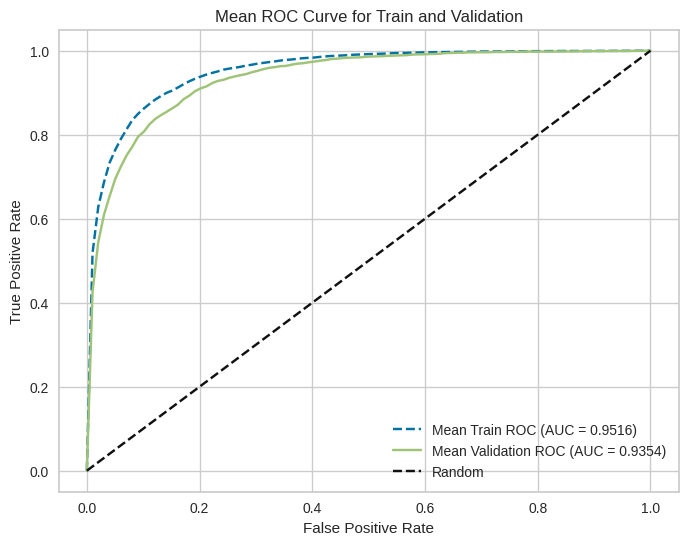

Fold 1
Fold 1 traité.
Fold 2
Fold 2 traité.
Fold 3
Fold 3 traité.
Fold 4
Fold 4 traité.
Fold 5
Fold 5 traité.


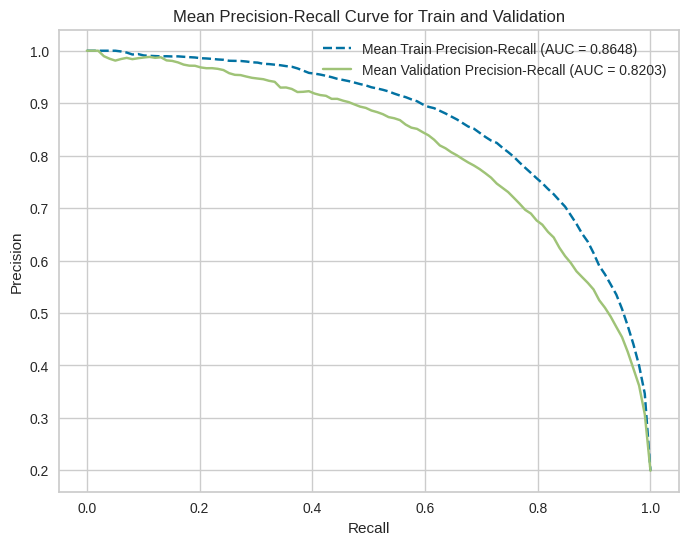

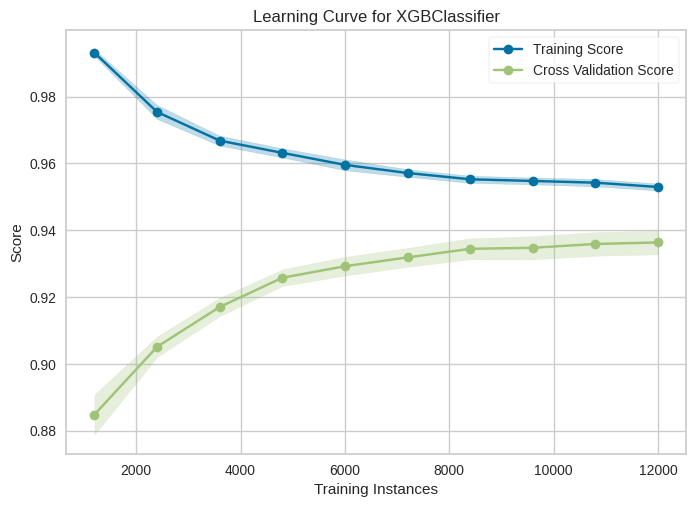

[0.00582898 0.16959286 0.00861317 0.02440205 0.16707729 0.00465932
 0.06191211 0.00537526 0.02221957 0.01093409 0.07347254 0.00288578
 0.04688757 0.18759531 0.1045844  0.07470142 0.02925827]


<Figure size 1000x600 with 0 Axes>

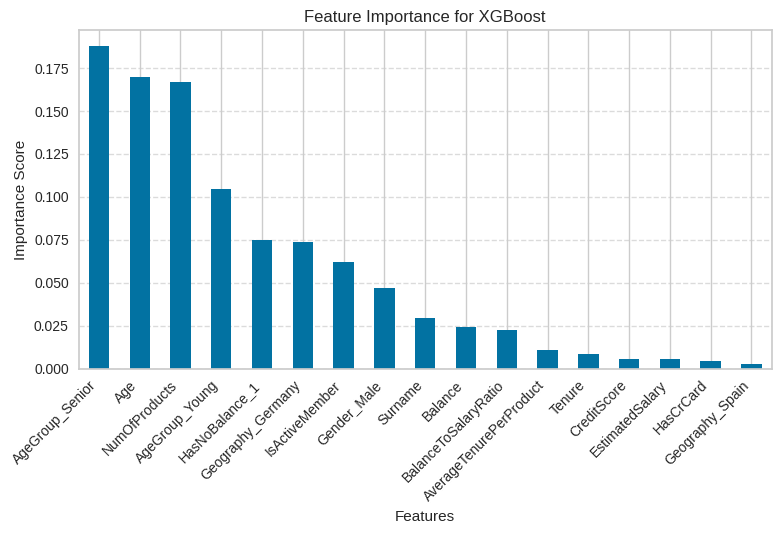

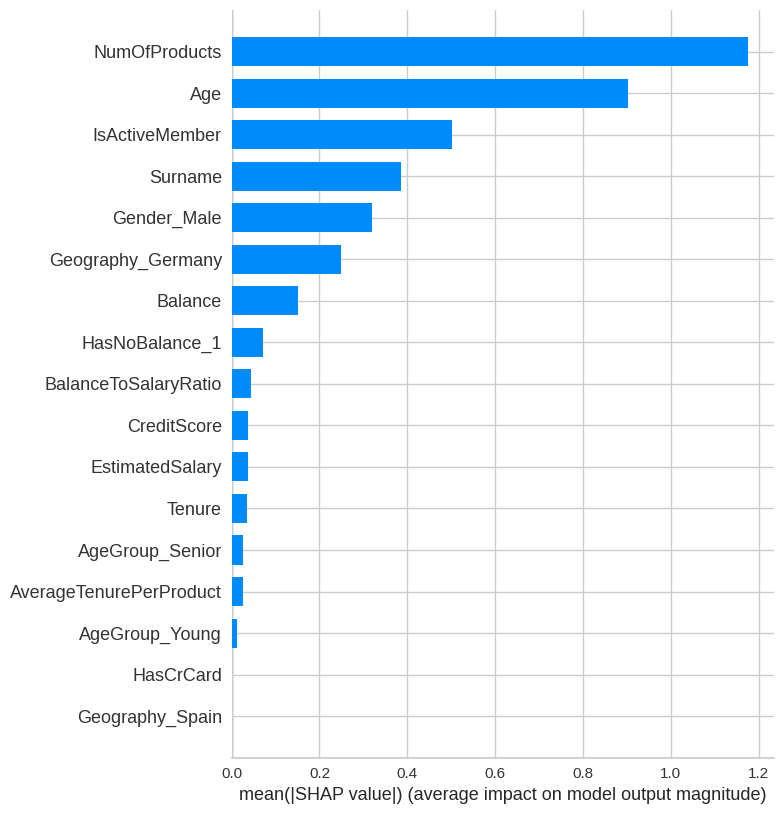

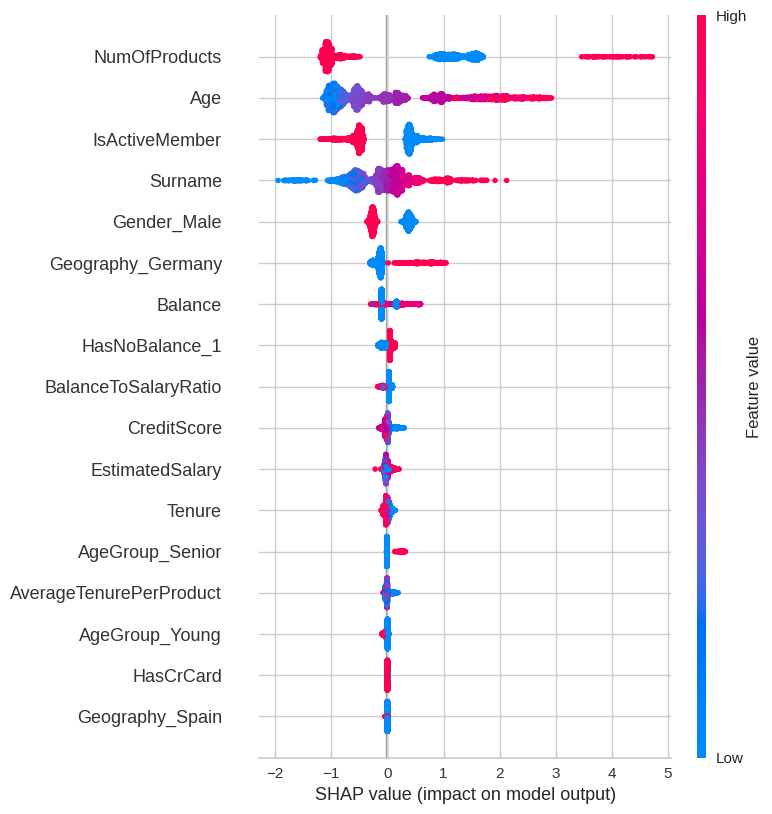

 99%|===================| 2978/3000 [00:12<00:00]       

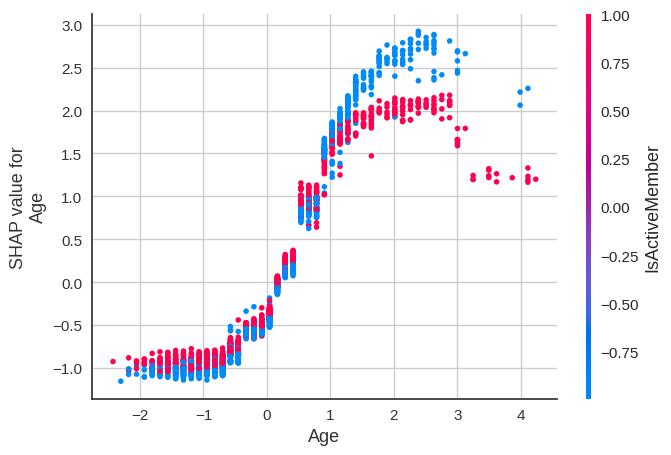

In [ ]:
# Ceci est la mêm e version xgb_tg_fe_v4_1 en haut

# Créer des nouvelles caractéristiques à partir des données
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 30, 50, 100], labels=['Young', 'Middle-aged', 'Senior'])
df['HasNoBalance'] = (df['Balance'] == 0).astype(int)
df['BalanceToSalaryRatio'] = df['Balance'] / (df['EstimatedSalary'] + 1e-5)
df['AverageTenurePerProduct'] = df['Tenure'] / (df['NumOfProducts'] + 1e-5)

test['AgeGroup'] = pd.cut(test['Age'], bins=[0, 30, 50, 100], labels=['Young', 'Middle-aged', 'Senior'])
test['HasNoBalance'] = (test['Balance'] == 0).astype(int)
test['BalanceToSalaryRatio'] = test['Balance'] / (test['EstimatedSalary'] + 1e-5)
test['AverageTenurePerProduct'] = test['Tenure'] / (test['NumOfProducts'] + 1e-5)

# Mettre à jour la liste des caractéristiques
X = df[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
        'Geography', 'Gender', 'Surname', 'BalanceToSalaryRatio', 'AgeGroup', 'AverageTenurePerProduct', 'HasNoBalance']]
y = df['Exited']
X_test = test[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
               'Geography', 'Gender', 'Surname', 'BalanceToSalaryRatio', 'AgeGroup','AverageTenurePerProduct', 'HasNoBalance']]
test_ids = test['id']

# Séparer les colonnes catégoriques et numériques
numerical_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
                      'EstimatedSalary', 'BalanceToSalaryRatio', 'AverageTenurePerProduct']
categorical_features = ['Geography', 'Gender', 'AgeGroup', 'HasNoBalance']
target_encoding_feature = ['Surname']

# Initialiser Target Encoder pour la colonne 'Surname'
target_encoder = ce.TargetEncoder(cols=target_encoding_feature)

# Pipeline pour traiter les colonnes catégoriques et numériques
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features),  # drop='first' pour éviter la multicolinéarité
        ('target_enc', target_encoder, target_encoding_feature)       # Appliquer le Target Encoding sur 'Surname'
    ])

# Ajuster le paramètre scale_pos_weight en fonction de la distribution de la variable cible
scale_pos_weight = y.value_counts()[0] / y.value_counts()[1]

# Initialiser le modèle XGBClassifier avec les paramètres optimaux sélectionnés
xgb_classifier = xgb.XGBClassifier(
    n_estimators=200,           # Nombre d'arbres = 200
    max_depth=3,                # Profondeur maximale des arbres = 3
    learning_rate=0.05,         # Taux d'apprentissage = 0.05
    subsample=1.0,              # Taux d'échantillonnage pour chaque arbre = 1.0
    colsample_bytree=0.8,       # Taux d'échantillonnage basé sur les colonnes = 0.8
    min_child_weight=1,         # Nombre minimum d'échantillons par feuille = 1
    gamma=0,                    # Valeur gamma = 0 pour ne pas appliquer de condition supplémentaire pour la division des feuilles
    scale_pos_weight=1,         # Équilibrage des classes
    random_state=42,
    use_label_encoder=False,    # Désactiver l'avertissement sur l'encodeur de labels (inutile pour la nouvelle version de XGB)
    eval_metric='auc'           # Métrique utilisée pour l'évaluation
)

# Créer un pipeline pour traiter les données et entraîner le modèle
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', xgb_classifier)])

# Initialiser StratifiedKFold avec k=5
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Enregistrer les valeurs fpr, tpr et roc_auc pour chaque pli
tprs_train = []
tprs_val = []
mean_fpr = np.linspace(0, 1, 100)

# Boucle à travers chaque pli
for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f"Fold {fold + 1}")

    # Diviser les ensembles d'entraînement et de validation
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # Ajuster le pipeline sur l'ensemble d'entraînement
    pipeline.fit(X_train, y_train)

    # Prédire les probabilités
    y_train_pred = pipeline.predict_proba(X_train)[:, 1]
    y_val_pred = pipeline.predict_proba(X_val)[:, 1]

    # Calculer le ROC pour l'ensemble d'entraînement
    fpr_train, tpr_train, _ = roc_curve(y_train, y_train_pred)
    roc_auc_train = auc(fpr_train, tpr_train)
    tprs_train.append(np.interp(mean_fpr, fpr_train, tpr_train))  # Interpoler tpr selon mean_fpr
    tprs_train[-1][0] = 0.0

    # Calculer le ROC pour l'ensemble de validation
    fpr_val, tpr_val, _ = roc_curve(y_val, y_val_pred)
    roc_auc_val = auc(fpr_val, tpr_val)
    tprs_val.append(np.interp(mean_fpr, fpr_val, tpr_val))  # Interpoler tpr selon mean_fpr
    tprs_val[-1][0] = 0.0

    print(f"Train ROC AUC: {roc_auc_train:.4f}, Validation ROC AUC: {roc_auc_val:.4f}")

# Calculer la moyenne et l'intervalle de confiance
mean_tpr_train = np.mean(tprs_train, axis=0)
mean_tpr_val = np.mean(tprs_val, axis=0)
mean_tpr_train[-1] = 1.0
mean_tpr_val[-1] = 1.0

mean_auc_train = auc(mean_fpr, mean_tpr_train)
mean_auc_val = auc(mean_fpr, mean_tpr_val)

# Tracer la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(mean_fpr, mean_tpr_train, label=f"Mean Train ROC (AUC = {mean_auc_train:.4f})", linestyle="--")
plt.plot(mean_fpr, mean_tpr_val, label=f"Mean Validation ROC (AUC = {mean_auc_val:.4f})")

# Ajouter d'autres informations au graphique
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Mean ROC Curve for Train and Validation")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

################################################################################

from sklearn.metrics import precision_recall_curve, auc, PrecisionRecallDisplay

# Enregistrer les valeurs de Precision, Recall et les seuils pour chaque pli
precisions_train = []
recalls_train = []
precisions_val = []
recalls_val = []
mean_recall = np.linspace(0, 1, 100)

# Boucle à travers chaque pli
for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f"Fold {fold + 1}")

    # Diviser les ensembles d'entraînement et de validation
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # Ajuster le pipeline sur l'ensemble d'entraînement
    pipeline.fit(X_train, y_train)

    # Prédire les probabilités
    y_train_pred = pipeline.predict_proba(X_train)[:, 1]
    y_val_pred = pipeline.predict_proba(X_val)[:, 1]

    # Calculer Precision-Recall pour l'ensemble d'entraînement
    precision_train, recall_train, _ = precision_recall_curve(y_train, y_train_pred)
    precisions_train.append(np.interp(mean_recall, recall_train[::-1], precision_train[::-1]))  # Interpoler Precision
    precisions_train[-1][0] = 1.0  # Precision commence à 1

    # Calculer Precision-Recall pour l'ensemble de validation
    precision_val, recall_val, _ = precision_recall_curve(y_val, y_val_pred)
    precisions_val.append(np.interp(mean_recall, recall_val[::-1], precision_val[::-1]))  # Interpoler Precision
    precisions_val[-1][0] = 1.0  # Precision commence à 1

    print(f"Fold {fold + 1} traité.")

# Calculer la moyenne de Precision-Recall
mean_precision_train = np.mean(precisions_train, axis=0)
mean_precision_val = np.mean(precisions_val, axis=0)

# Calculer l'AUC Precision-Recall
mean_auc_train = auc(mean_recall, mean_precision_train)
mean_auc_val = auc(mean_recall, mean_precision_val)

# Tracer la courbe Precision-Recall
plt.figure(figsize=(8, 6))
plt.plot(mean_recall, mean_precision_train, label=f"Mean Train Precision-Recall (AUC = {mean_auc_train:.4f})", linestyle="--")
plt.plot(mean_recall, mean_precision_val, label=f"Mean Validation Precision-Recall (AUC = {mean_auc_val:.4f})")

# Ajouter d'autres informations au graphique
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Mean Precision-Recall Curve for Train and Validation")
plt.legend(loc="upper right")
plt.grid(True)
plt.show()

################################################################################

from yellowbrick.model_selection import LearningCurve

# Initialiser le visualiseur LearningCurve
visualizer = LearningCurve(
    pipeline,                 # Votre pipeline
    cv=5,                     # Validation croisée
    scoring='roc_auc',        # Mesure de performance
    train_sizes=np.linspace(0.1, 1.0, 10),  # Taille des ensembles d'entraînement
    random_state=42           # Assurer la reproductibilité des résultats
)

# Ajuster et tracer la courbe d'apprentissage
visualizer.fit(X, y)
visualizer.show()

################################################################################

# Entraîner le pipeline sur l'ensemble des données
pipeline.fit(X, y)

# Extraire le modèle XGBoost du pipeline
xgb_model = pipeline.named_steps['classifier']

# Extraire l'importance des caractéristiques
feature_importances = xgb_model.feature_importances_
print(feature_importances)

# Créer un DataFrame pour une manipulation plus facile
feature_names = pipeline.named_steps['preprocessor'].transformers_[0][2] + \
                pipeline.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out().tolist() + \
                pipeline.named_steps['preprocessor'].transformers_[2][2]

# Créer un DataFrame pour l'importance des caractéristiques
feature_importances_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Trier par la valeur d'importance
feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)

# Tracer un graphique en barres
plt.figure(figsize=(10, 6))
feature_importances_df.plot(kind='bar', x='Feature', y='Importance', legend=False)
plt.title("Feature Importance for XGBoost")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

################################################################################

# Cette section est dédiée à SHAP
# Extraire les noms des caractéristiques depuis le préprocesseur
numerical_features = preprocessor.transformers_[0][2]  # Colonnes numériques
categorical_features = preprocessor.transformers_[1][1].get_feature_names_out().tolist()  # Colonnes encodées en OneHot
target_encoded_features = preprocessor.transformers_[2][2]  # Colonnes avec Target Encoding
all_features = numerical_features + categorical_features + target_encoded_features

# Calculer les valeurs SHAP sur l'ensemble de validation (utiliser le dernier fold comme exemple)
explainer = shap.Explainer(xgb_classifier, pipeline.named_steps['preprocessor'].transform(X_val))
shap_values = explainer(pipeline.named_steps['preprocessor'].transform(X_val))

# Afficher le graphique récapitulatif SHAP
shap.summary_plot(shap_values, feature_names=all_features, plot_type="bar")
shap.summary_plot(shap_values, feature_names=all_features)

# # Graphe de dépendance pour une caractéristique spécifique
# shap.dependence_plot("Age", shap_values.values, X_val, feature_names=all_features)

# Transformer les données avec le préprocesseur
X_val_processed = pipeline.named_steps['preprocessor'].transform(X_val)

# Extraire les noms des caractéristiques depuis le préprocesseur
numerical_features = preprocessor.transformers_[0][2]
categorical_features = preprocessor.transformers_[1][1].get_feature_names_out().tolist()
target_encoded_features = preprocessor.transformers_[2][2]

# Combiner les noms des caractéristiques
all_features = numerical_features + categorical_features + target_encoded_features

# Créer un explainer SHAP pour les données transformées
explainer = shap.Explainer(xgb_classifier, X_val_processed)

# Calculer les valeurs SHAP
shap_values = explainer(X_val_processed)

# Graphe de dépendance pour une caractéristique spécifique
shap.dependence_plot(
    "Age",  # Nom de la caractéristique (dans la liste all_features)
    shap_values.values,
    X_val_processed,
    feature_names=all_features
)

In [ ]:
# NE PAS LANCER
# 100%|██████████| 200/200 [13:54<00:00,  4.17s/trial, best loss: -0.9366689965719761]
# Best hyperparameters: {'colsample_bytree': 0.7978358403494772,
        # 'gamma': 0.47954324947744753,
        # 'learning_rate': 0.04225027097955838,
        # 'max_depth': 3.0,
        # 'min_child_weight': 1.0,
        # 'n_estimators': 290.0,
        # 'reg_alpha': 0.3029419578747556,
        # 'reg_lambda': 0.999254418512059,
        # 'scale_pos_weight': 1.0,
        # 'subsample': 0.8557813905482039}
# Best ROC AUC: 0.9366689965719761
# Mean Best Iteration: 274

from hyperopt import fmin, tpe, hp, STATUS_OK, Trials

# Créer des nouvelles caractéristiques à partir des données
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 30, 50, 100], labels=['Young', 'Middle-aged', 'Senior'])
df['HasNoBalance'] = (df['Balance'] == 0).astype(int)
df['BalanceToSalaryRatio'] = df['Balance'] / (df['EstimatedSalary'] + 1e-5)
df['AverageTenurePerProduct'] = df['Tenure'] / (df['NumOfProducts'] + 1e-5)

test['AgeGroup'] = pd.cut(test['Age'], bins=[0, 30, 50, 100], labels=['Young', 'Middle-aged', 'Senior'])
test['HasNoBalance'] = (test['Balance'] == 0).astype(int)
test['BalanceToSalaryRatio'] = test['Balance'] / (test['EstimatedSalary'] + 1e-5)
test['AverageTenurePerProduct'] = test['Tenure'] / (test['NumOfProducts'] + 1e-5)

# Mettre à jour la liste des caractéristiques
X = df[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
        'Geography', 'Gender', 'Surname', 'BalanceToSalaryRatio', 'AgeGroup', 'AverageTenurePerProduct', 'HasNoBalance']]
y = df['Exited']
X_test = test[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
               'Geography', 'Gender', 'Surname', 'BalanceToSalaryRatio', 'AgeGroup','AverageTenurePerProduct', 'HasNoBalance']]
test_ids = test['id']

# Séparer les colonnes catégoriques et numériques
numerical_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
                      'EstimatedSalary', 'BalanceToSalaryRatio', 'AverageTenurePerProduct']
categorical_features = ['Geography', 'Gender', 'AgeGroup', 'HasNoBalance']
target_encoding_feature = ['Surname']

# Initialiser Target Encoder pour la colonne 'Surname'
target_encoder = ce.TargetEncoder(cols=target_encoding_feature)

def hyperparameter_tuning(space, X, y):
    # Utiliser Stratified K-Fold avec k=5
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    auc_scores = []
    best_iterations = []  # Enregistrer best_iteration pour chaque pli

    for train_idx, val_idx in kf.split(X, y):
        # Diviser les données en train et validation
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        # **Prétraitement des données (en dehors du Pipeline)** :
        # Standardiser les colonnes numériques
        scaler = StandardScaler()
        X_train_num = scaler.fit_transform(X_train[numerical_features])
        X_val_num = scaler.transform(X_val[numerical_features])

        # One-Hot Encoding pour les colonnes catégoriques
        ohe = OneHotEncoder(drop='first', handle_unknown='ignore')
        X_train_cat = ohe.fit_transform(X_train[categorical_features]).toarray()
        X_val_cat = ohe.transform(X_val[categorical_features]).toarray()

        # Target Encoding pour 'Surname'
        target_encoder = ce.TargetEncoder(cols=target_encoding_feature)
        X_train_target = target_encoder.fit_transform(X_train[target_encoding_feature], y_train)
        X_val_target = target_encoder.transform(X_val[target_encoding_feature])

        # Combiner toutes les caractéristiques
        X_train_processed = np.hstack([X_train_num, X_train_cat, X_train_target])
        X_val_processed = np.hstack([X_val_num, X_val_cat, X_val_target])

        # Initialiser le modèle XGBoost avec les hyperparamètres de space
        xgb_classifier = xgb.XGBClassifier(
            n_estimators=int(space['n_estimators']),
            max_depth=int(space['max_depth']),
            learning_rate=space['learning_rate'],
            subsample=space['subsample'],
            colsample_bytree=space['colsample_bytree'],
            min_child_weight=int(space['min_child_weight']),
            gamma=space['gamma'],
            reg_alpha=space['reg_alpha'],
            reg_lambda=space['reg_lambda'],
            scale_pos_weight=int(space['scale_pos_weight']),
            random_state=42,
            use_label_encoder=False,
            early_stopping_rounds=50,  # Arrêt anticipé après 50 rounds si aucune amélioration
            eval_metric='auc'
        )

        # Entraîner le modèle avec Early Stopping
        xgb_classifier.fit(
            X_train_processed, y_train,
            eval_set=[(X_val_processed, y_val)],  # Évaluation sur l'ensemble de validation
            verbose=False
        )

        # Enregistrer la valeur de best_iteration
        best_iterations.append(xgb_classifier.best_iteration)

        # Prédire sur l'ensemble de validation
        y_val_pred = xgb_classifier.predict_proba(
            X_val_processed,
            iteration_range=(0, xgb_classifier.best_iteration)
        )[:, 1]

        # Calculer le ROC AUC
        auc = roc_auc_score(y_val, y_val_pred)
        auc_scores.append(auc)

    # Calculer le nombre moyen de boosting rounds à partir de tous les plis
    mean_best_iteration = int(np.mean(best_iterations))
    print(f"Mean Best Iteration across folds: {mean_best_iteration}")

    # Retourner le négatif de la moyenne de l'AUC pour optimiser avec Hyperopt
    mean_auc = np.mean(auc_scores)
    return {'loss': -mean_auc, 'status': STATUS_OK, 'best_iteration': mean_best_iteration}

space = {
    'n_estimators': hp.quniform('n_estimators', 150, 300, 5),
    'max_depth': hp.quniform('max_depth', 2, 5, 1),
    'learning_rate': hp.uniform('learning_rate', 0.03, 0.07),
    'subsample': hp.uniform('subsample', 0.8, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.7, 0.9),
    'min_child_weight': hp.quniform('min_child_weight', 1, 3, 1),
    'gamma': hp.uniform('gamma', 0, 1),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1),
    'scale_pos_weight': hp.quniform('scale_pos_weight', 1, 3, 1)
}

# Diviser les données en ensemble train et validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialiser Trials pour enregistrer les informations du processus de tuning
trials = Trials()

# Utiliser la fonction hyperparameter_tuning avec K-Fold CV
best_hyperparams = fmin(
    fn=lambda space: hyperparameter_tuning(space, X, y),
    space=space,
    algo=tpe.suggest,
    max_evals=200,  # Augmenter le nombre d'essais si nécessaire
    trials=trials,
    rstate=np.random.default_rng(42)
)

print("Best hyperparameters:", best_hyperparams)

# Extraire le meilleur AUC
best_auc = -trials.best_trial['result']['loss']
print("Best ROC AUC:", best_auc)

# Extraire la Mean Best Iteration
mean_best_iteration = trials.best_trial['result']['best_iteration']
print("Mean Best Iteration:", mean_best_iteration)

Mean Best Iteration across folds: 157
Mean Best Iteration across folds: 172
Mean Best Iteration across folds: 102
Mean Best Iteration across folds: 150
Mean Best Iteration across folds: 129
Mean Best Iteration across folds: 195
Mean Best Iteration across folds: 221
Mean Best Iteration across folds: 150
Mean Best Iteration across folds: 176
Mean Best Iteration across folds: 226
Mean Best Iteration across folds: 114
Mean Best Iteration across folds: 122
Mean Best Iteration across folds: 196
Mean Best Iteration across folds: 132
Mean Best Iteration across folds: 132
Mean Best Iteration across folds: 113
Mean Best Iteration across folds: 188
Mean Best Iteration across folds: 167
Mean Best Iteration across folds: 98
Mean Best Iteration across folds: 154
Mean Best Iteration across folds: 189
Mean Best Iteration across folds: 194
Mean Best Iteration across folds: 148
Mean Best Iteration across folds: 192
Mean Best Iteration across folds: 191
Mean Best Iteration across folds: 214
Mean Best Ite

Fold 1
[0]	validation_0-auc:0.88773
[1]	validation_0-auc:0.89965
[2]	validation_0-auc:0.90788
[3]	validation_0-auc:0.90881
[4]	validation_0-auc:0.91050
[5]	validation_0-auc:0.91485
[6]	validation_0-auc:0.91481
[7]	validation_0-auc:0.91743
[8]	validation_0-auc:0.91673
[9]	validation_0-auc:0.91645
[10]	validation_0-auc:0.91922
[11]	validation_0-auc:0.92038
[12]	validation_0-auc:0.92115
[13]	validation_0-auc:0.92137
[14]	validation_0-auc:0.92218
[15]	validation_0-auc:0.92258
[16]	validation_0-auc:0.92188
[17]	validation_0-auc:0.92236
[18]	validation_0-auc:0.92232
[19]	validation_0-auc:0.92245
[20]	validation_0-auc:0.92282
[21]	validation_0-auc:0.92332
[22]	validation_0-auc:0.92329
[23]	validation_0-auc:0.92299
[24]	validation_0-auc:0.92411
[25]	validation_0-auc:0.92406
[26]	validation_0-auc:0.92371
[27]	validation_0-auc:0.92365
[28]	validation_0-auc:0.92406
[29]	validation_0-auc:0.92397
[30]	validation_0-auc:0.92371
[31]	validation_0-auc:0.92362
[32]	validation_0-auc:0.92432
[33]	validati

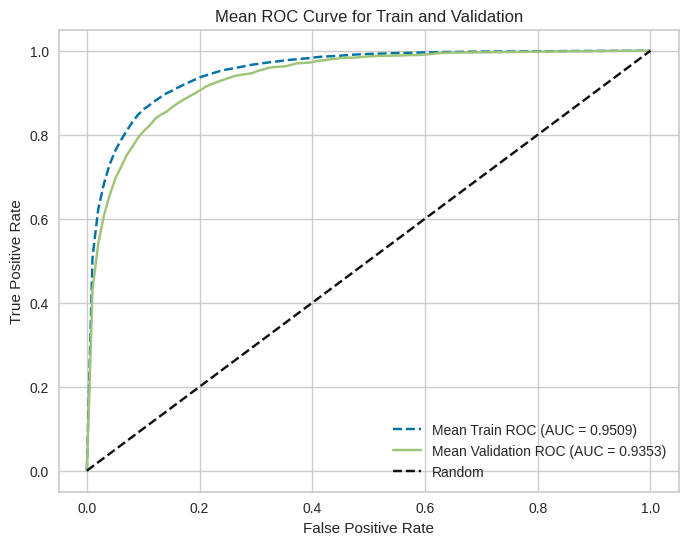

Fold 1
[0]	validation_0-auc:0.88773
[1]	validation_0-auc:0.89965
[2]	validation_0-auc:0.90788
[3]	validation_0-auc:0.90881
[4]	validation_0-auc:0.91050
[5]	validation_0-auc:0.91485
[6]	validation_0-auc:0.91481
[7]	validation_0-auc:0.91743
[8]	validation_0-auc:0.91673
[9]	validation_0-auc:0.91645
[10]	validation_0-auc:0.91922
[11]	validation_0-auc:0.92038
[12]	validation_0-auc:0.92115
[13]	validation_0-auc:0.92137
[14]	validation_0-auc:0.92218
[15]	validation_0-auc:0.92258
[16]	validation_0-auc:0.92188
[17]	validation_0-auc:0.92236
[18]	validation_0-auc:0.92232
[19]	validation_0-auc:0.92245
[20]	validation_0-auc:0.92282
[21]	validation_0-auc:0.92332
[22]	validation_0-auc:0.92329
[23]	validation_0-auc:0.92299
[24]	validation_0-auc:0.92411
[25]	validation_0-auc:0.92406
[26]	validation_0-auc:0.92371
[27]	validation_0-auc:0.92365
[28]	validation_0-auc:0.92406
[29]	validation_0-auc:0.92397
[30]	validation_0-auc:0.92371
[31]	validation_0-auc:0.92362
[32]	validation_0-auc:0.92432
[33]	validati

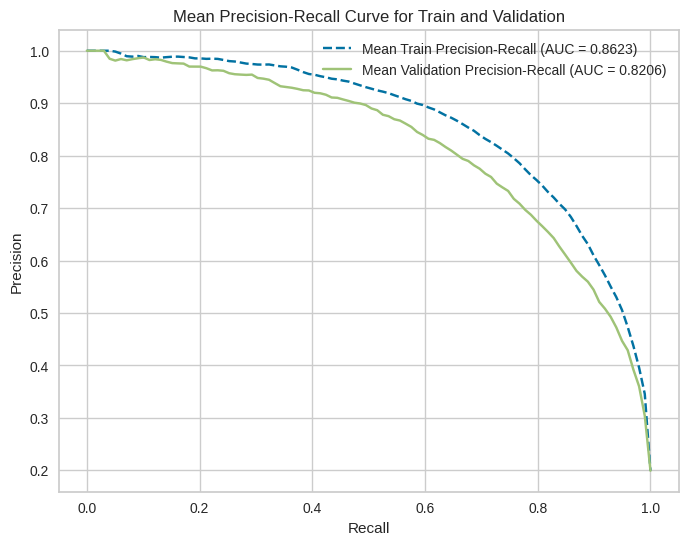

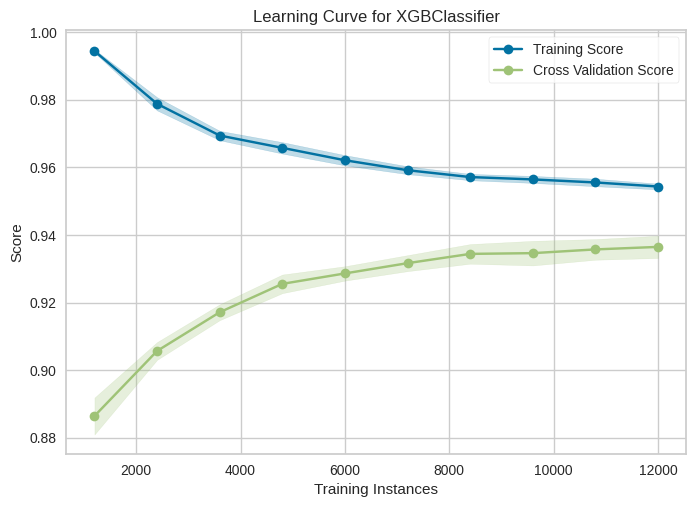

[0.00710341 0.17075568 0.01163968 0.02700588 0.16404627 0.00691434
 0.07073966 0.00820277 0.02334854 0.0106885  0.07270158 0.00442165
 0.04820956 0.17765151 0.08419904 0.07594742 0.03642459]


<Figure size 1000x600 with 0 Axes>

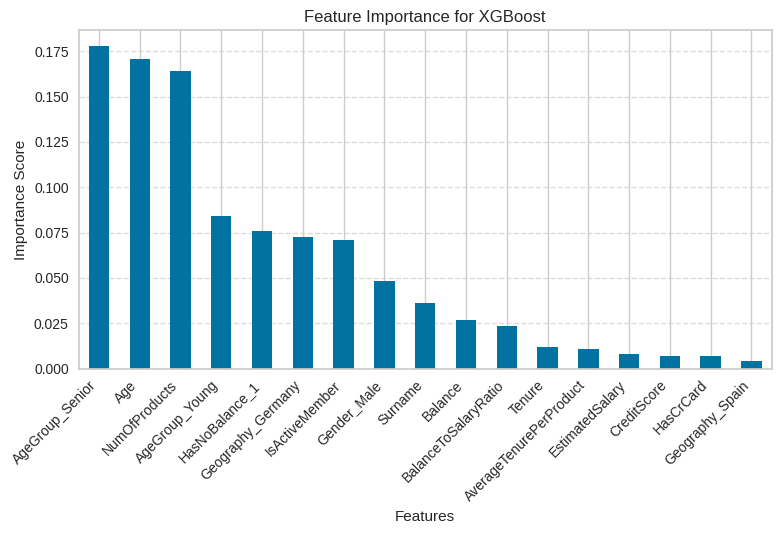

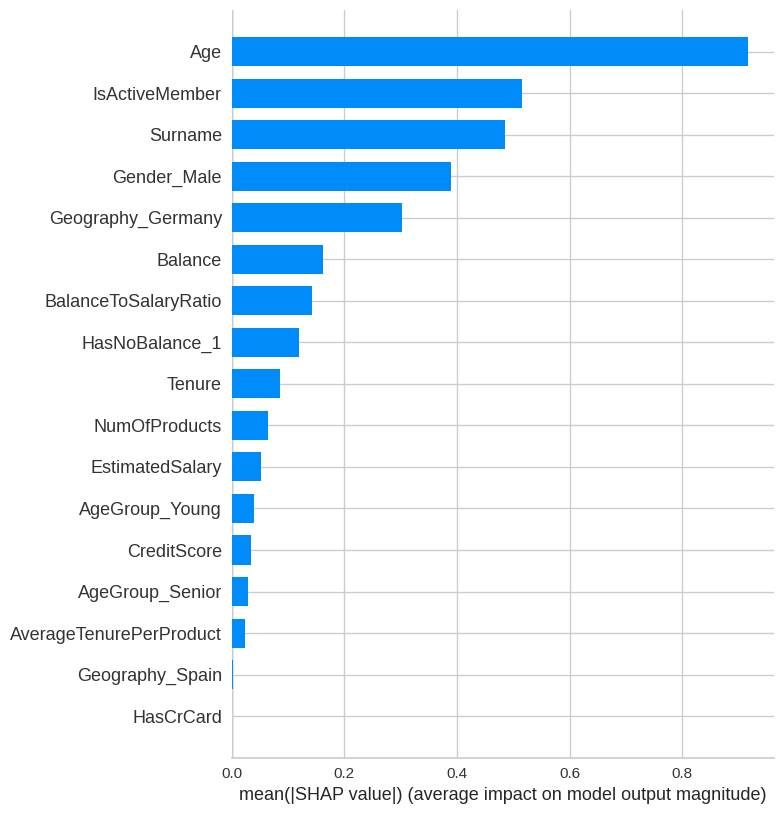

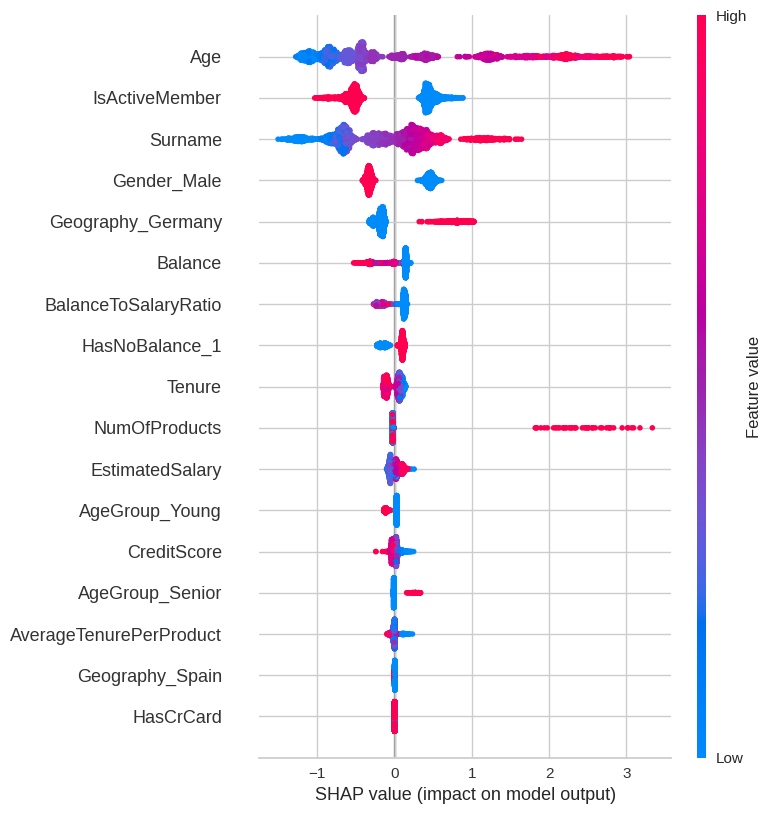

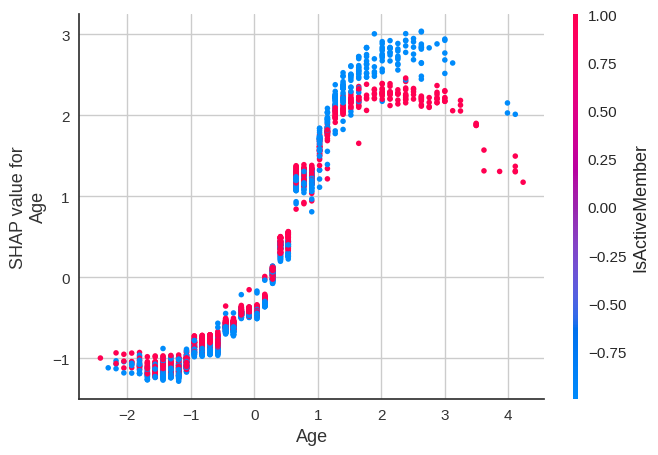

In [ ]:
# Utiliser les best params en haut

# Créer des nouvelles caractéristiques à partir des données
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 30, 50, 100], labels=['Young', 'Middle-aged', 'Senior'])
df['HasNoBalance'] = (df['Balance'] == 0).astype(int)
df['BalanceToSalaryRatio'] = df['Balance'] / (df['EstimatedSalary'] + 1e-5)
df['AverageTenurePerProduct'] = df['Tenure'] / (df['NumOfProducts'] + 1e-5)

test['AgeGroup'] = pd.cut(test['Age'], bins=[0, 30, 50, 100], labels=['Young', 'Middle-aged', 'Senior'])
test['HasNoBalance'] = (test['Balance'] == 0).astype(int)
test['BalanceToSalaryRatio'] = test['Balance'] / (test['EstimatedSalary'] + 1e-5)
test['AverageTenurePerProduct'] = test['Tenure'] / (test['NumOfProducts'] + 1e-5)

# Mettre à jour la liste des caractéristiques
X = df[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
        'Geography', 'Gender', 'Surname', 'BalanceToSalaryRatio', 'AgeGroup', 'AverageTenurePerProduct', 'HasNoBalance']]
y = df['Exited']
X_test = test[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
               'Geography', 'Gender', 'Surname', 'BalanceToSalaryRatio', 'AgeGroup','AverageTenurePerProduct', 'HasNoBalance']]
test_ids = test['id']

# Séparer les colonnes catégoriques et numériques
numerical_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
                      'EstimatedSalary', 'BalanceToSalaryRatio', 'AverageTenurePerProduct']
categorical_features = ['Geography', 'Gender', 'AgeGroup', 'HasNoBalance']
target_encoding_feature = ['Surname']

# Initialiser Target Encoder pour la colonne 'Surname'
target_encoder = ce.TargetEncoder(cols=target_encoding_feature)

# Pipeline pour traiter les colonnes catégoriques et numériques
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features),  # drop='first' pour éviter la multicolinéarité
        ('target_enc', target_encoder, target_encoding_feature)       # Appliquer le Target Encoding sur 'Surname'
    ])

# Ajuster le paramètre scale_pos_weight en fonction de la distribution de la variable cible
scale_pos_weight = y.value_counts()[0] / y.value_counts()[1]

# Initialiser le modèle XGBClassifier avec les meilleurs paramètres sélectionnés
xgb_classifier = xgb.XGBClassifier(
    n_estimators=290,           # Nombre d'arbres optimisé à 290
    max_depth=3,                # Profondeur maximale des arbres = 3
    learning_rate=0.04225,      # Taux d'apprentissage optimisé à ~0.042
    subsample=0.8558,           # Taux d'échantillonnage pour chaque arbre optimisé à ~0.856
    colsample_bytree=0.7978,    # Taux d'échantillonnage basé sur les colonnes optimisé à ~0.798
    min_child_weight=1.0,       # Nombre minimum d'échantillons par feuille optimisé à 1
    gamma=0.4795,               # Valeur gamma optimisée à ~0.48 pour contrôler la complexité du modèle
    scale_pos_weight=1.0,       # Équilibrage des classes optimisé
    reg_alpha=0.3029,           # Valeur alpha (régularisation L1) optimisée à ~0.303
    reg_lambda=0.9993,          # Valeur lambda (régularisation L2) optimisée à ~1.0
    random_state=42,            # Fixer une graine aléatoire pour la reproductibilité
    use_label_encoder=False,    # Désactiver l'encodeur de labels (inutile dans la nouvelle version de XGBoost)
    eval_metric='auc',          # Métrique utilisée pour l'évaluation
    early_stopping_rounds=25    # Arrêt précoce si aucun progrès après 25 itérations
)

# Créer un pipeline pour traiter les données et entraîner le modèle
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', xgb_classifier)])

# Initialiser StratifiedKFold avec k=5
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Enregistrer les valeurs fpr, tpr et roc_auc pour chaque pli
tprs_train = []
tprs_val = []
mean_fpr = np.linspace(0, 1, 100)

# Boucle à travers chaque pli
for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f"Fold {fold + 1}")

    # Diviser les ensembles d'entraînement et de validation
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # Prétraiter les données
    X_train_processed = preprocessor.fit_transform(X_train, y_train)
    X_val_processed = preprocessor.transform(X_val)

    # Ajuster le modèle sur l'ensemble d'entraînement avec early stopping
    xgb_classifier.fit(
        X_train_processed, y_train,
        eval_set=[(X_val_processed, y_val)],  # Fournir l'ensemble de validation
        verbose=True
    )

    # Prédire les probabilités
    y_train_pred = xgb_classifier.predict_proba(X_train_processed)[:, 1]
    y_val_pred = xgb_classifier.predict_proba(X_val_processed)[:, 1]

    # Calculer le ROC pour l'ensemble d'entraînement
    fpr_train, tpr_train, _ = roc_curve(y_train, y_train_pred)
    roc_auc_train = auc(fpr_train, tpr_train)
    tprs_train.append(np.interp(mean_fpr, fpr_train, tpr_train))  # Interpoler tpr selon mean_fpr
    tprs_train[-1][0] = 0.0

    # Calculer le ROC pour l'ensemble de validation
    fpr_val, tpr_val, _ = roc_curve(y_val, y_val_pred)
    roc_auc_val = auc(fpr_val, tpr_val)
    tprs_val.append(np.interp(mean_fpr, fpr_val, tpr_val))  # Interpoler tpr selon mean_fpr
    tprs_val[-1][0] = 0.0

    print(f"Train ROC AUC: {roc_auc_train:.4f}, Validation ROC AUC: {roc_auc_val:.4f}")

# Calculer la moyenne et l'intervalle de confiance
mean_tpr_train = np.mean(tprs_train, axis=0)
mean_tpr_val = np.mean(tprs_val, axis=0)
mean_tpr_train[-1] = 1.0
mean_tpr_val[-1] = 1.0

mean_auc_train = auc(mean_fpr, mean_tpr_train)
mean_auc_val = auc(mean_fpr, mean_tpr_val)

# Tracer la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(mean_fpr, mean_tpr_train, label=f"Mean Train ROC (AUC = {mean_auc_train:.4f})", linestyle="--")
plt.plot(mean_fpr, mean_tpr_val, label=f"Mean Validation ROC (AUC = {mean_auc_val:.4f})")

# Ajouter d'autres informations au graphique
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Mean ROC Curve for Train and Validation")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

################################################################################

from sklearn.metrics import precision_recall_curve, auc, PrecisionRecallDisplay

# Enregistrer les valeurs de Precision, Recall et les seuils pour chaque pli
precisions_train = []
recalls_train = []
precisions_val = []
recalls_val = []
mean_recall = np.linspace(0, 1, 100)

# Boucle à travers chaque pli
for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f"Fold {fold + 1}")

    # Diviser les ensembles d'entraînement et de validation
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # Prétraiter les données
    X_train_processed = preprocessor.fit_transform(X_train, y_train)
    X_val_processed = preprocessor.transform(X_val)

    # Ajuster le modèle sur l'ensemble d'entraînement avec early stopping
    xgb_classifier.fit(
        X_train_processed, y_train,
        eval_set=[(X_val_processed, y_val)],  # Fournir l'ensemble de validation
        verbose=True
    )

    # Prédire les probabilités
    y_train_pred = pipeline.predict_proba(X_train)[:, 1]
    y_val_pred = pipeline.predict_proba(X_val)[:, 1]

    # Calculer Precision-Recall pour l'ensemble d'entraînement
    precision_train, recall_train, _ = precision_recall_curve(y_train, y_train_pred)
    precisions_train.append(np.interp(mean_recall, recall_train[::-1], precision_train[::-1]))  # Interpoler Precision
    precisions_train[-1][0] = 1.0  # Precision commence à 1

    # Calculer Precision-Recall pour l'ensemble de validation
    precision_val, recall_val, _ = precision_recall_curve(y_val, y_val_pred)
    precisions_val.append(np.interp(mean_recall, recall_val[::-1], precision_val[::-1]))  # Interpoler Precision
    precisions_val[-1][0] = 1.0  # Precision commence à 1

    print(f"Fold {fold + 1} traité.")

# Calculer la moyenne de Precision-Recall
mean_precision_train = np.mean(precisions_train, axis=0)
mean_precision_val = np.mean(precisions_val, axis=0)

# Calculer l'AUC Precision-Recall
mean_auc_train = auc(mean_recall, mean_precision_train)
mean_auc_val = auc(mean_recall, mean_precision_val)

# Tracer la courbe Precision-Recall
plt.figure(figsize=(8, 6))
plt.plot(mean_recall, mean_precision_train, label=f"Mean Train Precision-Recall (AUC = {mean_auc_train:.4f})", linestyle="--")
plt.plot(mean_recall, mean_precision_val, label=f"Mean Validation Precision-Recall (AUC = {mean_auc_val:.4f})")

# Ajouter d'autres informations au graphique
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Mean Precision-Recall Curve for Train and Validation")
plt.legend(loc="upper right")
plt.grid(True)
plt.show()

################################################################################

from yellowbrick.model_selection import LearningCurve

# Initialiser le pipeline avec le modèle XGBClassifier sans early_stopping_rounds
xgb_classifier_without_early_stopping = xgb.XGBClassifier(
    n_estimators=290,           # Nombre d'arbres optimisé à 290
    max_depth=3,                # Profondeur maximale des arbres = 3
    learning_rate=0.04225,      # Taux d'apprentissage optimisé
    subsample=0.8558,           # Taux d'échantillonnage optimisé
    colsample_bytree=0.7978,    # Taux d'échantillonnage par colonnes optimisé
    min_child_weight=1.0,       # Nombre minimum d'échantillons par feuille
    gamma=0.4795,               # Valeur gamma optimisée
    scale_pos_weight=1.0,       # Équilibrage des classes
    reg_alpha=0.3029,           # Régularisation L1
    reg_lambda=0.9993,          # Régularisation L2
    random_state=42,            # Pour la reproductibilité
    use_label_encoder=False,    # Désactiver l'encodeur de labels (inutile dans les nouvelles versions)
    eval_metric='auc'           # Métrique utilisée pour l'évaluation
)

# Re-créer un pipeline sans early_stopping_rounds
pipeline_without_early_stopping = Pipeline(steps=[
    ('preprocessor', preprocessor),  # Étape de prétraitement
    ('classifier', xgb_classifier_without_early_stopping)  # Modèle XGBoost
])

# Initialiser le visualiseur LearningCurve
visualizer = LearningCurve(
    pipeline_without_early_stopping,  # Pipeline sans early_stopping_rounds
    cv=5,                             # Validation croisée avec 5 folds
    scoring='roc_auc',                # Mesure de performance: AUC
    train_sizes=np.linspace(0.1, 1.0, 10),  # Fraction des données d'entraînement
    random_state=42                   # Assurer la reproductibilité
)

# Ajuster et tracer la courbe d'apprentissage
visualizer.fit(X, y)
visualizer.show()

################################################################################

# Entraîner le pipeline sur l'ensemble des données
pipeline_without_early_stopping.fit(X, y)

# Extraire le modèle XGBoost du pipeline
xgb_model = pipeline.named_steps['classifier']

# Extraire l'importance des caractéristiques
feature_importances = xgb_model.feature_importances_
print(feature_importances)

# Créer un DataFrame pour une manipulation plus facile
feature_names = pipeline.named_steps['preprocessor'].transformers_[0][2] + \
                pipeline.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out().tolist() + \
                pipeline.named_steps['preprocessor'].transformers_[2][2]

# Créer un DataFrame pour l'importance des caractéristiques
feature_importances_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Trier par la valeur d'importance
feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)

# Tracer un graphique en barres
plt.figure(figsize=(10, 6))
feature_importances_df.plot(kind='bar', x='Feature', y='Importance', legend=False)
plt.title("Feature Importance for XGBoost")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

################################################################################

# Cette section est dédiée à SHAP
# Extraire les noms des caractéristiques depuis le préprocesseur
numerical_features = preprocessor.transformers_[0][2]  # Colonnes numériques
categorical_features = preprocessor.transformers_[1][1].get_feature_names_out().tolist()  # Colonnes encodées en OneHot
target_encoded_features = preprocessor.transformers_[2][2]  # Colonnes avec Target Encoding
all_features = numerical_features + categorical_features + target_encoded_features

# Calculer les valeurs SHAP sur l'ensemble de validation (utiliser le dernier fold comme exemple)
explainer = shap.Explainer(xgb_classifier, pipeline.named_steps['preprocessor'].transform(X_val))
shap_values = explainer(pipeline.named_steps['preprocessor'].transform(X_val))

# Afficher le graphique récapitulatif SHAP
shap.summary_plot(shap_values, feature_names=all_features, plot_type="bar")
shap.summary_plot(shap_values, feature_names=all_features)

# # Graphe de dépendance pour une caractéristique spécifique
# shap.dependence_plot("Age", shap_values.values, X_val, feature_names=all_features)

# Transformer les données avec le préprocesseur
X_val_processed = pipeline.named_steps['preprocessor'].transform(X_val)

# Extraire les noms des caractéristiques depuis le préprocesseur
numerical_features = preprocessor.transformers_[0][2]
categorical_features = preprocessor.transformers_[1][1].get_feature_names_out().tolist()
target_encoded_features = preprocessor.transformers_[2][2]

# Combiner les noms des caractéristiques
all_features = numerical_features + categorical_features + target_encoded_features

# Créer un explainer SHAP pour les données transformées
explainer = shap.Explainer(xgb_classifier, X_val_processed)

# Calculer les valeurs SHAP
shap_values = explainer(X_val_processed)

# Graphe de dépendance pour une caractéristique spécifique
shap.dependence_plot(
    "Age",  # Nom de la caractéristique (dans la liste all_features)
    shap_values.values,
    X_val_processed,
    feature_names=all_features
)

## Stacking

In [ ]:
# NE PAS LANCER
# Version 9 : Améliorée avec diversité des modèles + différentes méthodes de prétraitement

from sklearn.neural_network import MLPClassifier

# 1. Créer des nouvelles caractéristiques à partir des données
df['BalanceToSalaryRatio'] = df['Balance'] / (df['EstimatedSalary'] + 1e-5)
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 30, 50, 100], labels=['Young', 'Middle-aged', 'Senior'])
df['AverageTenurePerProduct'] = df['Tenure'] / (df['NumOfProducts'] + 1e-5)
df['HasNoBalance'] = (df['Balance'] == 0).astype(int)

test['BalanceToSalaryRatio'] = test['Balance'] / (test['EstimatedSalary'] + 1e-5)
test['AgeGroup'] = pd.cut(test['Age'], bins=[0, 30, 50, 100], labels=['Young', 'Middle-aged', 'Senior'])
test['AverageTenurePerProduct'] = test['Tenure'] / (test['NumOfProducts'] + 1e-5)
test['HasNoBalance'] = (test['Balance'] == 0).astype(int)

# Mettre à jour la liste des caractéristiques
X = df[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
        'Geography', 'Gender', 'Surname', 'BalanceToSalaryRatio', 'AgeGroup', 'AverageTenurePerProduct', 'HasNoBalance']]
y = df['Exited']
X_test = test[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
               'Geography', 'Gender', 'Surname', 'BalanceToSalaryRatio', 'AgeGroup','AverageTenurePerProduct', 'HasNoBalance']]
test_ids = test['id']

# Séparer les colonnes catégoriques et numériques
numerical_features = [
    'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
    'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
    'BalanceToSalaryRatio', 'AverageTenurePerProduct'
]
categorical_features = ['Geography', 'Gender', 'AgeGroup', 'HasNoBalance']
target_encoding_feature = ['Surname']

# Initialiser Target Encoder pour la colonne 'Surname'
target_encoder = ce.TargetEncoder(cols=target_encoding_feature)

# A. Créer des pipelines de prétraitement séparés

# Pipeline pour XGBoost et LightGBM
preprocessor_xgb_lgb = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features),
        ('target_enc', target_encoder, target_encoding_feature)
    ]
)

# Pipeline pour RandomForest
preprocessor_rf = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', ce.OrdinalEncoder(), categorical_features),
        ('target_enc', target_encoder, target_encoding_feature)
    ]
)

# Pipeline pour CatBoost
# Inclure 'Surname' dans les caractéristiques catégoriques pour CatBoost
categorical_features_cat = categorical_features + ['Surname']
numerical_features_cat = numerical_features  # Ne pas inclure 'Surname' dans les caractéristiques numériques

preprocessor_cat = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features_cat),
        ('cat', 'passthrough', categorical_features_cat)
    ]
)

# B. Ajouter Logistic Regression et MLPClassifier

# Initialiser le modèle Logistic Regression
lr_classifier = LogisticRegression(max_iter=1000)

# Initialiser le modèle MLPClassifier
mlp_classifier = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

# C. Mettre à jour la boucle d'entraînement

# 2. Ajuster le paramètre scale_pos_weight
scale_pos_weight = y.value_counts()[0] / y.value_counts()[1]

# Initialiser les modèles
xgb_classifier = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=1.0,
    colsample_bytree=0.8,
    min_child_weight=1,
    gamma=0,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    use_label_encoder=False,
    eval_metric='auc'
)

lgb_classifier = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=1.0,
    colsample_bytree=0.8,
    min_child_weight=1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    verbose=-1
)

cat_classifier = cb.CatBoostClassifier(
    iterations=200,
    depth=3,
    learning_rate=0.05,
    subsample=1.0,
    colsample_bylevel=0.8,
    min_data_in_leaf=1,
    scale_pos_weight=scale_pos_weight,
    random_seed=42,
    eval_metric='AUC',
    verbose=0
)

rf_classifier = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=1,
    max_features='log2',
    criterion='entropy',
    bootstrap=True,
    class_weight='balanced',
    random_state=42
)

# Créer StratifiedKFold
n_splits = 5
stratified_kfold = StratifiedKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=42
)

# Initialiser les tableaux pour OOF predictions et prédictions moyennes
oof_xgb = np.zeros(len(X))
oof_lgb = np.zeros(len(X))
oof_cat = np.zeros(len(X))
oof_rf = np.zeros(len(X))
oof_lr = np.zeros(len(X))
oof_mlp = np.zeros(len(X))

test_pred_xgb = np.zeros(len(X_test))
test_pred_lgb = np.zeros(len(X_test))
test_pred_cat = np.zeros(len(X_test))
test_pred_rf = np.zeros(len(X_test))
test_pred_lr = np.zeros(len(X_test))
test_pred_mlp = np.zeros(len(X_test))

for fold, (train_index, valid_index) in enumerate(
    stratified_kfold.split(X, y), start=1
):
    X_train, X_valid = X.iloc[train_index], X.iloc[valid_index]
    y_train, y_valid = y.iloc[train_index], y.iloc[valid_index]

    # Prétraiter les données pour chaque modèle
    # XGBoost et LightGBM
    X_train_xgb_lgb = preprocessor_xgb_lgb.fit_transform(X_train, y_train)
    X_valid_xgb_lgb = preprocessor_xgb_lgb.transform(X_valid)
    X_test_xgb_lgb = preprocessor_xgb_lgb.transform(X_test)

    # RandomForest
    X_train_rf = preprocessor_rf.fit_transform(X_train, y_train)
    X_valid_rf = preprocessor_rf.transform(X_valid)
    X_test_rf = preprocessor_rf.transform(X_test)

    # CatBoost
    preprocessor_cat.fit(X_train)
    X_train_cat = preprocessor_cat.transform(X_train)
    X_valid_cat = preprocessor_cat.transform(X_valid)
    X_test_cat = preprocessor_cat.transform(X_test)

    # Obtenir la liste des colonnes après prétraitement pour CatBoost
    feature_names_cat = numerical_features_cat + categorical_features_cat
    # Créer un mapping entre noms des colonnes et indices
    feature_indices_cat = {name: idx for idx, name in enumerate(feature_names_cat)}
    # Obtenir les indices des colonnes catégoriques
    cat_features_indices = [feature_indices_cat[col] for col in categorical_features_cat]

    # Logistic Regression
    X_train_lr = X_train_xgb_lgb
    X_valid_lr = X_valid_xgb_lgb
    X_test_lr = X_test_xgb_lgb

    # MLPClassifier
    X_train_mlp = X_train_xgb_lgb
    X_valid_mlp = X_valid_xgb_lgb
    X_test_mlp = X_test_xgb_lgb

    # Entraîner et prédire avec les modèles correspondants
    # XGBoost
    xgb_classifier.fit(X_train_xgb_lgb, y_train)
    oof_xgb[valid_index] = xgb_classifier.predict_proba(X_valid_xgb_lgb)[:, 1]
    test_pred_xgb += xgb_classifier.predict_proba(X_test_xgb_lgb)[:, 1] / n_splits
    print(
        f"Fold {fold} - XGBoost ROC AUC: "
        f"{roc_auc_score(y_valid, oof_xgb[valid_index]):.4f}"
    )

    # LightGBM
    lgb_classifier.fit(X_train_xgb_lgb, y_train)
    oof_lgb[valid_index] = lgb_classifier.predict_proba(X_valid_xgb_lgb)[:, 1]
    test_pred_lgb += lgb_classifier.predict_proba(X_test_xgb_lgb)[:, 1] / n_splits
    print(
        f"Fold {fold} - LightGBM ROC AUC: "
        f"{roc_auc_score(y_valid, oof_lgb[valid_index]):.4f}"
    )

    # CatBoost
    cat_classifier.fit(
        X_train_cat, y_train, cat_features=cat_features_indices
    )
    oof_cat[valid_index] = cat_classifier.predict_proba(X_valid_cat)[:, 1]
    test_pred_cat += cat_classifier.predict_proba(X_test_cat)[:, 1] / n_splits
    print(
        f"Fold {fold} - CatBoost ROC AUC: "
        f"{roc_auc_score(y_valid, oof_cat[valid_index]):.4f}"
    )

    # RandomForest
    rf_classifier.fit(X_train_rf, y_train)
    oof_rf[valid_index] = rf_classifier.predict_proba(X_valid_rf)[:, 1]
    test_pred_rf += rf_classifier.predict_proba(X_test_rf)[:, 1] / n_splits
    print(
        f"Fold {fold} - RandomForest ROC AUC: "
        f"{roc_auc_score(y_valid, oof_rf[valid_index]):.4f}"
    )

    # Logistic Regression
    lr_classifier.fit(X_train_lr, y_train)
    oof_lr[valid_index] = lr_classifier.predict_proba(X_valid_lr)[:, 1]
    test_pred_lr += lr_classifier.predict_proba(X_test_lr)[:, 1] / n_splits
    print(
        f"Fold {fold} - Logistic Regression ROC AUC: "
        f"{roc_auc_score(y_valid, oof_lr[valid_index]):.4f}"
    )

    # MLPClassifier
    mlp_classifier.fit(X_train_mlp, y_train)
    oof_mlp[valid_index] = mlp_classifier.predict_proba(X_valid_mlp)[:, 1]
    test_pred_mlp += mlp_classifier.predict_proba(X_test_mlp)[:, 1] / n_splits
    print(
        f"Fold {fold} - MLPClassifier ROC AUC: "
        f"{roc_auc_score(y_valid, oof_mlp[valid_index]):.4f}"
    )

    print("-" * 50)

# D. Entraîner un méta-classifier avec LogisticRegression

# Initialiser les listes pour stocker les résultats AUC
train_auc_stacking = []
test_auc_stacking = []

# Empiler les prédictions OOF comme caractéristiques pour le méta-modèle
X_meta = np.column_stack((oof_xgb, oof_lgb, oof_cat, oof_rf, oof_lr, oof_mlp))
X_test_meta = np.column_stack((test_pred_xgb, test_pred_lgb, test_pred_cat, test_pred_rf, test_pred_lr, test_pred_mlp))

print("X_meta (une partie):")
print(X_meta[:10])  # Afficher les 10 premières lignes pour vérifier
print("Taille de X_meta:", X_meta.shape)

# Boucle sur chaque fold pour calculer l'AUC
for fold, (train_index, valid_index) in enumerate(stratified_kfold.split(X_meta, y), start=1):
    # Diviser les données en train et validation pour le méta-classifier
    X_meta_train, X_meta_valid = X_meta[train_index], X_meta[valid_index]
    y_meta_train, y_meta_valid = y.iloc[train_index], y.iloc[valid_index]

    # Entraîner le méta-classifier
    meta_classifier = LogisticRegression(max_iter=1000)
    meta_classifier.fit(X_meta_train, y_meta_train)

    # Prédire les probabilités sur l'ensemble d'entraînement (train) et de validation (test)
    train_pred_meta = meta_classifier.predict_proba(X_meta_train)[:, 1]
    test_pred_meta = meta_classifier.predict_proba(X_meta_valid)[:, 1]

    # Calculer les AUC pour ce pli
    train_auc = roc_auc_score(y_meta_train, train_pred_meta)
    test_auc = roc_auc_score(y_meta_valid, test_pred_meta)

    # Ajouter les résultats dans les listes
    train_auc_stacking.append(train_auc)
    test_auc_stacking.append(test_auc)

    print(f"Fold {fold} - Stacking Train ROC AUC: {train_auc:.4f}, Test ROC AUC: {test_auc:.4f}")

# Calculer et afficher les résultats moyens
mean_train_auc = np.mean(train_auc_stacking)
mean_test_auc = np.mean(test_auc_stacking)
print("=" * 50)
print(f"Mean Stacking Train ROC AUC: {mean_train_auc:.4f}")
print(f"Mean Stacking Test ROC AUC: {mean_test_auc:.4f}")
print("=" * 50)

# Prédire sur l'ensemble de test complet
final_meta_classifier = LogisticRegression(max_iter=1000)
final_meta_classifier.fit(X_meta, y)
final_predictions = final_meta_classifier.predict_proba(X_test_meta)[:, 1]

# Exporter les résultats
result_df = pd.DataFrame({
    'id': test_ids,
    'Exited': final_predictions
})
result_df.to_csv('test_predictions_stacked_stk_v9.csv', index=False)
print("Les prédictions ont été enregistrées dans 'test_predictions_stacked_stk_v9.csv'.")

# Si nécessaire, télécharger le fichier CSV
# files.download('test_predictions_stacked_stk_v9.csv')

Fold 1 - XGBoost ROC AUC: 0.9384
Fold 1 - LightGBM ROC AUC: 0.9387
Fold 1 - CatBoost ROC AUC: 0.9405
Fold 1 - RandomForest ROC AUC: 0.9343
Fold 1 - Logistic Regression ROC AUC: 0.8925
Fold 1 - MLPClassifier ROC AUC: 0.9321
--------------------------------------------------
Fold 2 - XGBoost ROC AUC: 0.9392
Fold 2 - LightGBM ROC AUC: 0.9397
Fold 2 - CatBoost ROC AUC: 0.9460
Fold 2 - RandomForest ROC AUC: 0.9375
Fold 2 - Logistic Regression ROC AUC: 0.9005
Fold 2 - MLPClassifier ROC AUC: 0.9385
--------------------------------------------------
Fold 3 - XGBoost ROC AUC: 0.9344
Fold 3 - LightGBM ROC AUC: 0.9347
Fold 3 - CatBoost ROC AUC: 0.9352
Fold 3 - RandomForest ROC AUC: 0.9287
Fold 3 - Logistic Regression ROC AUC: 0.8950
Fold 3 - MLPClassifier ROC AUC: 0.9255
--------------------------------------------------
Fold 4 - XGBoost ROC AUC: 0.9324
Fold 4 - LightGBM ROC AUC: 0.9320
Fold 4 - CatBoost ROC AUC: 0.9347
Fold 4 - RandomForest ROC AUC: 0.9297
Fold 4 - Logistic Regression ROC AUC: 0

In [ ]:
# NE PAS LANCER
# Version : test_predictions_stacked_stk_v9_weighted_GridSearchCV

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.neural_network import MLPClassifier

# 1. Créer des nouvelles caractéristiques à partir des données
df['BalanceToSalaryRatio'] = df['Balance'] / (df['EstimatedSalary'] + 1e-5)
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 30, 50, 100], labels=['Young', 'Middle-aged', 'Senior'])
df['AverageTenurePerProduct'] = df['Tenure'] / (df['NumOfProducts'] + 1e-5)
df['HasNoBalance'] = (df['Balance'] == 0).astype(int)

test['BalanceToSalaryRatio'] = test['Balance'] / (test['EstimatedSalary'] + 1e-5)
test['AgeGroup'] = pd.cut(test['Age'], bins=[0, 30, 50, 100], labels=['Young', 'Middle-aged', 'Senior'])
test['AverageTenurePerProduct'] = test['Tenure'] / (test['NumOfProducts'] + 1e-5)
test['HasNoBalance'] = (test['Balance'] == 0).astype(int)

# Mettre à jour la liste des caractéristiques
X = df[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
        'Geography', 'Gender', 'Surname', 'BalanceToSalaryRatio', 'AgeGroup', 'AverageTenurePerProduct', 'HasNoBalance']]
y = df['Exited']
X_test = test[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
               'Geography', 'Gender', 'Surname', 'BalanceToSalaryRatio', 'AgeGroup','AverageTenurePerProduct', 'HasNoBalance']]
test_ids = test['id']

# Séparer les colonnes catégoriques et numériques
numerical_features = [
    'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
    'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
    'BalanceToSalaryRatio', 'AverageTenurePerProduct'
]
categorical_features = ['Geography', 'Gender', 'AgeGroup', 'HasNoBalance']
target_encoding_feature = ['Surname']

# Initialiser Target Encoder pour la colonne 'Surname'
target_encoder = ce.TargetEncoder(cols=target_encoding_feature)

# A. Créer des pipelines de prétraitement séparés

# Pipeline pour XGBoost et LightGBM
preprocessor_xgb_lgb = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features),
        ('target_enc', target_encoder, target_encoding_feature)
    ]
)

# Pipeline pour RandomForest
preprocessor_rf = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', ce.OrdinalEncoder(), categorical_features),
        ('target_enc', target_encoder, target_encoding_feature)
    ]
)

# Pipeline pour CatBoost
# Inclure 'Surname' dans les caractéristiques catégoriques pour CatBoost
categorical_features_cat = categorical_features + ['Surname']
numerical_features_cat = numerical_features  # Ne pas inclure 'Surname' dans les caractéristiques numériques

preprocessor_cat = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features_cat),
        ('cat', 'passthrough', categorical_features_cat)
    ]
)

# B. Ajouter Logistic Regression et MLPClassifier

# Initialiser le modèle Logistic Regression
lr_classifier = LogisticRegression(max_iter=1000)

# Initialiser le modèle MLPClassifier
mlp_classifier = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

# C. Mettre à jour la boucle d'entraînement

# 2. Ajuster le paramètre scale_pos_weight
scale_pos_weight = y.value_counts()[0] / y.value_counts()[1]

# Initialiser les modèles
xgb_classifier = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=1.0,
    colsample_bytree=0.8,
    min_child_weight=1,
    gamma=0,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    use_label_encoder=False,
    eval_metric='auc'
)

lgb_classifier = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=1.0,
    colsample_bytree=0.8,
    min_child_weight=1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    verbose=-1
)

cat_classifier = cb.CatBoostClassifier(
    iterations=200,
    depth=3,
    learning_rate=0.05,
    subsample=1.0,
    colsample_bylevel=0.8,
    min_data_in_leaf=1,
    scale_pos_weight=scale_pos_weight,
    random_seed=42,
    eval_metric='AUC',
    verbose=0
)

rf_classifier = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=1,
    max_features='log2',
    criterion='entropy',
    bootstrap=True,
    class_weight='balanced',
    random_state=42
)

# Créer StratifiedKFold
n_splits = 5
stratified_kfold = StratifiedKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=42
)

# Initialiser les tableaux pour OOF predictions et prédictions moyennes
oof_xgb = np.zeros(len(X))
oof_lgb = np.zeros(len(X))
oof_cat = np.zeros(len(X))
oof_rf = np.zeros(len(X))
oof_lr = np.zeros(len(X))
oof_mlp = np.zeros(len(X))

test_pred_xgb = np.zeros(len(X_test))
test_pred_lgb = np.zeros(len(X_test))
test_pred_cat = np.zeros(len(X_test))
test_pred_rf = np.zeros(len(X_test))
test_pred_lr = np.zeros(len(X_test))
test_pred_mlp = np.zeros(len(X_test))

# Initialiser des listes pour stocker les AUC de chaque modèle par pli (fold)
xgb_auc_folds = []
lgb_auc_folds = []
cat_auc_folds = []
rf_auc_folds = []
lr_auc_folds = []
mlp_auc_folds = []

for fold, (train_index, valid_index) in enumerate(
    stratified_kfold.split(X, y), start=1
):
    X_train, X_valid = X.iloc[train_index], X.iloc[valid_index]
    y_train, y_valid = y.iloc[train_index], y.iloc[valid_index]

    # Prétraiter les données pour chaque modèle
    # XGBoost et LightGBM
    X_train_xgb_lgb = preprocessor_xgb_lgb.fit_transform(X_train, y_train)
    X_valid_xgb_lgb = preprocessor_xgb_lgb.transform(X_valid)
    X_test_xgb_lgb = preprocessor_xgb_lgb.transform(X_test)

    # RandomForest
    X_train_rf = preprocessor_rf.fit_transform(X_train, y_train)
    X_valid_rf = preprocessor_rf.transform(X_valid)
    X_test_rf = preprocessor_rf.transform(X_test)

    # CatBoost
    preprocessor_cat.fit(X_train)
    X_train_cat = preprocessor_cat.transform(X_train)
    X_valid_cat = preprocessor_cat.transform(X_valid)
    X_test_cat = preprocessor_cat.transform(X_test)

    # Obtenir la liste des colonnes après prétraitement pour CatBoost
    feature_names_cat = numerical_features_cat + categorical_features_cat
    # Créer un mapping entre noms des colonnes et indices
    feature_indices_cat = {name: idx for idx, name in enumerate(feature_names_cat)}
    # Obtenir les indices des colonnes catégoriques
    cat_features_indices = [feature_indices_cat[col] for col in categorical_features_cat]

    # Logistic Regression
    X_train_lr = X_train_xgb_lgb
    X_valid_lr = X_valid_xgb_lgb
    X_test_lr = X_test_xgb_lgb

    # MLPClassifier
    X_train_mlp = X_train_xgb_lgb
    X_valid_mlp = X_valid_xgb_lgb
    X_test_mlp = X_test_xgb_lgb

    # Entraîner et prédire avec les modèles correspondants
    # XGBoost
    xgb_classifier.fit(X_train_xgb_lgb, y_train)
    oof_xgb[valid_index] = xgb_classifier.predict_proba(X_valid_xgb_lgb)[:, 1]
    test_pred_xgb += xgb_classifier.predict_proba(X_test_xgb_lgb)[:, 1] / n_splits
    xgb_auc = roc_auc_score(y_valid, oof_xgb[valid_index])
    print(
        f"Fold {fold} - XGBoost ROC AUC: "
        f"{xgb_auc}"
    )
    xgb_auc_folds.append(xgb_auc)

    # LightGBM
    lgb_classifier.fit(X_train_xgb_lgb, y_train)
    oof_lgb[valid_index] = lgb_classifier.predict_proba(X_valid_xgb_lgb)[:, 1]
    test_pred_lgb += lgb_classifier.predict_proba(X_test_xgb_lgb)[:, 1] / n_splits
    lgb_auc = roc_auc_score(y_valid, oof_lgb[valid_index])
    print(
        f"Fold {fold} - LightGBM ROC AUC: "
        f"{lgb_auc}"
    )
    lgb_auc_folds.append(lgb_auc)

    # CatBoost
    cat_classifier.fit(
        X_train_cat, y_train, cat_features=cat_features_indices
    )
    oof_cat[valid_index] = cat_classifier.predict_proba(X_valid_cat)[:, 1]
    test_pred_cat += cat_classifier.predict_proba(X_test_cat)[:, 1] / n_splits
    cat_auc = roc_auc_score(y_valid, oof_cat[valid_index])
    print(
        f"Fold {fold} - CatBoost ROC AUC: "
        f"{cat_auc}"
    )
    cat_auc_folds.append(cat_auc)

    # RandomForest
    rf_classifier.fit(X_train_rf, y_train)
    oof_rf[valid_index] = rf_classifier.predict_proba(X_valid_rf)[:, 1]
    test_pred_rf += rf_classifier.predict_proba(X_test_rf)[:, 1] / n_splits
    rf_auc = roc_auc_score(y_valid, oof_rf[valid_index])
    print(
        f"Fold {fold} - RandomForest ROC AUC: "
        f"{rf_auc}"
    )
    rf_auc_folds.append(rf_auc)

    # Logistic Regression
    lr_classifier.fit(X_train_lr, y_train)
    oof_lr[valid_index] = lr_classifier.predict_proba(X_valid_lr)[:, 1]
    test_pred_lr += lr_classifier.predict_proba(X_test_lr)[:, 1] / n_splits
    lr_auc = roc_auc_score(y_valid, oof_lr[valid_index])
    print(
        f"Fold {fold} - Logistic Regression ROC AUC: "
        f"{lr_auc}"
    )
    lr_auc_folds.append(lr_auc)

    # MLPClassifier
    mlp_classifier.fit(X_train_mlp, y_train)
    oof_mlp[valid_index] = mlp_classifier.predict_proba(X_valid_mlp)[:, 1]
    test_pred_mlp += mlp_classifier.predict_proba(X_test_mlp)[:, 1] / n_splits
    mlp_auc = roc_auc_score(y_valid, oof_mlp[valid_index])
    print(
        f"Fold {fold} - MLPClassifier ROC AUC: "
        f"{mlp_auc}"
    )
    mlp_auc_folds.append(mlp_auc)

    print("-" * 50)

# Calculer les AUC moyens pour chaque modèle
mean_xgb_auc = np.mean(xgb_auc_folds)
mean_lgb_auc = np.mean(lgb_auc_folds)
mean_cat_auc = np.mean(cat_auc_folds)
mean_rf_auc = np.mean(rf_auc_folds)
mean_lr_auc = np.mean(lr_auc_folds)
mean_mlp_auc = np.mean(mlp_auc_folds)

# Afficher les résultats
print("=" * 50)
print(f"Mean XGBoost ROC AUC: {mean_xgb_auc:.4f}")
print(f"Mean LightGBM ROC AUC: {mean_lgb_auc:.4f}")
print(f"Mean CatBoost ROC AUC: {mean_cat_auc:.4f}")
print(f"Mean RandomForest ROC AUC: {mean_rf_auc:.4f}")
print(f"Mean Logistic Regression ROC AUC: {mean_lr_auc:.4f}")
print(f"Mean MLPClassifier ROC AUC: {mean_mlp_auc:.4f}")
print("=" * 50)

# D. Entraîner un méta-classifier avec LogisticRegression

# Initialiser les listes pour stocker les résultats AUC
train_auc_stacking = []
test_auc_stacking = []

# Empiler les prédictions OOF comme caractéristiques pour le méta-modèle
X_meta = np.column_stack((oof_xgb, oof_lgb, oof_cat, oof_rf, oof_lr, oof_mlp))
X_test_meta = np.column_stack((test_pred_xgb, test_pred_lgb, test_pred_cat, test_pred_rf, test_pred_lr, test_pred_mlp))

print("X_meta (une partie):")
print(X_meta[:10])  # Afficher les 10 premières lignes pour vérifier
print("Taille de X_meta:", X_meta.shape)

# 1. Ajouter GridSearchCV pour optimiser LogisticRegression en tant que méta-classifier
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],  # Prise en charge des pénalités l1 et l2
}
grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    cv=5,
    scoring='roc_auc',
    verbose=1
)

# Exécuter la recherche de grille pour ajuster les hyperparamètres
grid_search.fit(X_meta, y)

# Obtenir le meilleur modèle à partir de GridSearchCV
meta_classifier = grid_search.best_estimator_

print("Best hyperparameters for Logistic Regression (meta-classifier):")
print(grid_search.best_params_)

# 2. Equilibrer les poids des modèles méta-classifier
mean_aucs = {
    'XGBoost': mean_xgb_auc,
    'LightGBM': mean_lgb_auc,
    'CatBoost': mean_cat_auc,
    'RandomForest': mean_rf_auc,
    'LogisticRegression': mean_lr_auc,
    'MLP': mean_mlp_auc
}

total_auc = sum(mean_aucs.values())
weights = {model: auc / total_auc for model, auc in mean_aucs.items()}

print("Weights for stacking based on mean AUCs:")
for model, weight in weights.items():
    print(f"{model}: {weight:.4f}")

# Ajuster les poids sur X_meta avant l'entraînement du méta-classifier
X_meta_weighted = X_meta * np.array(list(weights.values()))

# Entraîner Logistic Regression avec GridSearchCV pour le stacking final
meta_classifier = LogisticRegression(
    max_iter=1000, **grid_search.best_params_
)
meta_classifier.fit(X_meta_weighted, y)

# Prédire sur l'ensemble de test
final_predictions = meta_classifier.predict_proba(X_test_meta)[:, 1]

# Boucle sur chaque fold pour calculer l'AUC
for fold, (train_index, valid_index) in enumerate(stratified_kfold.split(X_meta, y), start=1):
    # Diviser les données en train et validation pour le méta-classifier
    X_meta_train, X_meta_valid = X_meta[train_index], X_meta[valid_index]
    y_meta_train, y_meta_valid = y.iloc[train_index], y.iloc[valid_index]

    # Entraîner le méta-classifier
    meta_classifier.fit(X_meta_train, y_meta_train)

    # Prédire les probabilités sur l'ensemble d'entraînement (train) et de validation (test)
    train_pred_meta = meta_classifier.predict_proba(X_meta_train)[:, 1]
    test_pred_meta = meta_classifier.predict_proba(X_meta_valid)[:, 1]

    # Calculer les AUC pour ce pli
    train_auc = roc_auc_score(y_meta_train, train_pred_meta)
    test_auc = roc_auc_score(y_meta_valid, test_pred_meta)

    # Ajouter les résultats dans les listes
    train_auc_stacking.append(train_auc)
    test_auc_stacking.append(test_auc)

    print(f"Fold {fold} - Stacking Train ROC AUC: {train_auc:.4f}, Test ROC AUC: {test_auc:.4f}")

# Calculer et afficher les résultats moyens
mean_train_auc = np.mean(train_auc_stacking)
mean_test_auc = np.mean(test_auc_stacking)
print("=" * 50)
print(f"Mean Stacking Train ROC AUC: {mean_train_auc:.4f}")
print(f"Mean Stacking Test ROC AUC: {mean_test_auc:.4f}")
print("=" * 50)

# Exporter les résultats
result_df = pd.DataFrame({
    'id': test_ids,
    'Exited': final_predictions
})
result_df.to_csv('test_predictions_stacked_stk_v9_weighted_GridSearchCV.csv', index=False)
print("Les prédictions ont été enregistrées dans 'test_predictions_stacked_stk_v9_weighted_GridSearchCV.csv'.")

# Si nécessaire, télécharger le fichier CSV
# files.download('test_predictions_stacked_stk_v9_weighted_GridSearchCV.csv')

Fold 1 - XGBoost ROC AUC: 0.9383965146101771
Fold 1 - LightGBM ROC AUC: 0.9386826474036409
Fold 1 - CatBoost ROC AUC: 0.9405240616097512
Fold 1 - RandomForest ROC AUC: 0.9343467957304252
Fold 1 - Logistic Regression ROC AUC: 0.8924948273317386
Fold 1 - MLPClassifier ROC AUC: 0.932132225375175
--------------------------------------------------
Fold 2 - XGBoost ROC AUC: 0.9391765919704594
Fold 2 - LightGBM ROC AUC: 0.9396973397308264
Fold 2 - CatBoost ROC AUC: 0.9459898245330675
Fold 2 - RandomForest ROC AUC: 0.9375012183269794
Fold 2 - Logistic Regression ROC AUC: 0.9005016722408026
Fold 2 - MLPClassifier ROC AUC: 0.9384988540764525
--------------------------------------------------
Fold 3 - XGBoost ROC AUC: 0.9343823012595414
Fold 3 - LightGBM ROC AUC: 0.9347230847203696
Fold 3 - CatBoost ROC AUC: 0.9351836123186085
Fold 3 - RandomForest ROC AUC: 0.9286561644560414
Fold 3 - Logistic Regression ROC AUC: 0.8950414788122494
Fold 3 - MLPClassifier ROC AUC: 0.9254843371883519
--------------

In [ ]:
# NE PAS LANCER
# Version : test_predictions_stacked_stk_v9_weighted_optuna_GradientBoostingClassifier

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
import optuna

# 1. Créer des nouvelles caractéristiques à partir des données
df['BalanceToSalaryRatio'] = df['Balance'] / (df['EstimatedSalary'] + 1e-5)
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 30, 50, 100], labels=['Young', 'Middle-aged', 'Senior'])
df['AverageTenurePerProduct'] = df['Tenure'] / (df['NumOfProducts'] + 1e-5)
df['HasNoBalance'] = (df['Balance'] == 0).astype(int)

test['BalanceToSalaryRatio'] = test['Balance'] / (test['EstimatedSalary'] + 1e-5)
test['AgeGroup'] = pd.cut(test['Age'], bins=[0, 30, 50, 100], labels=['Young', 'Middle-aged', 'Senior'])
test['AverageTenurePerProduct'] = test['Tenure'] / (test['NumOfProducts'] + 1e-5)
test['HasNoBalance'] = (test['Balance'] == 0).astype(int)

# Mettre à jour la liste des caractéristiques
X = df[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
        'Geography', 'Gender', 'Surname', 'BalanceToSalaryRatio', 'AgeGroup', 'AverageTenurePerProduct', 'HasNoBalance']]
y = df['Exited']
X_test = test[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
               'Geography', 'Gender', 'Surname', 'BalanceToSalaryRatio', 'AgeGroup','AverageTenurePerProduct', 'HasNoBalance']]
test_ids = test['id']

# Séparer les colonnes catégoriques et numériques
numerical_features = [
    'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
    'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
    'BalanceToSalaryRatio', 'AverageTenurePerProduct'
]
categorical_features = ['Geography', 'Gender', 'AgeGroup', 'HasNoBalance']
target_encoding_feature = ['Surname']

# Initialiser Target Encoder pour la colonne 'Surname'
target_encoder = ce.TargetEncoder(cols=target_encoding_feature)

# A. Créer des pipelines de prétraitement séparés

# Pipeline pour XGBoost et LightGBM
preprocessor_xgb_lgb = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features),
        ('target_enc', target_encoder, target_encoding_feature)
    ]
)

# Pipeline pour RandomForest
preprocessor_rf = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', ce.OrdinalEncoder(), categorical_features),
        ('target_enc', target_encoder, target_encoding_feature)
    ]
)

# Pipeline pour CatBoost
# Inclure 'Surname' dans les caractéristiques catégoriques pour CatBoost
categorical_features_cat = categorical_features + ['Surname']
numerical_features_cat = numerical_features  # Ne pas inclure 'Surname' dans les caractéristiques numériques

preprocessor_cat = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features_cat),
        ('cat', 'passthrough', categorical_features_cat)
    ]
)

# B. Ajouter Logistic Regression et MLPClassifier

# Initialiser le modèle Logistic Regression
lr_classifier = LogisticRegression(max_iter=1000)

# Initialiser le modèle MLPClassifier
mlp_classifier = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

# C. Mettre à jour la boucle d'entraînement

# 2. Ajuster le paramètre scale_pos_weight
scale_pos_weight = y.value_counts()[0] / y.value_counts()[1]

# Initialiser les modèles
xgb_classifier = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=1.0,
    colsample_bytree=0.8,
    min_child_weight=1,
    gamma=0,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    use_label_encoder=False,
    eval_metric='auc'
)

lgb_classifier = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=1.0,
    colsample_bytree=0.8,
    min_child_weight=1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    verbose=-1
)

cat_classifier = cb.CatBoostClassifier(
    iterations=200,
    depth=3,
    learning_rate=0.05,
    subsample=1.0,
    colsample_bylevel=0.8,
    min_data_in_leaf=1,
    scale_pos_weight=scale_pos_weight,
    random_seed=42,
    eval_metric='AUC',
    verbose=0
)

rf_classifier = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=1,
    max_features='log2',
    criterion='entropy',
    bootstrap=True,
    class_weight='balanced',
    random_state=42
)

# Créer StratifiedKFold
n_splits = 5
stratified_kfold = StratifiedKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=42
)

# Initialiser les tableaux pour OOF predictions et prédictions moyennes
oof_xgb = np.zeros(len(X))
oof_lgb = np.zeros(len(X))
oof_cat = np.zeros(len(X))
oof_rf = np.zeros(len(X))
oof_lr = np.zeros(len(X))
oof_mlp = np.zeros(len(X))

test_pred_xgb = np.zeros(len(X_test))
test_pred_lgb = np.zeros(len(X_test))
test_pred_cat = np.zeros(len(X_test))
test_pred_rf = np.zeros(len(X_test))
test_pred_lr = np.zeros(len(X_test))
test_pred_mlp = np.zeros(len(X_test))

# Initialiser des listes pour stocker les AUC de chaque modèle par pli (fold)
xgb_auc_folds = []
lgb_auc_folds = []
cat_auc_folds = []
rf_auc_folds = []
lr_auc_folds = []
mlp_auc_folds = []

for fold, (train_index, valid_index) in enumerate(
    stratified_kfold.split(X, y), start=1
):
    X_train, X_valid = X.iloc[train_index], X.iloc[valid_index]
    y_train, y_valid = y.iloc[train_index], y.iloc[valid_index]

    # Prétraiter les données pour chaque modèle
    # XGBoost et LightGBM
    X_train_xgb_lgb = preprocessor_xgb_lgb.fit_transform(X_train, y_train)
    X_valid_xgb_lgb = preprocessor_xgb_lgb.transform(X_valid)
    X_test_xgb_lgb = preprocessor_xgb_lgb.transform(X_test)

    # RandomForest
    X_train_rf = preprocessor_rf.fit_transform(X_train, y_train)
    X_valid_rf = preprocessor_rf.transform(X_valid)
    X_test_rf = preprocessor_rf.transform(X_test)

    # CatBoost
    preprocessor_cat.fit(X_train)
    X_train_cat = preprocessor_cat.transform(X_train)
    X_valid_cat = preprocessor_cat.transform(X_valid)
    X_test_cat = preprocessor_cat.transform(X_test)

    # Obtenir la liste des colonnes après prétraitement pour CatBoost
    feature_names_cat = numerical_features_cat + categorical_features_cat
    # Créer un mapping entre noms des colonnes et indices
    feature_indices_cat = {name: idx for idx, name in enumerate(feature_names_cat)}
    # Obtenir les indices des colonnes catégoriques
    cat_features_indices = [feature_indices_cat[col] for col in categorical_features_cat]

    # Logistic Regression
    X_train_lr = X_train_xgb_lgb
    X_valid_lr = X_valid_xgb_lgb
    X_test_lr = X_test_xgb_lgb

    # MLPClassifier
    X_train_mlp = X_train_xgb_lgb
    X_valid_mlp = X_valid_xgb_lgb
    X_test_mlp = X_test_xgb_lgb

    # Entraîner et prédire avec les modèles correspondants
    # XGBoost
    xgb_classifier.fit(X_train_xgb_lgb, y_train)
    oof_xgb[valid_index] = xgb_classifier.predict_proba(X_valid_xgb_lgb)[:, 1]
    test_pred_xgb += xgb_classifier.predict_proba(X_test_xgb_lgb)[:, 1] / n_splits
    xgb_auc = roc_auc_score(y_valid, oof_xgb[valid_index])
    print(
        f"Fold {fold} - XGBoost ROC AUC: "
        f"{xgb_auc}"
    )
    xgb_auc_folds.append(xgb_auc)

    # LightGBM
    lgb_classifier.fit(X_train_xgb_lgb, y_train)
    oof_lgb[valid_index] = lgb_classifier.predict_proba(X_valid_xgb_lgb)[:, 1]
    test_pred_lgb += lgb_classifier.predict_proba(X_test_xgb_lgb)[:, 1] / n_splits
    lgb_auc = roc_auc_score(y_valid, oof_lgb[valid_index])
    print(
        f"Fold {fold} - LightGBM ROC AUC: "
        f"{lgb_auc}"
    )
    lgb_auc_folds.append(lgb_auc)

    # CatBoost
    cat_classifier.fit(
        X_train_cat, y_train, cat_features=cat_features_indices
    )
    oof_cat[valid_index] = cat_classifier.predict_proba(X_valid_cat)[:, 1]
    test_pred_cat += cat_classifier.predict_proba(X_test_cat)[:, 1] / n_splits
    cat_auc = roc_auc_score(y_valid, oof_cat[valid_index])
    print(
        f"Fold {fold} - CatBoost ROC AUC: "
        f"{cat_auc}"
    )
    cat_auc_folds.append(cat_auc)

    # RandomForest
    rf_classifier.fit(X_train_rf, y_train)
    oof_rf[valid_index] = rf_classifier.predict_proba(X_valid_rf)[:, 1]
    test_pred_rf += rf_classifier.predict_proba(X_test_rf)[:, 1] / n_splits
    rf_auc = roc_auc_score(y_valid, oof_rf[valid_index])
    print(
        f"Fold {fold} - RandomForest ROC AUC: "
        f"{rf_auc}"
    )
    rf_auc_folds.append(rf_auc)

    # Logistic Regression
    lr_classifier.fit(X_train_lr, y_train)
    oof_lr[valid_index] = lr_classifier.predict_proba(X_valid_lr)[:, 1]
    test_pred_lr += lr_classifier.predict_proba(X_test_lr)[:, 1] / n_splits
    lr_auc = roc_auc_score(y_valid, oof_lr[valid_index])
    print(
        f"Fold {fold} - Logistic Regression ROC AUC: "
        f"{lr_auc}"
    )
    lr_auc_folds.append(lr_auc)

    # MLPClassifier
    mlp_classifier.fit(X_train_mlp, y_train)
    oof_mlp[valid_index] = mlp_classifier.predict_proba(X_valid_mlp)[:, 1]
    test_pred_mlp += mlp_classifier.predict_proba(X_test_mlp)[:, 1] / n_splits
    mlp_auc = roc_auc_score(y_valid, oof_mlp[valid_index])
    print(
        f"Fold {fold} - MLPClassifier ROC AUC: "
        f"{mlp_auc}"
    )
    mlp_auc_folds.append(mlp_auc)

    print("-" * 50)

# Calculer les AUC moyens pour chaque modèle
mean_xgb_auc = np.mean(xgb_auc_folds)
mean_lgb_auc = np.mean(lgb_auc_folds)
mean_cat_auc = np.mean(cat_auc_folds)
mean_rf_auc = np.mean(rf_auc_folds)
mean_lr_auc = np.mean(lr_auc_folds)
mean_mlp_auc = np.mean(mlp_auc_folds)

# Afficher les résultats
print("=" * 50)
print(f"Mean XGBoost ROC AUC: {mean_xgb_auc:.4f}")
print(f"Mean LightGBM ROC AUC: {mean_lgb_auc:.4f}")
print(f"Mean CatBoost ROC AUC: {mean_cat_auc:.4f}")
print(f"Mean RandomForest ROC AUC: {mean_rf_auc:.4f}")
print(f"Mean Logistic Regression ROC AUC: {mean_lr_auc:.4f}")
print(f"Mean MLPClassifier ROC AUC: {mean_mlp_auc:.4f}")
print("=" * 50)

# D. Entraîner un méta-classifier

# Initialiser les listes pour stocker les résultats AUC
train_auc_stacking = []
test_auc_stacking = []

# Empiler les prédictions OOF comme caractéristiques pour le méta-modèle
X_meta = np.column_stack((oof_xgb, oof_lgb, oof_cat, oof_rf, oof_lr, oof_mlp))
X_test_meta = np.column_stack((test_pred_xgb, test_pred_lgb, test_pred_cat, test_pred_rf, test_pred_lr, test_pred_mlp))

print("X_meta (une partie):")
print(X_meta[:10])  # Afficher les 10 premières lignes pour vérifier
print("Taille de X_meta:", X_meta.shape)

# 2. Equilibrer les poids des modèles méta-classifier
mean_aucs = {
    'XGBoost': mean_xgb_auc,
    'LightGBM': mean_lgb_auc,
    'CatBoost': mean_cat_auc,
    'RandomForest': mean_rf_auc,
    'LogisticRegression': mean_lr_auc,
    'MLP': mean_mlp_auc
}

total_auc = sum(mean_aucs.values())
weights = {model: auc / total_auc for model, auc in mean_aucs.items()}

print("Weights for stacking based on mean AUCs:")
for model, weight in weights.items():
    print(f"{model}: {weight:.4f}")

################################################################################

# Fonction d'objectif pour Optuna
def objective(trial):
    # Définir les hyperparamètres à optimiser
    n_estimators = trial.suggest_int("n_estimators", 50, 150)  # Nombre d'arbres
    learning_rate = trial.suggest_loguniform("learning_rate", 0.01, 0.1)  # Taux d'apprentissage
    max_depth = trial.suggest_int("max_depth", 2, 3)  # Profondeur maximale
    min_samples_split = trial.suggest_int("min_samples_split", 10, 20)  # Minimum pour diviser un nœud
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 5, 10)  # Minimum d'échantillons dans une feuille
    subsample = trial.suggest_float("subsample", 0.8, 1.0)  # Fraction des échantillons utilisés par arbre

    # Initialiser le modèle GradientBoostingClassifier avec les paramètres suggérés
    meta_classifier = GradientBoostingClassifier(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        subsample=subsample,
        random_state=42
    )

    # Initialiser la validation croisée
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    # Validation croisée pour calculer l'AUC moyen
    for train_idx, val_idx in skf.split(X_meta_weighted, y):
        X_train, X_val = X_meta_weighted[train_idx], X_meta_weighted[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        # Ajuster le modèle sur les données d'entraînement
        meta_classifier.fit(X_train, y_train)

        # Prédire les probabilités sur les données de validation
        y_val_pred = meta_classifier.predict_proba(X_val)[:, 1]

        # Calculer le ROC AUC
        auc = roc_auc_score(y_val, y_val_pred)
        scores.append(auc)

    # Retourner l'AUC moyen pour l'objectif
    return np.mean(scores)

# Démarrer l'optimisation avec Optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50, show_progress_bar=True)

# Afficher les meilleurs hyperparamètres
print("Meilleurs hyperparamètres :", study.best_params)
print("Meilleur AUC :", study.best_value)

# Initialiser le modèle avec les meilleurs hyperparamètres
best_params = study.best_params
meta_classifier = GradientBoostingClassifier(
    n_estimators=best_params["n_estimators"],
    learning_rate=best_params["learning_rate"],
    max_depth=best_params["max_depth"],
    min_samples_split=best_params["min_samples_split"],
    min_samples_leaf=best_params["min_samples_leaf"],
    subsample=best_params["subsample"],
    random_state=42
)

# Ajuster le modèle sur toutes les données
meta_classifier.fit(X_meta_weighted, y)

# Appliquer les poids sur X_test_meta
X_test_meta_weighted = X_test_meta * np.array(list(weights.values()))

# Prédire les probabilités sur l'ensemble de test
final_predictions = meta_classifier.predict_proba(X_test_meta_weighted)[:, 1]

################################################################################

# Boucle sur chaque fold pour calculer l'AUC
for fold, (train_index, valid_index) in enumerate(stratified_kfold.split(X_meta, y), start=1):
    # Diviser les données en train et validation pour le méta-classifier
    X_meta_train, X_meta_valid = X_meta[train_index], X_meta[valid_index]
    y_meta_train, y_meta_valid = y.iloc[train_index], y.iloc[valid_index]

    # Entraîner le méta-classifier
    meta_classifier.fit(X_meta_train, y_meta_train)

    # Prédire les probabilités sur l'ensemble d'entraînement (train) et de validation (test)
    train_pred_meta = meta_classifier.predict_proba(X_meta_train)[:, 1]
    test_pred_meta = meta_classifier.predict_proba(X_meta_valid)[:, 1]

    # Calculer les AUC pour ce pli
    train_auc = roc_auc_score(y_meta_train, train_pred_meta)
    test_auc = roc_auc_score(y_meta_valid, test_pred_meta)

    # Ajouter les résultats dans les listes
    train_auc_stacking.append(train_auc)
    test_auc_stacking.append(test_auc)

    print(f"Fold {fold} - Stacking Train ROC AUC: {train_auc:.4f}, Test ROC AUC: {test_auc:.4f}")

# Calculer et afficher les résultats moyens
mean_train_auc = np.mean(train_auc_stacking)
mean_test_auc = np.mean(test_auc_stacking)
print("=" * 50)
print(f"Mean Stacking Train ROC AUC: {mean_train_auc:.4f}")
print(f"Mean Stacking Test ROC AUC: {mean_test_auc:.4f}")
print("=" * 50)

# Exporter les résultats
result_df = pd.DataFrame({
    'id': test_ids,
    'Exited': final_predictions
})
result_df.to_csv('test_predictions_stacked_stk_v9_weighted_optuna_GradientBoostingClassifier.csv', index=False)
print("Les prédictions ont été enregistrées dans 'test_predictions_stacked_stk_v9_weighted_optuna_GradientBoostingClassifier.csv'.")

# Si nécessaire, télécharger le fichier CSV
# files.download('test_predictions_stacked_stk_v9_weighted_optuna_GradientBoostingClassifier.csv')

Fold 1 - XGBoost ROC AUC: 0.9383965146101771
Fold 1 - LightGBM ROC AUC: 0.9386826474036409
Fold 1 - CatBoost ROC AUC: 0.9405240616097512
Fold 1 - RandomForest ROC AUC: 0.9343467957304252
Fold 1 - Logistic Regression ROC AUC: 0.8924948273317386
Fold 1 - MLPClassifier ROC AUC: 0.932132225375175
--------------------------------------------------
Fold 2 - XGBoost ROC AUC: 0.9391765919704594
Fold 2 - LightGBM ROC AUC: 0.9396973397308264
Fold 2 - CatBoost ROC AUC: 0.9459898245330675
Fold 2 - RandomForest ROC AUC: 0.9375012183269794
Fold 2 - Logistic Regression ROC AUC: 0.9005016722408026
Fold 2 - MLPClassifier ROC AUC: 0.9384988540764525
--------------------------------------------------
Fold 3 - XGBoost ROC AUC: 0.9343823012595414
Fold 3 - LightGBM ROC AUC: 0.9347230847203696
Fold 3 - CatBoost ROC AUC: 0.9351836123186085
Fold 3 - RandomForest ROC AUC: 0.9286561644560414
Fold 3 - Logistic Regression ROC AUC: 0.8950414788122494
Fold 3 - MLPClassifier ROC AUC: 0.9254843371883519
--------------

[I 2024-12-25 20:17:20,399] A new study created in memory with name: no-name-6f1cc2b8-6337-4808-899b-6cc66e59e5d4


Fold 5 - MLPClassifier ROC AUC: 0.9222756120178559
--------------------------------------------------
Mean XGBoost ROC AUC: 0.9358
Mean LightGBM ROC AUC: 0.9359
Mean CatBoost ROC AUC: 0.9380
Mean RandomForest ROC AUC: 0.9322
Mean Logistic Regression ROC AUC: 0.8913
Mean MLPClassifier ROC AUC: 0.9291
X_meta (une partie):
[[0.47940868 0.52305645 0.42147992 0.44720603 0.23403975 0.06385083]
 [0.05397677 0.04654053 0.02827364 0.09215682 0.01494864 0.05726372]
 [0.25972846 0.26981502 0.41512654 0.35831114 0.06330871 0.12471354]
 [0.38309962 0.37401753 0.19193217 0.19135932 0.31248375 0.34372955]
 [0.28344256 0.28477431 0.23273524 0.23528005 0.07963098 0.03940267]
 [0.10150377 0.09448314 0.18967016 0.15805187 0.0487507  0.01328865]
 [0.06637019 0.07316152 0.08937764 0.09527786 0.02086436 0.04460236]
 [0.98337364 0.98318182 0.97455934 0.96654516 0.79464942 0.98690451]
 [0.87307674 0.87628029 0.90481666 0.6146545  0.63970953 0.69981734]
 [0.10885322 0.1150338  0.08290276 0.10467023 0.01832533 

  0%|          | 0/50 [00:00<?, ?it/s]

[I 2024-12-25 20:17:33,970] Trial 0 finished with value: 0.9379595877459976 and parameters: {'n_estimators': 96, 'learning_rate': 0.08334069886356842, 'max_depth': 2, 'min_samples_split': 12, 'min_samples_leaf': 10, 'subsample': 0.9140825905272849}. Best is trial 0 with value: 0.9379595877459976.
[I 2024-12-25 20:17:46,730] Trial 1 finished with value: 0.9378862096524914 and parameters: {'n_estimators': 69, 'learning_rate': 0.017738258232988132, 'max_depth': 3, 'min_samples_split': 17, 'min_samples_leaf': 8, 'subsample': 0.8398362113075701}. Best is trial 0 with value: 0.9379595877459976.
[I 2024-12-25 20:18:04,011] Trial 2 finished with value: 0.9376467909963548 and parameters: {'n_estimators': 80, 'learning_rate': 0.03643444226281945, 'max_depth': 3, 'min_samples_split': 15, 'min_samples_leaf': 8, 'subsample': 0.9884822500388394}. Best is trial 0 with value: 0.9379595877459976.
[I 2024-12-25 20:18:11,189] Trial 3 finished with value: 0.9376005641898194 and parameters: {'n_estimators'

In [ ]:
# NE PAS LANCER
# Version : test_predictions_stacked_stk_v9_weighted_optuna_XGB

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
import optuna

# 1. Créer des nouvelles caractéristiques à partir des données
df['BalanceToSalaryRatio'] = df['Balance'] / (df['EstimatedSalary'] + 1e-5)
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 30, 50, 100], labels=['Young', 'Middle-aged', 'Senior'])
df['AverageTenurePerProduct'] = df['Tenure'] / (df['NumOfProducts'] + 1e-5)
df['HasNoBalance'] = (df['Balance'] == 0).astype(int)

test['BalanceToSalaryRatio'] = test['Balance'] / (test['EstimatedSalary'] + 1e-5)
test['AgeGroup'] = pd.cut(test['Age'], bins=[0, 30, 50, 100], labels=['Young', 'Middle-aged', 'Senior'])
test['AverageTenurePerProduct'] = test['Tenure'] / (test['NumOfProducts'] + 1e-5)
test['HasNoBalance'] = (test['Balance'] == 0).astype(int)

# Mettre à jour la liste des caractéristiques
X = df[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
        'Geography', 'Gender', 'Surname', 'BalanceToSalaryRatio', 'AgeGroup', 'AverageTenurePerProduct', 'HasNoBalance']]
y = df['Exited']
X_test = test[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
               'Geography', 'Gender', 'Surname', 'BalanceToSalaryRatio', 'AgeGroup','AverageTenurePerProduct', 'HasNoBalance']]
test_ids = test['id']

# Séparer les colonnes catégoriques et numériques
numerical_features = [
    'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
    'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
    'BalanceToSalaryRatio', 'AverageTenurePerProduct'
]
categorical_features = ['Geography', 'Gender', 'AgeGroup', 'HasNoBalance']
target_encoding_feature = ['Surname']

# Initialiser Target Encoder pour la colonne 'Surname'
target_encoder = ce.TargetEncoder(cols=target_encoding_feature)

# A. Créer des pipelines de prétraitement séparés

# Pipeline pour XGBoost et LightGBM
preprocessor_xgb_lgb = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features),
        ('target_enc', target_encoder, target_encoding_feature)
    ]
)

# Pipeline pour RandomForest
preprocessor_rf = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', ce.OrdinalEncoder(), categorical_features),
        ('target_enc', target_encoder, target_encoding_feature)
    ]
)

# Pipeline pour CatBoost
# Inclure 'Surname' dans les caractéristiques catégoriques pour CatBoost
categorical_features_cat = categorical_features + ['Surname']
numerical_features_cat = numerical_features  # Ne pas inclure 'Surname' dans les caractéristiques numériques

preprocessor_cat = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features_cat),
        ('cat', 'passthrough', categorical_features_cat)
    ]
)

# B. Ajouter Logistic Regression et MLPClassifier

# Initialiser le modèle Logistic Regression
lr_classifier = LogisticRegression(max_iter=1000)

# Initialiser le modèle MLPClassifier
mlp_classifier = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

# C. Mettre à jour la boucle d'entraînement

# 2. Ajuster le paramètre scale_pos_weight
scale_pos_weight = y.value_counts()[0] / y.value_counts()[1]

# Initialiser les modèles
xgb_classifier = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=1.0,
    colsample_bytree=0.8,
    min_child_weight=1,
    gamma=0,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    use_label_encoder=False,
    eval_metric='auc'
)

lgb_classifier = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=1.0,
    colsample_bytree=0.8,
    min_child_weight=1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    verbose=-1
)

cat_classifier = cb.CatBoostClassifier(
    iterations=200,
    depth=3,
    learning_rate=0.05,
    subsample=1.0,
    colsample_bylevel=0.8,
    min_data_in_leaf=1,
    scale_pos_weight=scale_pos_weight,
    random_seed=42,
    eval_metric='AUC',
    verbose=0
)

rf_classifier = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=1,
    max_features='log2',
    criterion='entropy',
    bootstrap=True,
    class_weight='balanced',
    random_state=42
)

# Créer StratifiedKFold
n_splits = 5
stratified_kfold = StratifiedKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=42
)

# Initialiser les tableaux pour OOF predictions et prédictions moyennes
oof_xgb = np.zeros(len(X))
oof_lgb = np.zeros(len(X))
oof_cat = np.zeros(len(X))
oof_rf = np.zeros(len(X))
oof_lr = np.zeros(len(X))
oof_mlp = np.zeros(len(X))

test_pred_xgb = np.zeros(len(X_test))
test_pred_lgb = np.zeros(len(X_test))
test_pred_cat = np.zeros(len(X_test))
test_pred_rf = np.zeros(len(X_test))
test_pred_lr = np.zeros(len(X_test))
test_pred_mlp = np.zeros(len(X_test))

# Initialiser des listes pour stocker les AUC de chaque modèle par pli (fold)
xgb_auc_folds = []
lgb_auc_folds = []
cat_auc_folds = []
rf_auc_folds = []
lr_auc_folds = []
mlp_auc_folds = []

for fold, (train_index, valid_index) in enumerate(
    stratified_kfold.split(X, y), start=1
):
    X_train, X_valid = X.iloc[train_index], X.iloc[valid_index]
    y_train, y_valid = y.iloc[train_index], y.iloc[valid_index]

    # Prétraiter les données pour chaque modèle
    # XGBoost et LightGBM
    X_train_xgb_lgb = preprocessor_xgb_lgb.fit_transform(X_train, y_train)
    X_valid_xgb_lgb = preprocessor_xgb_lgb.transform(X_valid)
    X_test_xgb_lgb = preprocessor_xgb_lgb.transform(X_test)

    # RandomForest
    X_train_rf = preprocessor_rf.fit_transform(X_train, y_train)
    X_valid_rf = preprocessor_rf.transform(X_valid)
    X_test_rf = preprocessor_rf.transform(X_test)

    # CatBoost
    preprocessor_cat.fit(X_train)
    X_train_cat = preprocessor_cat.transform(X_train)
    X_valid_cat = preprocessor_cat.transform(X_valid)
    X_test_cat = preprocessor_cat.transform(X_test)

    # Obtenir la liste des colonnes après prétraitement pour CatBoost
    feature_names_cat = numerical_features_cat + categorical_features_cat
    # Créer un mapping entre noms des colonnes et indices
    feature_indices_cat = {name: idx for idx, name in enumerate(feature_names_cat)}
    # Obtenir les indices des colonnes catégoriques
    cat_features_indices = [feature_indices_cat[col] for col in categorical_features_cat]

    # Logistic Regression
    X_train_lr = X_train_xgb_lgb
    X_valid_lr = X_valid_xgb_lgb
    X_test_lr = X_test_xgb_lgb

    # MLPClassifier
    X_train_mlp = X_train_xgb_lgb
    X_valid_mlp = X_valid_xgb_lgb
    X_test_mlp = X_test_xgb_lgb

    # Entraîner et prédire avec les modèles correspondants
    # XGBoost
    xgb_classifier.fit(X_train_xgb_lgb, y_train)
    oof_xgb[valid_index] = xgb_classifier.predict_proba(X_valid_xgb_lgb)[:, 1]
    test_pred_xgb += xgb_classifier.predict_proba(X_test_xgb_lgb)[:, 1] / n_splits
    xgb_auc = roc_auc_score(y_valid, oof_xgb[valid_index])
    print(
        f"Fold {fold} - XGBoost ROC AUC: "
        f"{xgb_auc}"
    )
    xgb_auc_folds.append(xgb_auc)

    # LightGBM
    lgb_classifier.fit(X_train_xgb_lgb, y_train)
    oof_lgb[valid_index] = lgb_classifier.predict_proba(X_valid_xgb_lgb)[:, 1]
    test_pred_lgb += lgb_classifier.predict_proba(X_test_xgb_lgb)[:, 1] / n_splits
    lgb_auc = roc_auc_score(y_valid, oof_lgb[valid_index])
    print(
        f"Fold {fold} - LightGBM ROC AUC: "
        f"{lgb_auc}"
    )
    lgb_auc_folds.append(lgb_auc)

    # CatBoost
    cat_classifier.fit(
        X_train_cat, y_train, cat_features=cat_features_indices
    )
    oof_cat[valid_index] = cat_classifier.predict_proba(X_valid_cat)[:, 1]
    test_pred_cat += cat_classifier.predict_proba(X_test_cat)[:, 1] / n_splits
    cat_auc = roc_auc_score(y_valid, oof_cat[valid_index])
    print(
        f"Fold {fold} - CatBoost ROC AUC: "
        f"{cat_auc}"
    )
    cat_auc_folds.append(cat_auc)

    # RandomForest
    rf_classifier.fit(X_train_rf, y_train)
    oof_rf[valid_index] = rf_classifier.predict_proba(X_valid_rf)[:, 1]
    test_pred_rf += rf_classifier.predict_proba(X_test_rf)[:, 1] / n_splits
    rf_auc = roc_auc_score(y_valid, oof_rf[valid_index])
    print(
        f"Fold {fold} - RandomForest ROC AUC: "
        f"{rf_auc}"
    )
    rf_auc_folds.append(rf_auc)

    # Logistic Regression
    lr_classifier.fit(X_train_lr, y_train)
    oof_lr[valid_index] = lr_classifier.predict_proba(X_valid_lr)[:, 1]
    test_pred_lr += lr_classifier.predict_proba(X_test_lr)[:, 1] / n_splits
    lr_auc = roc_auc_score(y_valid, oof_lr[valid_index])
    print(
        f"Fold {fold} - Logistic Regression ROC AUC: "
        f"{lr_auc}"
    )
    lr_auc_folds.append(lr_auc)

    # MLPClassifier
    mlp_classifier.fit(X_train_mlp, y_train)
    oof_mlp[valid_index] = mlp_classifier.predict_proba(X_valid_mlp)[:, 1]
    test_pred_mlp += mlp_classifier.predict_proba(X_test_mlp)[:, 1] / n_splits
    mlp_auc = roc_auc_score(y_valid, oof_mlp[valid_index])
    print(
        f"Fold {fold} - MLPClassifier ROC AUC: "
        f"{mlp_auc}"
    )
    mlp_auc_folds.append(mlp_auc)

    print("-" * 50)

# Calculer les AUC moyens pour chaque modèle
mean_xgb_auc = np.mean(xgb_auc_folds)
mean_lgb_auc = np.mean(lgb_auc_folds)
mean_cat_auc = np.mean(cat_auc_folds)
mean_rf_auc = np.mean(rf_auc_folds)
mean_lr_auc = np.mean(lr_auc_folds)
mean_mlp_auc = np.mean(mlp_auc_folds)

# Afficher les résultats
print("=" * 50)
print(f"Mean XGBoost ROC AUC: {mean_xgb_auc:.4f}")
print(f"Mean LightGBM ROC AUC: {mean_lgb_auc:.4f}")
print(f"Mean CatBoost ROC AUC: {mean_cat_auc:.4f}")
print(f"Mean RandomForest ROC AUC: {mean_rf_auc:.4f}")
print(f"Mean Logistic Regression ROC AUC: {mean_lr_auc:.4f}")
print(f"Mean MLPClassifier ROC AUC: {mean_mlp_auc:.4f}")
print("=" * 50)

# D. Entraîner un méta-classifier

# Initialiser les listes pour stocker les résultats AUC
train_auc_stacking = []
test_auc_stacking = []

# Empiler les prédictions OOF comme caractéristiques pour le méta-modèle
X_meta = np.column_stack((oof_xgb, oof_lgb, oof_cat, oof_rf, oof_lr, oof_mlp))
X_test_meta = np.column_stack((test_pred_xgb, test_pred_lgb, test_pred_cat, test_pred_rf, test_pred_lr, test_pred_mlp))

print("X_meta (une partie):")
print(X_meta[:10])  # Afficher les 10 premières lignes pour vérifier
print("Taille de X_meta:", X_meta.shape)

# 2. Equilibrer les poids des modèles méta-classifier
mean_aucs = {
    'XGBoost': mean_xgb_auc,
    'LightGBM': mean_lgb_auc,
    'CatBoost': mean_cat_auc,
    'RandomForest': mean_rf_auc,
    'LogisticRegression': mean_lr_auc,
    'MLP': mean_mlp_auc
}

total_auc = sum(mean_aucs.values())
weights = {model: auc / total_auc for model, auc in mean_aucs.items()}

print("Weights for stacking based on mean AUCs:")
for model, weight in weights.items():
    print(f"{model}: {weight:.4f}")

################################################################################

# Fonction d'objectif pour Optuna
def objective(trial):
    # Définir les hyperparamètres à optimiser pour XGBoost
    n_estimators = trial.suggest_int("n_estimators", 50, 150)  # Nombre d'arbres
    learning_rate = trial.suggest_loguniform("learning_rate", 0.01, 0.1)  # Taux d'apprentissage
    max_depth = trial.suggest_int("max_depth", 2, 10)  # Profondeur maximale
    min_child_weight = trial.suggest_int("min_child_weight", 1, 10)  # Poids minimum pour chaque nœud
    subsample = trial.suggest_float("subsample", 0.8, 1.0)  # Fraction des échantillons utilisés par arbre
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0)  # Fraction des colonnes utilisées par arbre
    gamma = trial.suggest_float("gamma", 0, 5)  # Régularisation pour le gain de division
    scale_pos_weight = trial.suggest_float("scale_pos_weight", 1, 10)  # Balance entre les classes (utile pour des classes déséquilibrées)

    # Initialiser le modèle XGBClassifier avec les paramètres suggérés
    meta_classifier = xgb.XGBClassifier(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        min_child_weight=min_child_weight,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        gamma=gamma,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        use_label_encoder=False,  # Désactiver l'avertissement
        eval_metric="auc"  # Mesure de performance utilisée
    )

    # Initialiser la validation croisée
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    # Validation croisée pour calculer l'AUC moyen
    for train_idx, val_idx in skf.split(X_meta_weighted, y):
        X_train, X_val = X_meta_weighted[train_idx], X_meta_weighted[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        # Ajuster le modèle sur les données d'entraînement
        meta_classifier.fit(X_train, y_train)

        # Prédire les probabilités sur les données de validation
        y_val_pred = meta_classifier.predict_proba(X_val)[:, 1]

        # Calculer le ROC AUC
        auc = roc_auc_score(y_val, y_val_pred)
        scores.append(auc)

    # Retourner l'AUC moyen pour l'objectif
    return np.mean(scores)

# Démarrer l'optimisation avec Optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100, show_progress_bar=True)

# Afficher les meilleurs hyperparamètres
print("Meilleurs hyperparamètres :", study.best_params)
print("Meilleur AUC :", study.best_value)

# Initialiser le modèle avec les meilleurs hyperparamètres trouvés
best_params = study.best_params
meta_classifier = xgb.XGBClassifier(
    n_estimators=best_params["n_estimators"],
    learning_rate=best_params["learning_rate"],
    max_depth=best_params["max_depth"],
    min_child_weight=best_params["min_child_weight"],
    subsample=best_params["subsample"],
    colsample_bytree=best_params["colsample_bytree"],
    gamma=best_params["gamma"],
    scale_pos_weight=best_params["scale_pos_weight"],
    random_state=42,
    use_label_encoder=False,
    eval_metric="auc"
)

# Ajuster le modèle sur toutes les données
meta_classifier.fit(X_meta_weighted, y)

# Appliquer les poids sur X_test_meta
X_test_meta_weighted = X_test_meta * np.array(list(weights.values()))

# Prédire les probabilités sur l'ensemble de test
final_predictions = meta_classifier.predict_proba(X_test_meta_weighted)[:, 1]

################################################################################

# Boucle sur chaque fold pour calculer l'AUC
for fold, (train_index, valid_index) in enumerate(stratified_kfold.split(X_meta, y), start=1):
    # Diviser les données en train et validation pour le méta-classifier
    X_meta_train, X_meta_valid = X_meta[train_index], X_meta[valid_index]
    y_meta_train, y_meta_valid = y.iloc[train_index], y.iloc[valid_index]

    # Entraîner le méta-classifier
    meta_classifier.fit(X_meta_train, y_meta_train)

    # Prédire les probabilités sur l'ensemble d'entraînement (train) et de validation (test)
    train_pred_meta = meta_classifier.predict_proba(X_meta_train)[:, 1]
    test_pred_meta = meta_classifier.predict_proba(X_meta_valid)[:, 1]

    # Calculer les AUC pour ce pli
    train_auc = roc_auc_score(y_meta_train, train_pred_meta)
    test_auc = roc_auc_score(y_meta_valid, test_pred_meta)

    # Ajouter les résultats dans les listes
    train_auc_stacking.append(train_auc)
    test_auc_stacking.append(test_auc)

    print(f"Fold {fold} - Stacking Train ROC AUC: {train_auc:.4f}, Test ROC AUC: {test_auc:.4f}")

# Calculer et afficher les résultats moyens
mean_train_auc = np.mean(train_auc_stacking)
mean_test_auc = np.mean(test_auc_stacking)
print("=" * 50)
print(f"Mean Stacking Train ROC AUC: {mean_train_auc:.4f}")
print(f"Mean Stacking Test ROC AUC: {mean_test_auc:.4f}")
print("=" * 50)

# Exporter les résultats
result_df = pd.DataFrame({
    'id': test_ids,
    'Exited': final_predictions
})
result_df.to_csv('test_predictions_stacked_stk_v9_weighted_optuna_XGB.csv', index=False)
print("Les prédictions ont été enregistrées dans 'test_predictions_stacked_stk_v9_weighted_optuna_XGB.csv'.")

# Si nécessaire, télécharger le fichier CSV
# files.download('test_predictions_stacked_stk_v9_weighted_optuna_XGB.csv')

# Meilleurs hyperparamètres : {'n_estimators': 110,
#                              'learning_rate': 0.0358646498763739,
#                              'max_depth': 2, 'min_child_weight': 1,
#                              'subsample': 0.8545558590904705,
#                              'colsample_bytree': 0.8638731010436426,
#                              'gamma': 2.185987853832697,
#                              'scale_pos_weight': 5.879010035333382}
# Meilleur AUC : 0.9387268552683242

Fold 1 - XGBoost ROC AUC: 0.9383965146101771
Fold 1 - LightGBM ROC AUC: 0.9386826474036409
Fold 1 - CatBoost ROC AUC: 0.9405240616097512
Fold 1 - RandomForest ROC AUC: 0.9343467957304252
Fold 1 - Logistic Regression ROC AUC: 0.8924948273317386
Fold 1 - MLPClassifier ROC AUC: 0.932132225375175
--------------------------------------------------
Fold 2 - XGBoost ROC AUC: 0.9391765919704594
Fold 2 - LightGBM ROC AUC: 0.9396973397308264
Fold 2 - CatBoost ROC AUC: 0.9459898245330675
Fold 2 - RandomForest ROC AUC: 0.9375012183269794
Fold 2 - Logistic Regression ROC AUC: 0.9005016722408026
Fold 2 - MLPClassifier ROC AUC: 0.9384988540764525
--------------------------------------------------
Fold 3 - XGBoost ROC AUC: 0.9343823012595414
Fold 3 - LightGBM ROC AUC: 0.9347230847203696
Fold 3 - CatBoost ROC AUC: 0.9351836123186085
Fold 3 - RandomForest ROC AUC: 0.9286561644560414
Fold 3 - Logistic Regression ROC AUC: 0.8950414788122494
Fold 3 - MLPClassifier ROC AUC: 0.9254843371883519
--------------

[I 2024-12-25 23:10:03,104] A new study created in memory with name: no-name-f1694f0f-65fc-439a-bee2-eb5bbf69c8d1


Fold 5 - MLPClassifier ROC AUC: 0.9222756120178559
--------------------------------------------------
Mean XGBoost ROC AUC: 0.9358
Mean LightGBM ROC AUC: 0.9359
Mean CatBoost ROC AUC: 0.9380
Mean RandomForest ROC AUC: 0.9322
Mean Logistic Regression ROC AUC: 0.8913
Mean MLPClassifier ROC AUC: 0.9291
X_meta (une partie):
[[0.47940868 0.52305645 0.42147992 0.44720603 0.23403975 0.06385083]
 [0.05397677 0.04654053 0.02827364 0.09215682 0.01494864 0.05726372]
 [0.25972846 0.26981502 0.41512654 0.35831114 0.06330871 0.12471354]
 [0.38309962 0.37401753 0.19193217 0.19135932 0.31248375 0.34372955]
 [0.28344256 0.28477431 0.23273524 0.23528005 0.07963098 0.03940267]
 [0.10150377 0.09448314 0.18967016 0.15805187 0.0487507  0.01328865]
 [0.06637019 0.07316152 0.08937764 0.09527786 0.02086436 0.04460236]
 [0.98337364 0.98318182 0.97455934 0.96654516 0.79464942 0.98690451]
 [0.87307674 0.87628029 0.90481666 0.6146545  0.63970953 0.69981734]
 [0.10885322 0.1150338  0.08290276 0.10467023 0.01832533 

  0%|          | 0/100 [00:00<?, ?it/s]

[I 2024-12-25 23:10:03,924] Trial 0 finished with value: 0.9385864343816049 and parameters: {'n_estimators': 130, 'learning_rate': 0.03415796240076195, 'max_depth': 2, 'min_child_weight': 2, 'subsample': 0.8337248359673907, 'colsample_bytree': 0.9875623293489495, 'gamma': 3.171076678167053, 'scale_pos_weight': 1.4977998535952084}. Best is trial 0 with value: 0.9385864343816049.
[I 2024-12-25 23:10:05,310] Trial 1 finished with value: 0.9383778568027201 and parameters: {'n_estimators': 117, 'learning_rate': 0.029148822000600223, 'max_depth': 3, 'min_child_weight': 6, 'subsample': 0.8804198634859548, 'colsample_bytree': 0.8084217187350475, 'gamma': 4.283127252840558, 'scale_pos_weight': 6.196015434998547}. Best is trial 0 with value: 0.9385864343816049.
[I 2024-12-25 23:10:06,485] Trial 2 finished with value: 0.9371065500043164 and parameters: {'n_estimators': 59, 'learning_rate': 0.011394543581018515, 'max_depth': 5, 'min_child_weight': 6, 'subsample': 0.9719563958796508, 'colsample_byt

## Voting

In [ ]:
# NE PAS LANCER (1h30)
# Version test_predictions_voting_optuna

from sklearn.ensemble import VotingClassifier

# 1. Créer des nouvelles caractéristiques à partir des données
# Ajouter des caractéristiques dérivées pour améliorer la représentation des données
df['BalanceToSalaryRatio'] = df['Balance'] / (df['EstimatedSalary'] + 1e-5)
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 30, 50, 100], labels=['Young', 'Middle-aged', 'Senior'])
df['AverageTenurePerProduct'] = df['Tenure'] / (df['NumOfProducts'] + 1e-5)
df['HasNoBalance'] = (df['Balance'] == 0).astype(int)

test['BalanceToSalaryRatio'] = test['Balance'] / (test['EstimatedSalary'] + 1e-5)
test['AgeGroup'] = pd.cut(test['Age'], bins=[0, 30, 50, 100], labels=['Young', 'Middle-aged', 'Senior'])
test['AverageTenurePerProduct'] = test['Tenure'] / (test['NumOfProducts'] + 1e-5)
test['HasNoBalance'] = (test['Balance'] == 0).astype(int)

# Mise à jour des colonnes utilisées pour l'entraînement
X = df[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
        'Geography', 'Gender', 'Surname', 'BalanceToSalaryRatio', 'AgeGroup', 'AverageTenurePerProduct', 'HasNoBalance']]
y = df['Exited']
X_test = test[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
               'Geography', 'Gender', 'Surname', 'BalanceToSalaryRatio', 'AgeGroup', 'AverageTenurePerProduct', 'HasNoBalance']]
test_ids = test['id']

# Séparer les colonnes catégoriques et numériques
numerical_features = [
    'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
    'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
    'BalanceToSalaryRatio', 'AverageTenurePerProduct'
]
categorical_features = ['Geography', 'Gender', 'AgeGroup', 'HasNoBalance']
target_encoding_feature = ['Surname']

# Initialiser le Target Encoder pour les colonnes catégoriques avec beaucoup de valeurs uniques
target_encoder = ce.TargetEncoder(cols=target_encoding_feature)

# Pipeline de prétraitement
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features),
        ('target_enc', target_encoder, target_encoding_feature)
    ]
)

# Initialiser le modèle Logistic Regression
lr_classifier = LogisticRegression(max_iter=1000)

# Initialiser le modèle MLPClassifier
mlp_classifier = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    alpha=0.01,  # Regularization L2
    max_iter=500,
    random_state=42
)

scale_pos_weight = y.value_counts()[0] / y.value_counts()[1]

# Initialiser les modèles
xgb_classifier = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=1.0,
    colsample_bytree=0.8,
    min_child_weight=1,
    gamma=0,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    use_label_encoder=False,
    eval_metric='auc'
)

lgb_classifier = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=1.0,
    colsample_bytree=0.8,
    min_child_weight=1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    verbose=-1
)

cat_classifier = cb.CatBoostClassifier(
    iterations=200,
    depth=3,
    learning_rate=0.05,
    subsample=1.0,
    colsample_bylevel=0.8,
    min_data_in_leaf=1,
    scale_pos_weight=scale_pos_weight,
    random_seed=42,
    eval_metric='AUC',
    verbose=0
)

rf_classifier = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=1,
    max_features='log2',
    criterion='entropy',
    bootstrap=True,
    class_weight='balanced',
    random_state=42
)


# Créer une instance de VotingClassifier
voting_clf = VotingClassifier(
    estimators=[
        ('xgb', xgb_classifier),
        ('lgb', lgb_classifier),
        ('cat', cat_classifier),
        ('rf', rf_classifier),
        ('mlp', mlp_classifier),
        ('lr', lr_classifier)
    ],
    voting='soft',  # Utiliser la moyenne pondérée des probabilités
    n_jobs=-1
)

# Création du pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),  # Étape de prétraitement
    ('voting_clf', voting_clf)       # Étape du VotingClassifier
])

# Fonction objectif pour Optuna
def objective(trial):
    # Définir les poids pour chaque modèle du VotingClassifier
    weights = trial.suggest_float('xgb_weight', 0.0, 1.0), \
              trial.suggest_float('lgb_weight', 0.0, 1.0), \
              trial.suggest_float('cat_weight', 0.0, 1.0), \
              trial.suggest_float('rf_weight', 0.0, 1.0), \
              trial.suggest_float('mlp_weight', 0.0, 1.0,), \
              trial.suggest_float('lr_weight', 0.0, 0.5)

    # Normaliser les poids pour s'assurer que leur somme = 1
    total = sum(weights)
    normalized_weights = [w / total for w in weights]

    # Appliquer les poids au VotingClassifier
    pipeline.set_params(voting_clf__weights=normalized_weights)

    # Effectuer la validation croisée avec StratifiedKFold
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    auc_scores = []

    for train_idx, val_idx in skf.split(X, y):
        # Diviser les données en ensembles d'entraînement et de validation
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        # Ajuster le pipeline sur les données d'entraînement
        pipeline.fit(X_train, y_train)

        # Prédire les probabilités sur les données de validation
        val_preds = pipeline.predict_proba(X_val)[:, 1]

        # Calculer le ROC AUC pour ce pli
        auc = roc_auc_score(y_val, val_preds)
        auc_scores.append(auc)

    # Retourner la moyenne des scores AUC pour ce trial
    return np.mean(auc_scores)

# Initialisation et optimisation avec Optuna
study = optuna.create_study(direction="maximize")  # Maximiser le ROC AUC
study.optimize(objective, n_trials=50, show_progress_bar=True)  # Nombre de trials = 50

# Résultats de l'optimisation
print("Meilleurs poids :", study.best_params)
print("Meilleur ROC AUC :", study.best_value)

# Ajuster le VotingClassifier avec les meilleurs poids trouvés
best_weights = [
    study.best_params['xgb_weight'],
    study.best_params['lgb_weight'],
    study.best_params['cat_weight'],
    study.best_params['rf_weight'],
    study.best_params['mlp_weight'],
    study.best_params['lr_weight']
]
total_best = sum(best_weights)
normalized_best_weights = [w / total_best for w in best_weights]

# Appliquer les meilleurs poids au pipeline
pipeline.set_params(voting_clf__weights=normalized_best_weights)

# Validation croisée finale sur les 5 folds pour observer les performances
train_auc_scores = []
val_auc_scores = []

for fold, (train_idx, val_idx) in enumerate(StratifiedKFold(n_splits=5, shuffle=True, random_state=42).split(X, y), start=1):
    print(f"Fold {fold}:")

    # Séparer les ensembles d'entraînement et de validation
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # Ajuster le pipeline sur les données d'entraînement
    pipeline.fit(X_train, y_train)

    # Prédire les probabilités sur les ensembles d'entraînement et de validation
    train_preds = pipeline.predict_proba(X_train)[:, 1]
    val_preds = pipeline.predict_proba(X_val)[:, 1]

    # Calculer les scores AUC
    train_auc = roc_auc_score(y_train, train_preds)
    val_auc = roc_auc_score(y_val, val_preds)

    # Ajouter les scores aux listes
    train_auc_scores.append(train_auc)
    val_auc_scores.append(val_auc)

    # Afficher les résultats pour ce pli
    print(f"Train ROC AUC: {train_auc:.4f}")
    print(f"Validation ROC AUC: {val_auc:.4f}")
    print("-" * 50)

# Calculer les moyennes des scores AUC
mean_train_auc = np.mean(train_auc_scores)
mean_val_auc = np.mean(val_auc_scores)

# Afficher les moyennes finales
print("=" * 50)
print(f"Mean Train ROC AUC: {mean_train_auc:.4f}")
print(f"Mean Validation ROC AUC: {mean_val_auc:.4f}")
print("=" * 50)

# Prédire sur les données de test avec les meilleurs poids
final_predictions = pipeline.predict_proba(X_test)[:, 1]

# Exporter les résultats
result_df = pd.DataFrame({
    'id': test_ids,
    'Exited': final_predictions
})
result_df.to_csv('test_predictions_voting_optuna.csv', index=False)
print("Les prédictions ont été enregistrées dans 'test_predictions_voting_optuna.csv'.")

[I 2024-12-25 21:20:33,826] A new study created in memory with name: no-name-8617a0ce-9ed3-48b0-85b5-d902e75b451e


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2024-12-25 21:22:20,665] Trial 0 finished with value: 0.9342913792575306 and parameters: {'xgb_weight': 0.22737681654228892, 'lgb_weight': 0.5780122130965395, 'cat_weight': 0.14658281240468307, 'rf_weight': 0.20184918298942556, 'mlp_weight': 0.19871530515824554, 'lr_weight': 0.4741304799045203}. Best is trial 0 with value: 0.9342913792575306.
[I 2024-12-25 21:24:05,883] Trial 1 finished with value: 0.9365365818339788 and parameters: {'xgb_weight': 0.7774152620455167, 'lgb_weight': 0.8424414437709644, 'cat_weight': 0.8875073120362957, 'rf_weight': 0.3645449987695426, 'mlp_weight': 0.6511718062851471, 'lr_weight': 0.04938440641998271}. Best is trial 1 with value: 0.9365365818339788.
[I 2024-12-25 21:25:49,078] Trial 2 finished with value: 0.9362370822530834 and parameters: {'xgb_weight': 0.650564730647842, 'lgb_weight': 0.0762699189857422, 'cat_weight': 0.985439277561558, 'rf_weight': 0.15422090900814855, 'mlp_weight': 0.41402240011962443, 'lr_weight': 0.1577775767837627}. Best is tri

## Catboost

Fold 1
Fold 1 - CatBoost Train ROC AUC: 0.9424, Validation ROC AUC: 0.9406
Fold 2
Fold 2 - CatBoost Train ROC AUC: 0.9429, Validation ROC AUC: 0.9463
Fold 3
Fold 3 - CatBoost Train ROC AUC: 0.9442, Validation ROC AUC: 0.9354
Fold 4
Fold 4 - CatBoost Train ROC AUC: 0.9445, Validation ROC AUC: 0.9348
Fold 5
Fold 5 - CatBoost Train ROC AUC: 0.9440, Validation ROC AUC: 0.9336
Mean CatBoost Train ROC AUC: 0.9436
Mean CatBoost Validation ROC AUC: 0.9381
Les prédictions ont été enregistrées dans 'test_predictions_cb.csv'.


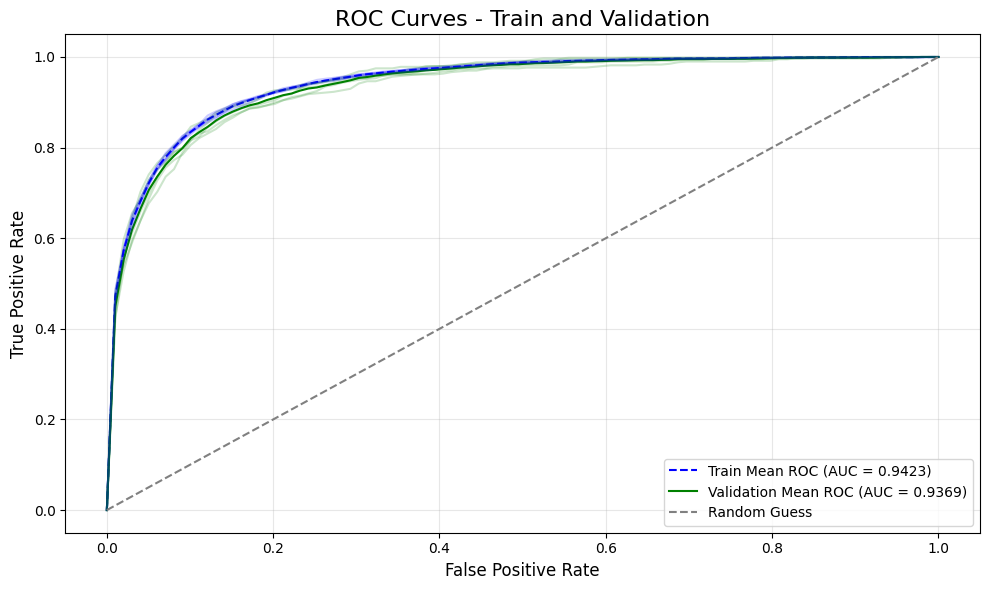

In [ ]:
# Version test_predictions_cb

# Créer des nouvelles caractéristiques à partir des données
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 30, 50, 100], labels=['Young', 'Middle-aged', 'Senior'])
df['HasNoBalance'] = (df['Balance'] == 0).astype(int)
df['BalanceToSalaryRatio'] = df['Balance'] / (df['EstimatedSalary'] + 1e-5)
df['AverageTenurePerProduct'] = df['Tenure'] / (df['NumOfProducts'] + 1e-5)

test['AgeGroup'] = pd.cut(test['Age'], bins=[0, 30, 50, 100], labels=['Young', 'Middle-aged', 'Senior'])
test['HasNoBalance'] = (test['Balance'] == 0).astype(int)
test['BalanceToSalaryRatio'] = test['Balance'] / (test['EstimatedSalary'] + 1e-5)
test['AverageTenurePerProduct'] = test['Tenure'] / (test['NumOfProducts'] + 1e-5)

# Mettre à jour la liste des caractéristiques
X = df[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
        'Geography', 'Gender', 'Surname', 'BalanceToSalaryRatio', 'AgeGroup', 'AverageTenurePerProduct', 'HasNoBalance']]
y = df['Exited']
X_test = test[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
               'Geography', 'Gender', 'Surname', 'BalanceToSalaryRatio', 'AgeGroup','AverageTenurePerProduct', 'HasNoBalance']]
test_ids = test['id']

################################################################################

# 1. Définir les caractéristiques
categorical_features_cat = ['Geography', 'Gender', 'AgeGroup', 'HasNoBalance', 'Surname']
numerical_features_cat = [
    'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
    'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
    'BalanceToSalaryRatio', 'AverageTenurePerProduct'
]

# 2. Préparer le préprocesseur pour CatBoost
preprocessor_cat = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features_cat),
        ('cat', 'passthrough', categorical_features_cat)
    ]
)

# 3. Configurer le modèle CatBoostClassifier
scale_pos_weight = y.value_counts()[0] / y.value_counts()[1]
cat_classifier = cb.CatBoostClassifier(
    iterations=200,
    depth=3,
    learning_rate=0.05,
    subsample=1.0,
    colsample_bylevel=0.8,
    min_data_in_leaf=1,
    scale_pos_weight=scale_pos_weight,
    random_seed=42,
    eval_metric='AUC',
    verbose=0
)

# 4. Créer StratifiedKFold
n_splits = 5
stratified_kfold = StratifiedKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=42
)

# 5. Initialiser les prédictions OOF et le jeu de test
oof_cat = np.zeros(len(X))
test_pred_cat = np.zeros(len(X_test))

# Initialiser les listes pour stocker les résultats ROC AUC pour chaque fold
cat_auc_train_folds = []  # Liste des ROC AUC pour l'ensemble d'entraînement
cat_auc_val_folds = []  # Liste des ROC AUC pour l'ensemble de validation

# 6. Boucler sur les folds pour l'entraînement et l'évaluation
for fold, (train_index, valid_index) in enumerate(stratified_kfold.split(X, y), start=1):
    print(f"Fold {fold}")

    # Diviser les données en ensembles d'entraînement et de validation
    X_train, X_valid = X.iloc[train_index], X.iloc[valid_index]
    y_train, y_valid = y.iloc[train_index], y.iloc[valid_index]

    # Prétraiter les données pour CatBoost
    preprocessor_cat.fit(X_train)
    X_train_cat = preprocessor_cat.transform(X_train)
    X_valid_cat = preprocessor_cat.transform(X_valid)
    X_test_cat = preprocessor_cat.transform(X_test)

    # Obtenir la liste des colonnes après le prétraitement
    feature_names_cat = numerical_features_cat + categorical_features_cat
    # Créer un mapping entre les noms des colonnes et leurs indices
    feature_indices_cat = {name: idx for idx, name in enumerate(feature_names_cat)}
    # Obtenir les indices des colonnes catégoriques
    cat_features_indices = [feature_indices_cat[col] for col in categorical_features_cat]

    # Entraîner le modèle CatBoost
    cat_classifier.fit(
        X_train_cat, y_train,
        cat_features=cat_features_indices
    )

    # Prédire sur les ensembles d'entraînement, de validation et de test
    train_pred_cat = cat_classifier.predict_proba(X_train_cat)[:, 1]  # Prédictions sur l'ensemble d'entraînement
    val_pred_cat = cat_classifier.predict_proba(X_valid_cat)[:, 1]  # Prédictions sur l'ensemble de validation
    oof_cat[valid_index] = val_pred_cat  # Stocker les prédictions OOF pour l'ensemble de validation
    test_pred_cat += cat_classifier.predict_proba(X_test_cat)[:, 1] / n_splits  # Moyenne des prédictions sur le test

    # Évaluer le ROC AUC sur l'ensemble d'entraînement et de validation
    train_auc = roc_auc_score(y_train, train_pred_cat)
    val_auc = roc_auc_score(y_valid, val_pred_cat)

    # Ajouter les résultats dans les listes des folds
    cat_auc_train_folds.append(train_auc)
    cat_auc_val_folds.append(val_auc)

    print(f"Fold {fold} - CatBoost Train ROC AUC: {train_auc:.4f}, Validation ROC AUC: {val_auc:.4f}")

# 7. Calculer le score ROC AUC moyen sur tous les folds
mean_train_auc_cat = np.mean(cat_auc_train_folds)
mean_val_auc_cat = np.mean(cat_auc_val_folds)

print("=" * 50)
print(f"Mean CatBoost Train ROC AUC: {mean_train_auc_cat:.4f}")
print(f"Mean CatBoost Validation ROC AUC: {mean_val_auc_cat:.4f}")
print("=" * 50)

# 8. Prédire sur l'ensemble de test final
result_df = pd.DataFrame({
    'id': test_ids,
    'Exited': test_pred_cat
})
result_df.to_csv('test_predictions_cb.csv', index=False)
print("Les prédictions ont été enregistrées dans 'test_predictions_cb.csv'.")

# Si nécessaire, télécharger le fichier CSV
# files.download('test_predictions_cb.csv')

################################################################################

# Initialiser les listes pour stocker les fpr, tpr et auc pour chaque fold
tprs_train = []
tprs_val = []
mean_fpr = np.linspace(0, 1, 100)

# 6. Boucler sur les folds pour l'entraînement et l'évaluation
for fold, (train_index, valid_index) in enumerate(stratified_kfold.split(X, y), start=1):
    # print(f"Fold {fold}")

    # Diviser les données en ensembles d'entraînement et de validation
    X_train, X_valid = X.iloc[train_index], X.iloc[valid_index]
    y_train, y_valid = y.iloc[train_index], y.iloc[valid_index]

    # Prétraiter les données pour CatBoost
    preprocessor_cat.fit(X_train)
    X_train_cat = preprocessor_cat.transform(X_train)
    X_valid_cat = preprocessor_cat.transform(X_valid)
    X_test_cat = preprocessor_cat.transform(X_test)

    # Obtenir la liste des colonnes après le prétraitement
    feature_names_cat = numerical_features_cat + categorical_features_cat
    # Créer un mapping entre les noms des colonnes et leurs indices
    feature_indices_cat = {name: idx for idx, name in enumerate(feature_names_cat)}
    # Obtenir les indices des colonnes catégoriques
    cat_features_indices = [feature_indices_cat[col] for col in categorical_features_cat]

    # Entraîner le modèle CatBoost
    cat_classifier.fit(
        X_train_cat, y_train,
        cat_features=cat_features_indices
    )

    # Prédire sur les ensembles d'entraînement et de validation
    train_pred_cat = cat_classifier.predict_proba(X_train_cat)[:, 1]
    val_pred_cat = cat_classifier.predict_proba(X_valid_cat)[:, 1]

    # Calculer les courbes ROC pour train et validation
    fpr_train, tpr_train, _ = roc_curve(y_train, train_pred_cat)
    fpr_val, tpr_val, _ = roc_curve(y_valid, val_pred_cat)

    # Interpoler les courbes pour le calcul de la moyenne
    tprs_train.append(np.interp(mean_fpr, fpr_train, tpr_train))
    tprs_val.append(np.interp(mean_fpr, fpr_val, tpr_val))
    tprs_train[-1][0] = 0.0
    tprs_val[-1][0] = 0.0

    # Calculer l'AUC
    train_auc = auc(fpr_train, tpr_train)
    val_auc = auc(fpr_val, tpr_val)

    # print(f"Fold {fold} - CatBoost Train ROC AUC: {train_auc:.4f}, Validation ROC AUC: {val_auc:.4f}")

# Calculer la moyenne et les intervalles de confiance pour les courbes ROC
mean_tpr_train = np.mean(tprs_train, axis=0)
mean_tpr_val = np.mean(tprs_val, axis=0)
mean_tpr_train[-1] = 1.0
mean_tpr_val[-1] = 1.0

mean_auc_train = auc(mean_fpr, mean_tpr_train)
mean_auc_val = auc(mean_fpr, mean_tpr_val)

# Tracer les courbes ROC
plt.figure(figsize=(10, 6))
plt.plot(mean_fpr, mean_tpr_train, color="blue", label=f"Train Mean ROC (AUC = {mean_auc_train:.4f})", linestyle="--")
plt.plot(mean_fpr, mean_tpr_val, color="green", label=f"Validation Mean ROC (AUC = {mean_auc_val:.4f})")

# Ajouter les courbes pour chaque fold
for i in range(len(tprs_train)):
    plt.plot(mean_fpr, tprs_train[i], color="blue", alpha=0.2)
    plt.plot(mean_fpr, tprs_val[i], color="green", alpha=0.2)

# Ajouter une ligne diagonale
plt.plot([0, 1], [0, 1], color="grey", linestyle="--", label="Random Guess")

# Configurer le graphique
plt.title("ROC Curves - Train and Validation", fontsize=16)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)

# Afficher le graphique
plt.tight_layout()
plt.show()